In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

In [118]:
# -- read in data
big_ten_preds = pd.read_csv('big_ten_all_predictions_master.csv')
display(big_ten_preds)

big_ten_preds.columns

,home_wrestler,away_wrestler,logreg_pred,logreg_winner,logreg_prob,dt_pred,dt_winner,dt_prob,xgb1_pred,xgb1_winner,xgb1_prob,xgb2_pred,xgb2_winner,xgb2_prob,weight_class,all_agree,avg_confidence
0,Luke Lilledahl,Spencer Moore,1,Luke Lilledahl,0.7071,1,Luke Lilledahl,0.7460,1,Luke Lilledahl,0.8013,1,Luke Lilledahl,0.8103,125,True,0.766175
1,Luke Lilledahl,Nic Bouzakis,1,Luke Lilledahl,0.5519,1,Luke Lilledahl,0.6111,1,Luke Lilledahl,0.6167,1,Luke Lilledahl,0.5320,125,True,0.577925
2,Luke Lilledahl,Jacob Moran,1,Luke Lilledahl,0.6169,1,Luke Lilledahl,0.7460,1,Luke Lilledahl,0.6575,1,Luke Lilledahl,0.8860,125,True,0.726600
3,Luke Lilledahl,Jore Volk,1,Luke Lilledahl,0.6352,1,Luke Lilledahl,0.7460,1,Luke Lilledahl,0.7101,1,Luke Lilledahl,0.8372,125,True,0.732125
4,Luke Lilledahl,Ayden Smith,1,Luke Lilledahl,0.7265,1,Luke Lilledahl,0.8898,1,Luke Lilledahl,0.8369,1,Luke Lilledahl,0.9023,125,True,0.838875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905,Hayden Filipovich,Gabe Christenson,1,Hayden Filipovich,0.6600,1,Hayden Filipovich,0.7460,1,Hayden Filipovich,0.6482,1,Hayden Filipovich,0.7285,285,True,0.695675
906,Hayden Filipovich,Caleb Marzolino,1,Hayden Filipovich,0.7501,1,Hayden Filipovich,0.8898,1,Hayden Filipovich,0.7928,1,Hayden Filipovich,0.8639,285,True,0.824150
907,Gabe Christenson,Joey Schneck,0,Joey Schneck,0.5442,0,Joey Schneck,0.5310,0,Joey Schneck,0.5184,1,Gabe Christenson,0.8342,285,False,0.606950
908,Joey Schneck,Caleb Marzolino,1,Joey Schneck,0.6532,1,Joey Schneck,0.8898,1,Joey Schneck,0.8276,1,Joey Schneck,0.6103,285,True,0.745225


Index(['home_wrestler', 'away_wrestler', 'logreg_pred', 'logreg_winner',
       'logreg_prob', 'dt_pred', 'dt_winner', 'dt_prob', 'xgb1_pred',
       'xgb1_winner', 'xgb1_prob', 'xgb2_pred', 'xgb2_winner', 'xgb2_prob',
       'weight_class', 'all_agree', 'avg_confidence'],
      dtype='object')

# Predictions by weight

In [119]:
# Initialize results list
all_weight_results_big_ten = []

# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_weight_class(weight_class, actual_results, special_matches,
                         predictions_df, conference="Big Ten", save_plots=False):
    """
    Evaluate all models for a specific weight class.
    """

    print("\n" + "="*100)
    print(f"🏋️  EVALUATING {weight_class}lbs - {conference} CONFERENCE")
    print("="*100)

    # Filter predictions for this weight class
    weight_preds = predictions_df[predictions_df['weight_class'] == weight_class].copy()

    if len(weight_preds) == 0:
        print(f"⚠️ No predictions found for {weight_class}lbs")
        return None, None

    print(f"\n📊 {weight_class}lbs predictions in dataset: {len(weight_preds)} matchups")

    # Create lookup dictionary
    pred_lookup = {}
    for _, row in weight_preds.iterrows():
        w1, w2 = row['home_wrestler'], row['away_wrestler']
        key = tuple(sorted([w1, w2]))
        pred_lookup[key] = row

    # Evaluate predictions
    results = []

    # Track matches for summary
    match_counter = {}

    for (w1, w2, match_round), actual_winner in actual_results.items():
        key = tuple(sorted([w1, w2]))

        # Track this matchup for debugging
        matchup_key = f"{w1} vs {w2}"
        if matchup_key not in match_counter:
            match_counter[matchup_key] = 0
        match_counter[matchup_key] += 1
        match_number = match_counter[matchup_key]

        if key not in pred_lookup:
            print(f"⚠️ Warning: No prediction found for {w1} vs {w2} (Match {match_number}: {match_round})")
            continue

        row = pred_lookup[key]
        is_special = (w1, w2, match_round) in special_matches or (w2, w1, match_round) in special_matches
        result_type = 'SPECIAL' if is_special else 'REGULAR'

        results.append({
            'Round': match_round,
            'Wrestler 1': w1,
            'Wrestler 2': w2,
            'Match Number': f"{match_number} of {match_counter[matchup_key]}",
            'Actual Winner': actual_winner,
            'Result Type': result_type,

            # Logistic Regression
            'LR Predicted': row['logreg_winner'],
            'LR Correct': row['logreg_winner'] == actual_winner,
            'LR Conf': row['logreg_prob'],

            # Decision Tree
            'DT Predicted': row['dt_winner'],
            'DT Correct': row['dt_winner'] == actual_winner,
            'DT Conf': row['dt_prob'],

            # XGBoost (no ranks)
            'XGB1 Predicted': row['xgb1_winner'],
            'XGB1 Correct': row['xgb1_winner'] == actual_winner,
            'XGB1 Conf': row['xgb1_prob'],

            # XGBoost (with ranks)
            'XGB2 Predicted': row['xgb2_winner'],
            'XGB2 Correct': row['xgb2_winner'] == actual_winner,
            'XGB2 Conf': row['xgb2_prob'],
        })

    eval_df = pd.DataFrame(results)

    if len(eval_df) == 0:
        print(f"⚠️ No matches evaluated for {weight_class}lbs")
        return None, None

    # Display multiple match warning if applicable
    multiple_matches = [k for k, v in match_counter.items() if v > 1]
    if multiple_matches:
        print("\n" + "="*100)
        print("⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS")
        print("="*100)
        for matchup in multiple_matches:
            print(f"   {matchup}: {match_counter[matchup]} matches")
            # Show which rounds
            matchup_rounds = [(r, win) for (w1, w2, r), win in actual_results.items()
                            if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup]
            for r, winner in matchup_rounds:
                print(f"      - {r}: {winner} wins")

    # Display detailed evaluation
    print("\n" + "="*100)
    print(f"📊 DETAILED EVALUATION - {weight_class}lbs ALL MATCHES")
    print("="*100)

    # Format for display
    display_df = eval_df.copy()
    for col in ['LR Conf', 'DT Conf', 'XGB1 Conf', 'XGB2 Conf']:
        display_df[col] = (display_df[col] * 100).round(1).astype(str) + '%'

    # Add emoji columns for display
    display_df['LR Correct'] = display_df['LR Correct'].map({True: '✅', False: '❌'})
    display_df['DT Correct'] = display_df['DT Correct'].map({True: '✅', False: '❌'})
    display_df['XGB1 Correct'] = display_df['XGB1 Correct'].map({True: '✅', False: '❌'})
    display_df['XGB2 Correct'] = display_df['XGB2 Correct'].map({True: '✅', False: '❌'})

    # Show relevant columns
    show_cols = ['Round', 'Wrestler 1', 'Wrestler 2', 'Match Number', 'Actual Winner',
                 'LR Correct', 'LR Conf', 'DT Correct', 'DT Conf',
                 'XGB1 Correct', 'XGB1 Conf', 'XGB2 Correct', 'XGB2 Conf']
    display(display_df[show_cols])

    # Calculate metrics
    def calculate_metrics(df, include_special=True):
        if not include_special:
            df = df[df['Result Type'] == 'REGULAR'].copy()

        if len(df) == 0:
            return {}

        metrics = {}
        models = [
            ('LR Correct', 'Logistic Regression'),
            ('DT Correct', 'Decision Tree'),
            ('XGB1 Correct', 'XGBoost (no ranks)'),
            ('XGB2 Correct', 'XGBoost (with ranks)')
        ]

        for col, name in models:
            correct_count = df[col].sum()
            total = len(df)
            accuracy = (correct_count / total * 100) if total > 0 else 0
            metrics[name] = {
                'correct': int(correct_count),
                'total': total,
                'accuracy': accuracy
            }

        return metrics

    all_metrics = calculate_metrics(eval_df, include_special=True)
    regular_metrics = calculate_metrics(eval_df, include_special=False)

    # Display metrics
    print("\n" + "="*100)
    print(f"📊 MODEL ACCURACY METRICS - {weight_class}lbs")
    print("="*100)

    print("\n🔴 INCLUDING ALL MATCHES (Special Results Included):")
    if all_metrics:
        metrics_df_all = pd.DataFrame([
            {'Model': model, 'Correct': f"{metrics['correct']}/{metrics['total']}",
             'Accuracy': f"{metrics['accuracy']:.1f}%"}
            for model, metrics in all_metrics.items()
        ])
        display(metrics_df_all)
    else:
        print("   No matches to evaluate")

    print("\n🟢 REGULAR MATCHES ONLY (Excluding Special Results):")
    if regular_metrics:
        metrics_df_regular = pd.DataFrame([
            {'Model': model, 'Correct': f"{metrics['correct']}/{metrics['total']}",
             'Accuracy': f"{metrics['accuracy']:.1f}%"}
            for model, metrics in regular_metrics.items()
        ])
        display(metrics_df_regular)
    else:
        print("   No regular matches to evaluate")

    # ============================================
    # BAR PLOTS
    # ============================================
    if len(eval_df) > 0:
        fig, axes = plt.subplots(2, 4, figsize=(20, 10))

        all_df = eval_df.copy()
        regular_df = eval_df[eval_df['Result Type'] == 'REGULAR'].copy()

        models = [
            ('LR Correct', 'Logistic Regression'),
            ('DT Correct', 'Decision Tree'),
            ('XGB1 Correct', 'XGBoost (no ranks)'),
            ('XGB2 Correct', 'XGBoost (with ranks)')
        ]

        model_colors = {'Correct': '#2ecc71', 'Incorrect': '#e74c3c'}

        # Top row: ALL matches
        for idx, (col, name) in enumerate(models):
            correct_counts = all_df[col].sum()
            incorrect_counts = len(all_df) - correct_counts

            bars = axes[0, idx].bar(['Correct', 'Incorrect'],
                                    [correct_counts, incorrect_counts],
                                    color=[model_colors['Correct'], model_colors['Incorrect']],
                                    edgecolor='black', linewidth=1)

            # Add count labels on bars
            for bar, count in zip(bars, [correct_counts, incorrect_counts]):
                height = bar.get_height()
                axes[0, idx].text(bar.get_x() + bar.get_width()/2., height,
                                 f'{int(count)}', ha='center', va='bottom', fontweight='bold')

            accuracy = correct_counts / len(all_df) * 100
            axes[0, idx].set_title(f'{name}\nAccuracy: {accuracy:.1f}%', fontweight='bold')
            axes[0, idx].set_ylabel('Number of Matches')
            axes[0, idx].set_ylim(0, len(all_df) + 1)
            axes[0, idx].grid(axis='y', alpha=0.3)

        # Bottom row: REGULAR matches only
        if len(regular_df) > 0:
            for idx, (col, name) in enumerate(models):
                correct_counts = regular_df[col].sum()
                incorrect_counts = len(regular_df) - correct_counts

                bars = axes[1, idx].bar(['Correct', 'Incorrect'],
                                        [correct_counts, incorrect_counts],
                                        color=[model_colors['Correct'], model_colors['Incorrect']],
                                        edgecolor='black', linewidth=1)

                # Add count labels on bars
                for bar, count in zip(bars, [correct_counts, incorrect_counts]):
                    height = bar.get_height()
                    axes[1, idx].text(bar.get_x() + bar.get_width()/2., height,
                                     f'{int(count)}', ha='center', va='bottom', fontweight='bold')

                accuracy = correct_counts / len(regular_df) * 100
                axes[1, idx].set_title(f'{name}\nAccuracy: {accuracy:.1f}%', fontweight='bold')
                axes[1, idx].set_ylabel('Number of Matches')
                axes[1, idx].set_ylim(0, len(regular_df) + 1)
                axes[1, idx].grid(axis='y', alpha=0.3)
        else:
            for idx in range(4):
                axes[1, idx].text(0.5, 0.5, 'No Regular Matches', ha='center', va='center',
                                 fontsize=14, transform=axes[1, idx].transAxes)
                axes[1, idx].set_title('No Data')
                axes[1, idx].set_xticks([])
                axes[1, idx].set_yticks([])

        # Add row labels
        axes[0, 0].annotate('ALL MATCHES\n(Special Results Included)', xy=(-0.3, 0.5), xycoords='axes fraction',
                            fontsize=12, fontweight='bold', rotation=90, va='center')
        axes[1, 0].annotate('REGULAR MATCHES ONLY\n(Excluding Special)', xy=(-0.3, 0.5), xycoords='axes fraction',
                            fontsize=12, fontweight='bold', rotation=90, va='center')

        # Add note about multiple matches if applicable
        if multiple_matches:
            fig.text(0.5, 0.02, f'⚠️ Note: {len(multiple_matches)} matchup(s) had multiple meetings',
                    ha='center', fontsize=10, style='italic', color='red')

        plt.suptitle(f'{weight_class}lbs - {conference} Conference Model Performance', fontsize=16, y=1.02)
        plt.tight_layout()

        if save_plots:
            plt.savefig(f'{conference}_{weight_class}lbs_performance_bars.png', dpi=300, bbox_inches='tight')
        plt.show()

    # Model Rankings
    print("\n" + "="*100)
    print(f"📊 MODEL RANKING - {weight_class}lbs")
    print("="*100)

    if all_metrics:
        ranking_df_all = pd.DataFrame([
            {'Model': model, 'Accuracy': f"{metrics['accuracy']:.1f}%",
             'Correct': f"{metrics['correct']}/{metrics['total']}"}
            for model, metrics in sorted(all_metrics.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        ])

        print("\n🏆 Model Ranking (All Matches - Special Results Included):")
        display(ranking_df_all)
    else:
        ranking_df_all = pd.DataFrame()
        print("\n🏆 No matches to rank")

    if regular_metrics:
        ranking_df_regular = pd.DataFrame([
            {'Model': model, 'Accuracy': f"{metrics['accuracy']:.1f}%",
             'Correct': f"{metrics['correct']}/{metrics['total']}"}
            for model, metrics in sorted(regular_metrics.items(), key=lambda x: x[1]['accuracy'], reverse=True)
        ])

        print("\n🏆 Model Ranking (Regular Matches Only - Excluding Special Results):")
        display(ranking_df_regular)
    else:
        ranking_df_regular = pd.DataFrame()
        print("\n🏆 No regular matches to rank")

    # Summary Statistics
    print("\n" + "="*100)
    print(f"📊 SUMMARY STATISTICS - {weight_class}lbs")
    print("="*100)

    total_matches = len(eval_df)
    special_matches_count = (eval_df['Result Type'] == 'SPECIAL').sum()
    regular_matches_count = total_matches - special_matches_count
    unique_matchups = len(eval_df[['Wrestler 1', 'Wrestler 2']].drop_duplicates())

    summary_stats = pd.DataFrame([
        {'Metric': 'Conference', 'Value': conference},
        {'Metric': 'Weight Class', 'Value': f'{weight_class}lbs'},
        {'Metric': 'Total Matches Evaluated', 'Value': total_matches},
        {'Metric': 'Unique Matchups', 'Value': unique_matchups},
        {'Metric': 'Matchups with Multiple Meetings', 'Value': len(multiple_matches)},
        {'Metric': 'Matches with Special Results', 'Value': f"{special_matches_count} ({special_matches_count/total_matches*100:.1f}%)"},
        {'Metric': 'Regular Matches', 'Value': f"{regular_matches_count} ({regular_matches_count/total_matches*100:.1f}%)"},
    ])

    if not ranking_df_all.empty:
        summary_stats.loc[len(summary_stats)] = ['Best Model (All Matches)', ranking_df_all.iloc[0]['Model']]
        summary_stats.loc[len(summary_stats)] = ['Best Model Accuracy (All Matches)', ranking_df_all.iloc[0]['Accuracy']]

    if not ranking_df_regular.empty:
        summary_stats.loc[len(summary_stats)] = ['Best Model (Regular Only)', ranking_df_regular.iloc[0]['Model']]
        summary_stats.loc[len(summary_stats)] = ['Best Model Accuracy (Regular Only)', ranking_df_regular.iloc[0]['Accuracy']]

    display(summary_stats)

    # Complete Performance Summary
    print("\n" + "="*100)
    print(f"📊 COMPLETE MODEL PERFORMANCE SUMMARY - {weight_class}lbs")
    print("="*100)

    summary_complete = []
    for model in ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']:
        row = {
            'Model': model,
            'All Matches Accuracy': f"{all_metrics[model]['accuracy']:.1f}%" if model in all_metrics else 'N/A',
            'All Matches Correct': f"{all_metrics[model]['correct']}/{all_metrics[model]['total']}" if model in all_metrics else 'N/A',
        }

        if regular_metrics and model in regular_metrics:
            row['Regular Only Accuracy'] = f"{regular_metrics[model]['accuracy']:.1f}%"
            row['Regular Only Correct'] = f"{regular_metrics[model]['correct']}/{regular_metrics[model]['total']}"
        else:
            row['Regular Only Accuracy'] = 'N/A'
            row['Regular Only Correct'] = 'N/A'

        summary_complete.append(row)

    summary_complete_df = pd.DataFrame(summary_complete)
    display(summary_complete_df)

    # Create summary dictionary for later aggregation
    summary_dict = {
        'weight_class': weight_class,
        'total_matches': total_matches,
        'unique_matchups': unique_matchups,
        'multiple_meeting_matchups': len(multiple_matches),
        'special_matches': special_matches_count,
        'regular_matches': regular_matches_count,
        'all_metrics': all_metrics,
        'regular_metrics': regular_metrics,
        'ranking_all': ranking_df_all.iloc[0]['Model'] if not ranking_df_all.empty else None,
        'ranking_regular': ranking_df_regular.iloc[0]['Model'] if not ranking_df_regular.empty else None,
    }

    return eval_df, summary_dict


# ============================================
# HELPER FUNCTIONS FOR SETUP
# ============================================


# ============================================
# FIXED SETUP FUNCTION - PROPERLY HANDLES SPECIAL MATCHES
# ============================================

def setup_weight_class_results(weight_class, matches_dict, conference="Big Ten"):
    """
    Create the actual_results and special_matches dictionaries for a weight class.
    Properly identifies special matches from winner strings.
    """

    print("\n" + "="*100)
    print(f"📋 SETTING UP {weight_class}lbs {conference} TOURNAMENT RESULTS")
    print("="*100)

    # Separate regular and special matches
    actual_results = {}
    special_matches = []

    for (w1, w2, round_name), winner in matches_dict.items():
        # Check if this is a special match by looking for indicators in the winner string
        if isinstance(winner, str):
            if ' (INJURY)' in winner:
                actual_winner = winner.replace(' (INJURY)', '')
                actual_results[(w1, w2, round_name)] = actual_winner
                special_matches.append((w1, w2, round_name))
            elif ' (MFFL)' in winner:
                actual_winner = winner.replace(' (MFFL)', '')
                actual_results[(w1, w2, round_name)] = actual_winner
                special_matches.append((w1, w2, round_name))
            elif ' (DQ)' in winner:
                actual_winner = winner.replace(' (DQ)', '')
                actual_results[(w1, w2, round_name)] = actual_winner
                special_matches.append((w1, w2, round_name))
            else:
                actual_results[(w1, w2, round_name)] = winner
        else:
            actual_results[(w1, w2, round_name)] = winner

    print(f"\n📊 {weight_class}lbs Results Summary:")
    print(f"   Total matches: {len(actual_results)}")
    print(f"   Special matches: {len(special_matches)}")

    # Display actual matches with proper type classification
    actual_matches_df = []
    for (w1, w2, round_name), winner in actual_results.items():
        is_special = (w1, w2, round_name) in special_matches or (w2, w1, round_name) in special_matches
        # For display, show the original winner string with special indicator
        display_winner = winner
        for (sw1, sw2, sround) in special_matches:
            if (sw1, sw2, sround) == (w1, w2, round_name) or (sw2, sw1, sround) == (w1, w2, round_name):
                # Find the original winner string from matches_dict
                for (mw1, mw2, mround), mwinner in matches_dict.items():
                    if (mw1, mw2, mround) == (w1, w2, round_name) or (mw2, mw1, mround) == (w1, w2, round_name):
                        display_winner = mwinner
                        break
                break

        actual_matches_df.append({
            'Round': round_name,
            'Wrestler 1': w1,
            'Wrestler 2': w2,
            'Winner': display_winner,
            'Type': 'SPECIAL' if is_special else 'REGULAR'
        })

    # Sort by round order
    round_order = [
        'Champ. Round 1', 'Quarterfinal', 'Cons. Round 1', 'Cons. Round 2',
        'Cons. Round 3', 'Semifinal', 'Cons. Semi', '3rd Place',
        '5th Place', '7th Place', 'Championship'
    ]

    actual_matches_df = pd.DataFrame(actual_matches_df)

    # Create round order mapping (only for rounds that exist)
    round_order_map = {}
    for i, r in enumerate(round_order):
        if r in actual_matches_df['Round'].values:
            round_order_map[r] = i

    if round_order_map:
        actual_matches_df['Round Order'] = actual_matches_df['Round'].map(round_order_map)
        actual_matches_df = actual_matches_df.sort_values('Round Order').drop('Round Order', axis=1)

    display(actual_matches_df)

    # Check for multiple meetings
    from collections import Counter
    matchup_counter = Counter()
    for (w1, w2, _) in actual_results.keys():
        matchup = tuple(sorted([w1, w2]))
        matchup_counter[matchup] += 1

    multiple_meetings = [f"{w1} vs {w2}" for (w1, w2), count in matchup_counter.items() if count > 1]
    if multiple_meetings:
        print("\n⚠️ Multiple meetings detected:")
        for matchup in multiple_meetings:
            count = matchup_counter[tuple(sorted(matchup.split(' vs ')))]
            print(f"   {matchup}: {count} matches")

            # Show which rounds for multiple meetings
            print(f"      Rounds:")
            for (w1, w2, round_name), winner in actual_results.items():
                if f"{w1} vs {w2}" == matchup or f"{w2} vs {w1}" == matchup:
                    is_special = (w1, w2, round_name) in special_matches or (w2, w1, round_name) in special_matches
                    # Find original winner for display
                    display_winner = winner
                    if is_special:
                        for (mw1, mw2, mround), mwinner in matches_dict.items():
                            if (mw1, mw2, mround) == (w1, w2, round_name) or (mw2, mw1, mround) == (w1, w2, round_name):
                                display_winner = mwinner
                                break
                    special_marker = " (SPECIAL)" if is_special else ""
                    print(f"        - {round_name}: {display_winner}{special_marker}")
    else:
        print("\n✅ No multiple meetings detected")

    return actual_results, special_matches, actual_matches_df



def get_weight_predictions(predictions_df, weight_class, wrestlers_list):
    """
    Extract predictions for a specific weight class and filter to only include
    matches between wrestlers in the tournament.
    """

    weight_preds = predictions_df[predictions_df['weight_class'] == weight_class].copy()

    # Filter to only include matchups where both wrestlers are in the tournament
    mask = weight_preds['home_wrestler'].isin(wrestlers_list) & weight_preds['away_wrestler'].isin(wrestlers_list)
    filtered_df = weight_preds[mask].copy()

    total_possible = len(wrestlers_list) * (len(wrestlers_list) - 1) // 2
    print(f"\n📊 {weight_class}lbs: {len(filtered_df)}/{len(weight_preds)} matchups involve tournament wrestlers")
    print(f"   Total possible matchups: {total_possible}")

    return filtered_df


def evaluate_and_store_weight_class(weight_class, actual_results, special_matches,
                                    predictions_df, conference, results_list,
                                    eval_function, save_plots=False):
    """
    Evaluate a weight class and append results to the results list.
    """

    eval_df, summary_dict = eval_function(
        weight_class=weight_class,
        actual_results=actual_results,
        special_matches=special_matches,
        predictions_df=predictions_df,
        conference=conference,
        save_plots=save_plots
    )

    if summary_dict:
        results_list.append(summary_dict)

    return eval_df, summary_dict


📋 SETTING UP 125lbs Big Ten TOURNAMENT RESULTS

📊 125lbs Results Summary:
   Total matches: 26
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Dean Peterson,Diego Sotelo,Dean Peterson,REGULAR
1,Champ. Round 1,Nick Corday,Ayden Smith,Nick Corday,REGULAR
2,Champ. Round 1,Jacob Moran,Ashton Jackson,Jacob Moran,REGULAR
3,Champ. Round 1,Spencer Moore,Abram Cline,Spencer Moore,REGULAR
4,Champ. Round 1,Jore Volk,Kael Lauridsen,Jore Volk,REGULAR
5,Champ. Round 1,Nicolar Rivera,Dedrick Navarro,Nicolar Rivera,REGULAR
6,Quarterfinal,Luke Lilledahl,Dean Peterson,Luke Lilledahl,REGULAR
7,Quarterfinal,Jacob Moran,Nick Corday,Jacob Moran,REGULAR
8,Quarterfinal,Jore Volk,Spencer Moore,Jore Volk,REGULAR
9,Quarterfinal,Nic Bouzakis,Nicolar Rivera,Nic Bouzakis,REGULAR



⚠️ Multiple meetings detected:
   Dean Peterson vs Diego Sotelo: 2 matches
      Rounds:
        - Champ. Round 1: Dean Peterson
        - 5th Place: Dean Peterson

📊 125lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

✅ Found evaluate_weight_class function

🏋️  EVALUATING 125lbs - Big Ten CONFERENCE

📊 125lbs predictions in dataset: 91 matchups

⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS
   Dean Peterson vs Diego Sotelo: 2 matches
      - Champ. Round 1: Dean Peterson wins
      - 5th Place: Dean Peterson wins

📊 DETAILED EVALUATION - 125lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Dean Peterson,Diego Sotelo,1 of 1,Dean Peterson,✅,61.7%,✅,74.6%,✅,62.4%,✅,74.6%
1,Champ. Round 1,Nick Corday,Ayden Smith,1 of 1,Nick Corday,❌,55.4%,❌,61.1%,❌,65.4%,❌,86.1%
2,Champ. Round 1,Jacob Moran,Ashton Jackson,1 of 1,Jacob Moran,✅,77.5%,✅,89.0%,✅,90.8%,✅,93.4%
3,Champ. Round 1,Spencer Moore,Abram Cline,1 of 1,Spencer Moore,✅,75.0%,✅,89.0%,✅,88.8%,✅,97.5%
4,Champ. Round 1,Jore Volk,Kael Lauridsen,1 of 1,Jore Volk,✅,72.9%,✅,74.6%,✅,84.3%,✅,91.8%
5,Champ. Round 1,Nicolar Rivera,Dedrick Navarro,1 of 1,Nicolar Rivera,✅,59.1%,✅,61.1%,✅,78.4%,✅,87.0%
6,Quarterfinal,Luke Lilledahl,Dean Peterson,1 of 1,Luke Lilledahl,✅,65.3%,✅,74.6%,✅,78.1%,✅,67.1%
7,Quarterfinal,Jacob Moran,Nick Corday,1 of 1,Jacob Moran,✅,67.2%,✅,74.6%,✅,83.4%,✅,90.2%
8,Quarterfinal,Jore Volk,Spencer Moore,1 of 1,Jore Volk,✅,57.8%,✅,53.1%,✅,55.6%,❌,56.1%
9,Quarterfinal,Nic Bouzakis,Nicolar Rivera,1 of 1,Nic Bouzakis,✅,58.0%,✅,61.1%,✅,60.1%,✅,73.4%



📊 MODEL ACCURACY METRICS - 125lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,19/26,73.1%
1,Decision Tree,20/26,76.9%
2,XGBoost (no ranks),19/26,73.1%
3,XGBoost (with ranks),20/26,76.9%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,19/26,73.1%
1,Decision Tree,20/26,76.9%
2,XGBoost (no ranks),19/26,73.1%
3,XGBoost (with ranks),20/26,76.9%


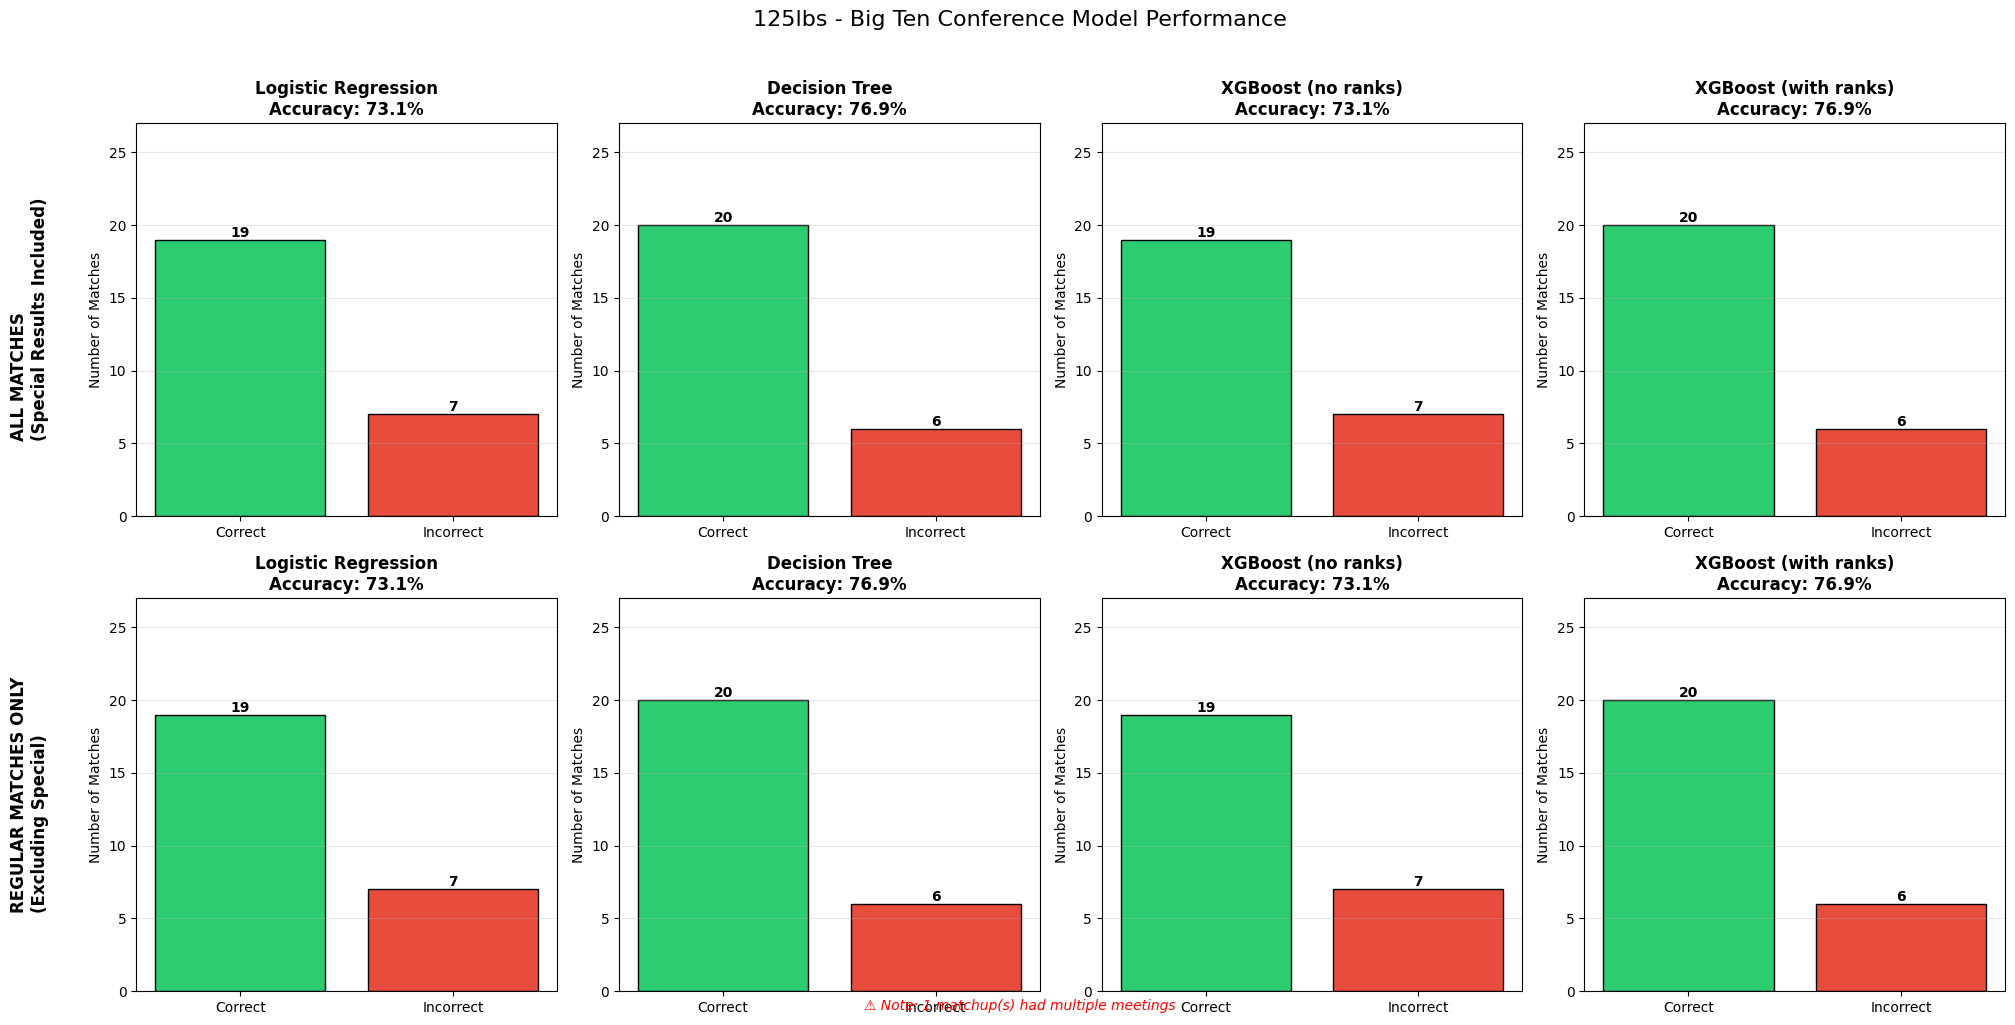


📊 MODEL RANKING - 125lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Decision Tree,76.9%,20/26
1,XGBoost (with ranks),76.9%,20/26
2,Logistic Regression,73.1%,19/26
3,XGBoost (no ranks),73.1%,19/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Decision Tree,76.9%,20/26
1,XGBoost (with ranks),76.9%,20/26
2,Logistic Regression,73.1%,19/26
3,XGBoost (no ranks),73.1%,19/26



📊 SUMMARY STATISTICS - 125lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,125lbs
2,Total Matches Evaluated,26
3,Unique Matchups,25
4,Matchups with Multiple Meetings,1
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,26 (100.0%)
7,Best Model (All Matches),Decision Tree
8,Best Model Accuracy (All Matches),76.9%
9,Best Model (Regular Only),Decision Tree



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 125lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,73.1%,19/26,73.1%,19/26
1,Decision Tree,76.9%,20/26,76.9%,20/26
2,XGBoost (no ranks),73.1%,19/26,73.1%,19/26
3,XGBoost (with ranks),76.9%,20/26,76.9%,20/26



✅ Completed 125lbs evaluation. Total results stored: 1


In [120]:
# ============================================
# 125lbs BIG TEN RESULTS (COMPLETE WITH ALL MATCHES)
# ============================================

# Define 125lbs wrestlers
wrestlers_125 = [
    'Luke Lilledahl', 'Jacob Moran', 'Jore Volk', 'Nic Bouzakis',
    'Dean Peterson', 'Diego Sotelo', 'Spencer Moore', 'Nicolar Rivera',
    'Ayden Smith', 'Kael Lauridsen', 'Nick Corday', 'Ashton Jackson',
    'Dedrick Navarro', 'Abram Cline'
]

# Create 125lbs matches dictionary (COMPLETE with all rounds)
matches_125 = {
    # Champ. Round 1
    ('Dean Peterson', 'Diego Sotelo', 'Champ. Round 1'): 'Dean Peterson',  # Dec 6-2
    ('Nick Corday', 'Ayden Smith', 'Champ. Round 1'): 'Nick Corday',  # SV-1 4-1
    ('Jacob Moran', 'Ashton Jackson', 'Champ. Round 1'): 'Jacob Moran',  # TF-1.5 17-2
    ('Spencer Moore', 'Abram Cline', 'Champ. Round 1'): 'Spencer Moore',  # MD 9-0
    ('Jore Volk', 'Kael Lauridsen', 'Champ. Round 1'): 'Jore Volk',  # TF-1.5 16-0
    ('Nicolar Rivera', 'Dedrick Navarro', 'Champ. Round 1'): 'Nicolar Rivera',  # Dec 8-1

    # Quarterfinals
    ('Luke Lilledahl', 'Dean Peterson', 'Quarterfinal'): 'Luke Lilledahl',  # Dec 8-3
    ('Jacob Moran', 'Nick Corday', 'Quarterfinal'): 'Jacob Moran',  # TF-1.5 20-3
    ('Jore Volk', 'Spencer Moore', 'Quarterfinal'): 'Jore Volk',  # SV-1 4-1
    ('Nic Bouzakis', 'Nicolar Rivera', 'Quarterfinal'): 'Nic Bouzakis',  # TF-1.5 17-2

    # Cons. Round 1
    ('Ayden Smith', 'Ashton Jackson', 'Cons. Round 1'): 'Ayden Smith',  # TB-1 4-2
    ('Kael Lauridsen', 'Abram Cline', 'Cons. Round 1'): 'Kael Lauridsen',  # Dec 1-0

    # Cons. Round 2
    ('Diego Sotelo', 'Nicolar Rivera', 'Cons. Round 2'): 'Diego Sotelo',  # MD 11-1
    ('Ayden Smith', 'Spencer Moore', 'Cons. Round 2'): 'Ayden Smith',  # Dec 3-2
    ('Kael Lauridsen', 'Nick Corday', 'Cons. Round 2'): 'Kael Lauridsen',  # Dec 3-2
    ('Dean Peterson', 'Dedrick Navarro', 'Cons. Round 2'): 'Dean Peterson',  # Dec 5-0

    # Cons. Round 3
    ('Diego Sotelo', 'Ayden Smith', 'Cons. Round 3'): 'Diego Sotelo',  # Dec 4-0
    ('Dean Peterson', 'Kael Lauridsen', 'Cons. Round 3'): 'Dean Peterson',  # Dec 4-3

    # Semifinals
    ('Luke Lilledahl', 'Jacob Moran', 'Semifinal'): 'Luke Lilledahl',  # MD 11-3
    ('Jore Volk', 'Nic Bouzakis', 'Semifinal'): 'Jore Volk',  # Dec 8-1

    # Consolation Semis
    ('Jacob Moran', 'Diego Sotelo', 'Cons. Semi'): 'Jacob Moran',  # Dec 9-7
    ('Nic Bouzakis', 'Dean Peterson', 'Cons. Semi'): 'Nic Bouzakis',  # Dec 6-4

    # 7th Place Match
    ('Kael Lauridsen', 'Ayden Smith', '7th Place'): 'Kael Lauridsen',  # Dec 6-3

    # 5th Place Match
    ('Dean Peterson', 'Diego Sotelo', '5th Place'): 'Dean Peterson',  # Dec 5-2

    # 3rd Place Match
    ('Nic Bouzakis', 'Jacob Moran', '3rd Place'): 'Nic Bouzakis',  # Dec 4-2

    # 1st Place Match (Championship)
    ('Luke Lilledahl', 'Jore Volk', 'Championship'): 'Luke Lilledahl',  # SV-1 4-1
}

# Setup 125lbs results
actual_results_125, special_matches_125, actual_matches_df_125 = setup_weight_class_results(
    weight_class=125,
    matches_dict=matches_125,
    conference="Big Ten"
)

# Get filtered predictions for 125lbs
weight_preds_125 = get_weight_predictions(big_ten_preds, 125, wrestlers_125)

# ============================================
# CHECK IF EVALUATION FUNCTION EXISTS
# ============================================

# Try to use the evaluation function if it exists
try:
    # Test if the function exists
    eval_function = evaluate_weight_class
    print("\n✅ Found evaluate_weight_class function")

    # Evaluate 125lbs and store results
    eval_125, summary_125 = evaluate_and_store_weight_class(
        weight_class=125,
        actual_results=actual_results_125,
        special_matches=special_matches_125,
        predictions_df=big_ten_preds,
        conference="Big Ten",
        results_list=all_weight_results_big_ten,
        eval_function=eval_function,
        save_plots=False
    )

    print(f"\n✅ Completed 125lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")

except NameError:
    print("\n⚠️ evaluate_weight_class function not defined.")
    print("Please define or import the evaluate_weight_class function before running this cell.")
    print("The match data has been set up successfully. Once the function is defined, run the evaluation part again.")


📋 SETTING UP 133lbs Big Ten TOURNAMENT RESULTS

📊 133lbs Results Summary:
   Total matches: 26
   Special matches: 2


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Dylan Shawver,Braxton Brown,Dylan Shawver,REGULAR
1,Champ. Round 1,Drake Ayala,Blaine Frazier,Drake Ayala,REGULAR
2,Champ. Round 1,Zan Fugitt,Gauge Botero,Zan Fugitt,REGULAR
3,Champ. Round 1,Ben Davino,Jager Eisch,Ben Davino,REGULAR
4,Champ. Round 1,Jacob Van Dee,Caleb Weiand,Jacob Van Dee,REGULAR
5,Champ. Round 1,Blake Boarman,Sean Spidle,Blake Boarman,REGULAR
6,Quarterfinal,Marcus Blaze,Dylan Shawver,Marcus Blaze,REGULAR
7,Quarterfinal,Drake Ayala,Zan Fugitt,Drake Ayala,REGULAR
8,Quarterfinal,Ben Davino,Jacob Van Dee,Ben Davino,REGULAR
9,Quarterfinal,Blake Boarman,Lucas Byrd,Blake Boarman,REGULAR



⚠️ Multiple meetings detected:
   Drake Ayala vs Zan Fugitt: 2 matches
      Rounds:
        - Quarterfinal: Drake Ayala
        - 3rd Place: Drake Ayala
   Blake Boarman vs Lucas Byrd: 2 matches
      Rounds:
        - Quarterfinal: Blake Boarman
        - 5th Place: Lucas Byrd

📊 133lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🏋️  EVALUATING 133lbs - Big Ten CONFERENCE

📊 133lbs predictions in dataset: 91 matchups

⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS
   Drake Ayala vs Zan Fugitt: 2 matches
      - Quarterfinal: Drake Ayala wins
      - 3rd Place: Drake Ayala wins

📊 DETAILED EVALUATION - 133lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Dylan Shawver,Braxton Brown,1 of 1,Dylan Shawver,❌,51.3%,✅,74.7%,✅,57.5%,✅,91.3%
1,Champ. Round 1,Drake Ayala,Blaine Frazier,1 of 1,Drake Ayala,✅,66.6%,✅,74.6%,✅,85.1%,✅,93.1%
2,Champ. Round 1,Zan Fugitt,Gauge Botero,1 of 1,Zan Fugitt,✅,80.0%,✅,89.0%,✅,90.4%,✅,83.0%
3,Champ. Round 1,Ben Davino,Jager Eisch,1 of 1,Ben Davino,✅,88.8%,✅,89.0%,✅,88.4%,✅,91.8%
4,Champ. Round 1,Jacob Van Dee,Caleb Weiand,1 of 1,Jacob Van Dee,✅,72.3%,✅,74.6%,✅,87.0%,✅,95.6%
5,Champ. Round 1,Blake Boarman,Sean Spidle,1 of 1,Blake Boarman,❌,61.7%,❌,74.6%,❌,54.1%,✅,59.3%
6,Quarterfinal,Marcus Blaze,Dylan Shawver,1 of 1,Marcus Blaze,✅,68.5%,✅,74.6%,✅,77.9%,✅,81.0%
7,Quarterfinal,Drake Ayala,Zan Fugitt,1 of 1,Drake Ayala,❌,60.6%,❌,53.1%,❌,54.9%,✅,58.6%
8,Quarterfinal,Ben Davino,Jacob Van Dee,1 of 1,Ben Davino,✅,58.2%,✅,61.1%,✅,73.9%,✅,68.9%
9,Quarterfinal,Blake Boarman,Lucas Byrd,1 of 1,Blake Boarman,❌,75.0%,❌,74.6%,❌,85.0%,❌,90.9%



📊 MODEL ACCURACY METRICS - 133lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,17/26,65.4%
1,Decision Tree,17/26,65.4%
2,XGBoost (no ranks),17/26,65.4%
3,XGBoost (with ranks),20/26,76.9%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,16/24,66.7%
1,Decision Tree,16/24,66.7%
2,XGBoost (no ranks),16/24,66.7%
3,XGBoost (with ranks),19/24,79.2%


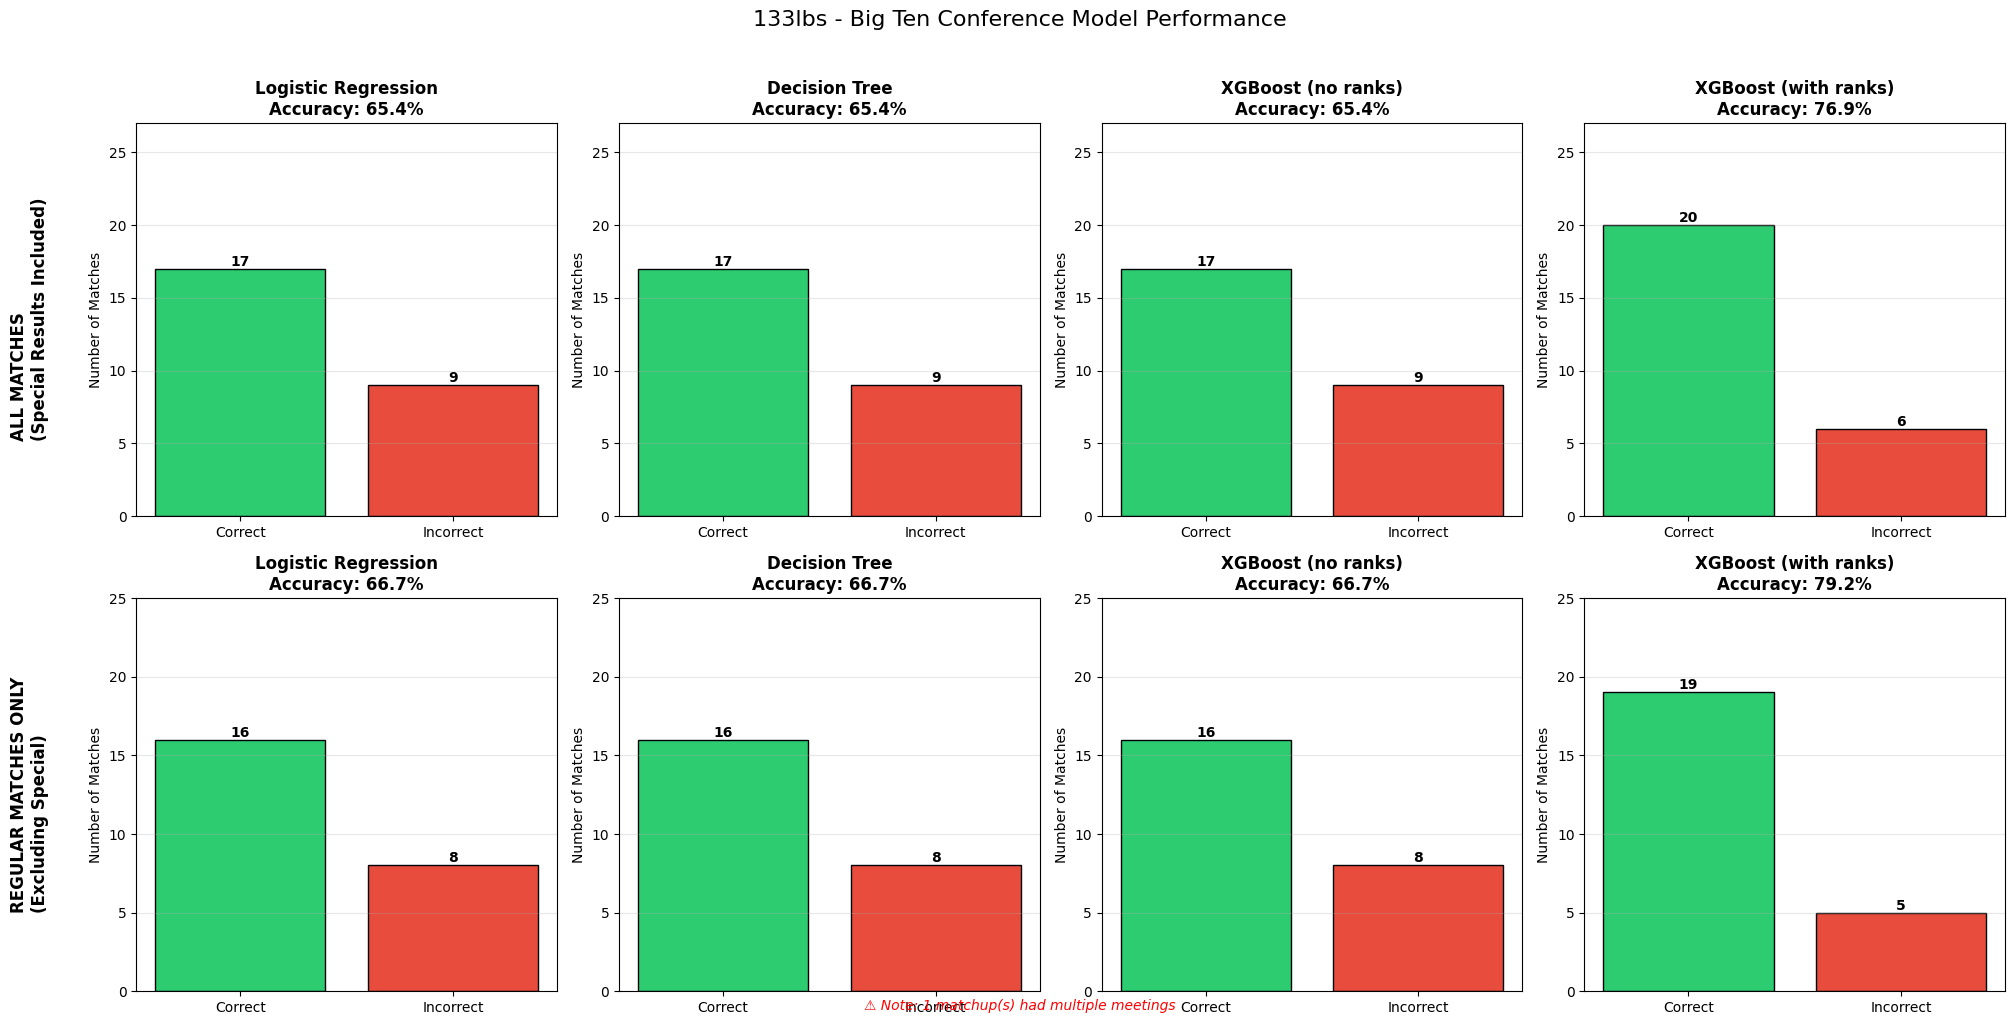


📊 MODEL RANKING - 133lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (with ranks),76.9%,20/26
1,Logistic Regression,65.4%,17/26
2,Decision Tree,65.4%,17/26
3,XGBoost (no ranks),65.4%,17/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (with ranks),79.2%,19/24
1,Logistic Regression,66.7%,16/24
2,Decision Tree,66.7%,16/24
3,XGBoost (no ranks),66.7%,16/24



📊 SUMMARY STATISTICS - 133lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,133lbs
2,Total Matches Evaluated,26
3,Unique Matchups,25
4,Matchups with Multiple Meetings,1
5,Matches with Special Results,2 (7.7%)
6,Regular Matches,24 (92.3%)
7,Best Model (All Matches),XGBoost (with ranks)
8,Best Model Accuracy (All Matches),76.9%
9,Best Model (Regular Only),XGBoost (with ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 133lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,65.4%,17/26,66.7%,16/24
1,Decision Tree,65.4%,17/26,66.7%,16/24
2,XGBoost (no ranks),65.4%,17/26,66.7%,16/24
3,XGBoost (with ranks),76.9%,20/26,79.2%,19/24



✅ Completed 133lbs evaluation. Total results stored: 2


In [121]:
# ============================================
# 133lbs BIG TEN RESULTS
# ============================================

# Define 133lbs wrestlers
wrestlers_133 = [
    'Marcus Blaze', 'Ben Davino', 'Drake Ayala', 'Blake Boarman',
    'Lucas Byrd', 'Zan Fugitt', 'Jacob Van Dee', 'Sean Spidle',
    'Dylan Shawver', 'Braxton Brown', 'Jager Eisch', 'Blaine Frazier',
    'Gauge Botero', 'Caleb Weiand'
]

# Create 133lbs matches dictionary
matches_133 = {
    # Champ. Round 1
    ('Dylan Shawver', 'Braxton Brown', 'Champ. Round 1'): 'Dylan Shawver',  # TB-3 (RT) 2-2
    ('Drake Ayala', 'Blaine Frazier', 'Champ. Round 1'): 'Drake Ayala',  # TF-1.5 21-6
    ('Zan Fugitt', 'Gauge Botero', 'Champ. Round 1'): 'Zan Fugitt',  # Dec 8-1
    ('Ben Davino', 'Jager Eisch', 'Champ. Round 1'): 'Ben Davino',  # TF-1.5 19-2
    ('Jacob Van Dee', 'Caleb Weiand', 'Champ. Round 1'): 'Jacob Van Dee',  # Dec 9-3
    ('Blake Boarman', 'Sean Spidle', 'Champ. Round 1'): 'Blake Boarman',  # Dec 3-2

    # Quarterfinals
    ('Marcus Blaze', 'Dylan Shawver', 'Quarterfinal'): 'Marcus Blaze',  # MD 16-3
    ('Drake Ayala', 'Zan Fugitt', 'Quarterfinal'): 'Drake Ayala',  # Dec 10-3
    ('Ben Davino', 'Jacob Van Dee', 'Quarterfinal'): 'Ben Davino',  # Dec 5-1
    ('Blake Boarman', 'Lucas Byrd', 'Quarterfinal'): 'Blake Boarman',  # Dec 7-3

    # Cons. Round 1
    ('Blaine Frazier', 'Gauge Botero', 'Cons. Round 1'): 'Blaine Frazier',  # Dec 10-4
    ('Jager Eisch', 'Caleb Weiand', 'Cons. Round 1'): 'Jager Eisch',  # TF-1.5 15-0

    # Cons. Round 2
    ('Lucas Byrd', 'Braxton Brown', 'Cons. Round 2'): 'Lucas Byrd',  # MD 8-0
    ('Jacob Van Dee', 'Blaine Frazier', 'Cons. Round 2'): 'Jacob Van Dee',  # TF-1.5 19-4
    ('Zan Fugitt', 'Jager Eisch', 'Cons. Round 2'): 'Zan Fugitt',  # SV-1 5-2
    ('Sean Spidle', 'Dylan Shawver', 'Cons. Round 2'): 'Sean Spidle',  # Dec 1-0

    # Cons. Round 3
    ('Lucas Byrd', 'Jacob Van Dee', 'Cons. Round 3'): 'Lucas Byrd (INJURY)',  # Injury default
    ('Zan Fugitt', 'Sean Spidle', 'Cons. Round 3'): 'Zan Fugitt',  # MD 14-2

    # Semifinals
    ('Marcus Blaze', 'Drake Ayala', 'Semifinal'): 'Marcus Blaze',  # SV-1 4-1
    ('Ben Davino', 'Blake Boarman', 'Semifinal'): 'Ben Davino',  # TF-1.5 21-5

    # Consolation Semis
    ('Drake Ayala', 'Lucas Byrd', 'Cons. Semi'): 'Drake Ayala',  # SV-1 4-1
    ('Zan Fugitt', 'Blake Boarman', 'Cons. Semi'): 'Zan Fugitt',  # MD 11-1

    # 7th Place Match
    ('Sean Spidle', 'Jacob Van Dee', '7th Place'): 'Sean Spidle (MFFL)',  # Medical forfeit

    # 5th Place Match
    ('Lucas Byrd', 'Blake Boarman', '5th Place'): 'Lucas Byrd',  # Dec 5-2

    # 3rd Place Match
    ('Drake Ayala', 'Zan Fugitt', '3rd Place'): 'Drake Ayala',  # Dec 4-2

    # Championship
    ('Ben Davino', 'Marcus Blaze', 'Championship'): 'Ben Davino',  # TB-2 (RT) 2-2
}

# Track special matches (injury, forfeit, DQ)
special_matches_133 = [
    ('Lucas Byrd', 'Jacob Van Dee', 'Cons. Round 3'),  # Injury default
    ('Sean Spidle', 'Jacob Van Dee', '7th Place'),      # Medical forfeit
]

# Setup 133lbs results
actual_results_133, special_matches_133, actual_matches_df_133 = setup_weight_class_results(
    weight_class=133,
    matches_dict=matches_133,
    conference="Big Ten"
)

# Get filtered predictions for 133lbs
weight_preds_133 = get_weight_predictions(big_ten_preds, 133, wrestlers_133)

# ============================================
# EVALUATE 133lbs
# ============================================

eval_133, summary_133 = evaluate_and_store_weight_class(
    weight_class=133,
    actual_results=actual_results_133,
    special_matches=special_matches_133,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 133lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")


📋 SETTING UP 141lbs Big Ten TOURNAMENT RESULTS

📊 141lbs Results Summary:
   Total matches: 26
   Special matches: 0


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Billy Dekraker,Henry Porter,Billy Dekraker,REGULAR
1,Champ. Round 1,Dylan Ragusin,Danny Pucino,Dylan Ragusin,REGULAR
2,Champ. Round 1,Nasir Bailey,Carson Exferd,Nasir Bailey,REGULAR
3,Champ. Round 1,Vance Vombaur,Jaden Crumpler,Vance Vombaur,REGULAR
4,Champ. Round 1,Braeden Davis,Dario Lemus,Braeden Davis,REGULAR
5,Champ. Round 1,Joey Olivieri,Greyson Clark,Joey Olivieri,REGULAR
6,Quarterfinal,Jesse Mendez,Billy Dekraker,Jesse Mendez,REGULAR
7,Quarterfinal,Nasir Bailey,Dylan Ragusin,Nasir Bailey,REGULAR
8,Quarterfinal,Vance Vombaur,Braeden Davis,Vance Vombaur,REGULAR
9,Quarterfinal,Brock Hardy,Joey Olivieri,Brock Hardy,REGULAR



✅ No multiple meetings detected

📊 141lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🔍 Verifying all matches have predictions...
✅ All matches found in predictions!

🏋️  EVALUATING 141lbs - Big Ten CONFERENCE

📊 141lbs predictions in dataset: 91 matchups

📊 DETAILED EVALUATION - 141lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Billy Dekraker,Henry Porter,1 of 1,Billy Dekraker,❌,52.3%,❌,61.1%,❌,69.3%,❌,69.9%
1,Champ. Round 1,Dylan Ragusin,Danny Pucino,1 of 1,Dylan Ragusin,✅,54.2%,✅,53.1%,✅,62.3%,✅,66.4%
2,Champ. Round 1,Nasir Bailey,Carson Exferd,1 of 1,Nasir Bailey,✅,72.5%,✅,74.6%,✅,75.2%,✅,88.1%
3,Champ. Round 1,Vance Vombaur,Jaden Crumpler,1 of 1,Vance Vombaur,✅,77.6%,✅,89.0%,✅,90.6%,✅,95.2%
4,Champ. Round 1,Braeden Davis,Dario Lemus,1 of 1,Braeden Davis,✅,57.0%,✅,61.1%,✅,66.9%,✅,84.7%
5,Champ. Round 1,Joey Olivieri,Greyson Clark,1 of 1,Joey Olivieri,✅,55.7%,❌,74.7%,❌,58.7%,✅,84.8%
6,Quarterfinal,Jesse Mendez,Billy Dekraker,1 of 1,Jesse Mendez,✅,75.0%,✅,89.0%,✅,84.1%,✅,93.2%
7,Quarterfinal,Nasir Bailey,Dylan Ragusin,1 of 1,Nasir Bailey,❌,58.8%,❌,53.1%,❌,62.7%,❌,65.1%
8,Quarterfinal,Vance Vombaur,Braeden Davis,1 of 1,Vance Vombaur,✅,55.6%,❌,61.1%,❌,54.1%,❌,58.0%
9,Quarterfinal,Brock Hardy,Joey Olivieri,1 of 1,Brock Hardy,❌,61.6%,❌,57.0%,❌,53.2%,✅,59.3%



📊 MODEL ACCURACY METRICS - 141lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,17/26,65.4%
1,Decision Tree,17/26,65.4%
2,XGBoost (no ranks),17/26,65.4%
3,XGBoost (with ranks),18/26,69.2%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,17/26,65.4%
1,Decision Tree,17/26,65.4%
2,XGBoost (no ranks),17/26,65.4%
3,XGBoost (with ranks),18/26,69.2%


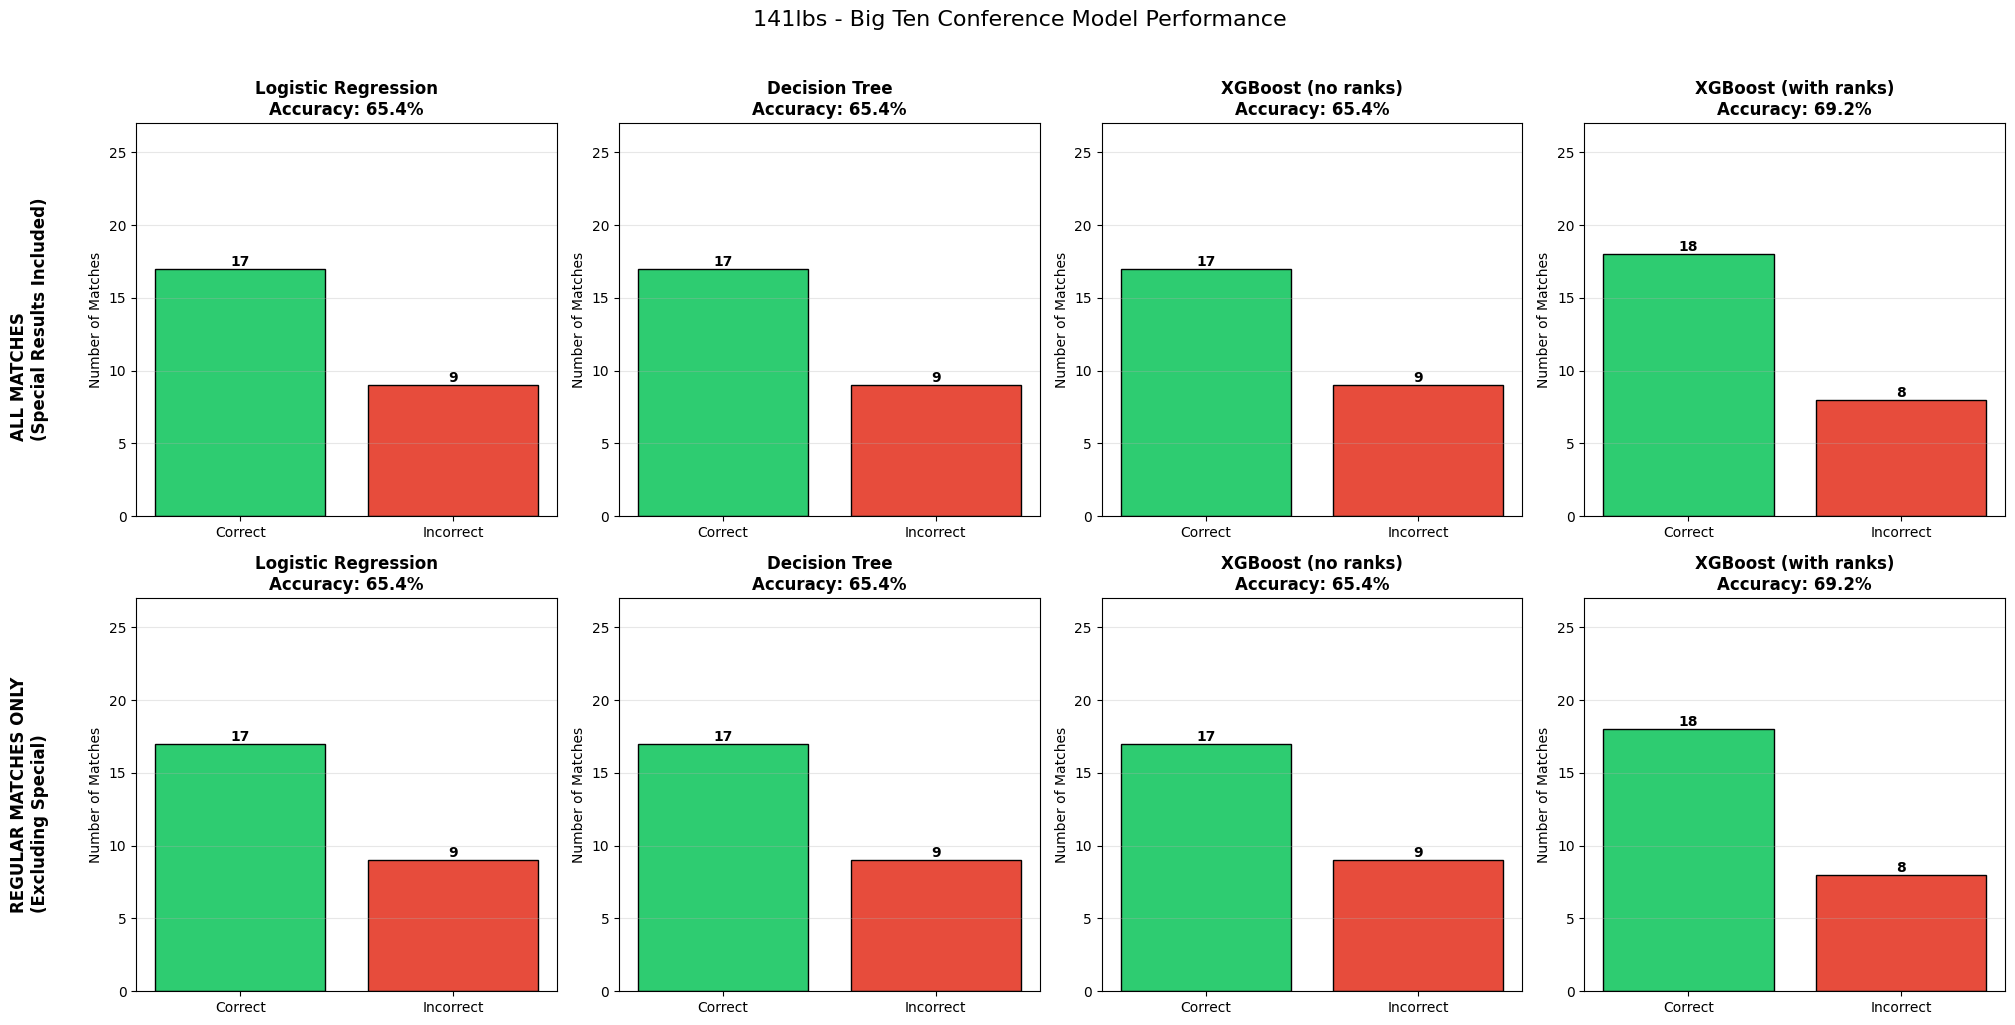


📊 MODEL RANKING - 141lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (with ranks),69.2%,18/26
1,Logistic Regression,65.4%,17/26
2,Decision Tree,65.4%,17/26
3,XGBoost (no ranks),65.4%,17/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (with ranks),69.2%,18/26
1,Logistic Regression,65.4%,17/26
2,Decision Tree,65.4%,17/26
3,XGBoost (no ranks),65.4%,17/26



📊 SUMMARY STATISTICS - 141lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,141lbs
2,Total Matches Evaluated,26
3,Unique Matchups,26
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,0 (0.0%)
6,Regular Matches,26 (100.0%)
7,Best Model (All Matches),XGBoost (with ranks)
8,Best Model Accuracy (All Matches),69.2%
9,Best Model (Regular Only),XGBoost (with ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 141lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,65.4%,17/26,65.4%,17/26
1,Decision Tree,65.4%,17/26,65.4%,17/26
2,XGBoost (no ranks),65.4%,17/26,65.4%,17/26
3,XGBoost (with ranks),69.2%,18/26,69.2%,18/26



✅ Completed 141lbs evaluation. Total results stored: 3


In [122]:
# ============================================
# 141lbs BIG TEN RESULTS - CORRECTED NAME
# ============================================

# Define 141lbs wrestlers with correct spelling
wrestlers_141 = [
    'Jesse Mendez', 'Brock Hardy', 'Nasir Bailey', 'Vance Vombaur',
    'Joey Olivieri', 'Dario Lemus', 'Braeden Davis', 'Billy Dekraker',  # Fixed spelling
    'Dylan Ragusin', 'Danny Pucino', 'Greyson Clark', 'Henry Porter',
    'Carson Exferd', 'Jaden Crumpler'
]

# Create 141lbs matches dictionary with correct spelling
matches_141 = {
    # Champ. Round 1
    ('Billy Dekraker', 'Henry Porter', 'Champ. Round 1'): 'Billy Dekraker',  # TF-1.5 15-0
    ('Dylan Ragusin', 'Danny Pucino', 'Champ. Round 1'): 'Dylan Ragusin',  # Dec 7-5
    ('Nasir Bailey', 'Carson Exferd', 'Champ. Round 1'): 'Nasir Bailey',  # Dec 8-4
    ('Vance Vombaur', 'Jaden Crumpler', 'Champ. Round 1'): 'Vance Vombaur',  # Fall 4:10
    ('Braeden Davis', 'Dario Lemus', 'Champ. Round 1'): 'Braeden Davis',  # Dec 6-4
    ('Joey Olivieri', 'Greyson Clark', 'Champ. Round 1'): 'Joey Olivieri',  # Dec 4-2

    # Quarterfinals
    ('Jesse Mendez', 'Billy Dekraker', 'Quarterfinal'): 'Jesse Mendez',  # Fall 1:04
    ('Nasir Bailey', 'Dylan Ragusin', 'Quarterfinal'): 'Nasir Bailey',  # MD 9-1
    ('Vance Vombaur', 'Braeden Davis', 'Quarterfinal'): 'Vance Vombaur',  # TF-1.5 20-5
    ('Brock Hardy', 'Joey Olivieri', 'Quarterfinal'): 'Brock Hardy',  # MD 8-0

    # Cons. Round 1
    ('Danny Pucino', 'Carson Exferd', 'Cons. Round 1'): 'Danny Pucino',  # Dec 10-7
    ('Dario Lemus', 'Jaden Crumpler', 'Cons. Round 1'): 'Dario Lemus',  # MD 10-1

    # Cons. Round 2
    ('Joey Olivieri', 'Henry Porter', 'Cons. Round 2'): 'Joey Olivieri',  # MD 13-1
    ('Braeden Davis', 'Danny Pucino', 'Cons. Round 2'): 'Braeden Davis',  # Fall 0:36
    ('Dario Lemus', 'Dylan Ragusin', 'Cons. Round 2'): 'Dario Lemus',  # Fall 2:46
    ('Billy Dekraker', 'Greyson Clark', 'Cons. Round 2'): 'Billy Dekraker',  # Dec 5-4

    # Cons. Round 3
    ('Joey Olivieri', 'Braeden Davis', 'Cons. Round 3'): 'Joey Olivieri',  # Dec 4-2
    ('Dario Lemus', 'Billy Dekraker', 'Cons. Round 3'): 'Dario Lemus',  # Dec 9-7

    # Semifinals
    ('Jesse Mendez', 'Nasir Bailey', 'Semifinal'): 'Jesse Mendez',  # TF-1.5 19-4
    ('Brock Hardy', 'Vance Vombaur', 'Semifinal'): 'Brock Hardy',  # Dec 9-2

    # Consolation Semis
    ('Nasir Bailey', 'Joey Olivieri', 'Cons. Semi'): 'Nasir Bailey',  # Dec 11-6
    ('Vance Vombaur', 'Dario Lemus', 'Cons. Semi'): 'Vance Vombaur',  # TF-1.5 20-3

    # 7th Place Match
    ('Braeden Davis', 'Billy Dekraker', '7th Place'): 'Braeden Davis',  # Dec 8-1

    # 5th Place Match
    ('Joey Olivieri', 'Dario Lemus', '5th Place'): 'Joey Olivieri',  # Dec 5-2

    # 3rd Place Match
    ('Nasir Bailey', 'Vance Vombaur', '3rd Place'): 'Nasir Bailey',  # Dec 7-4

    # Championship
    ('Jesse Mendez', 'Brock Hardy', 'Championship'): 'Jesse Mendez',  # Dec 7-2
}

# Track special matches (injury, forfeit, DQ) - none for 141lbs
special_matches_141 = []  # No special matches in 141lbs

# Setup 141lbs results
actual_results_141, special_matches_141, actual_matches_df_141 = setup_weight_class_results(
    weight_class=141,
    matches_dict=matches_141,
    conference="Big Ten"
)

# Get filtered predictions for 141lbs
weight_preds_141 = get_weight_predictions(big_ten_preds, 141, wrestlers_141)

# ============================================
# VERIFY ALL MATCHES ARE FOUND
# ============================================

print("\n🔍 Verifying all matches have predictions...")
all_found = True
for (w1, w2, round_name) in actual_results_141.keys():
    key = tuple(sorted([w1, w2]))
    if key not in weight_preds_141.apply(lambda row: tuple(sorted([row['home_wrestler'], row['away_wrestler']])), axis=1).tolist():
        print(f"⚠️ Still missing: {w1} vs {w2} ({round_name})")
        all_found = False

if all_found:
    print("✅ All matches found in predictions!")

# ============================================
# EVALUATE 141lbs
# ============================================

eval_141, summary_141 = evaluate_and_store_weight_class(
    weight_class=141,
    actual_results=actual_results_141,
    special_matches=special_matches_141,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 141lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")


📋 SETTING UP 149lbs Big Ten TOURNAMENT RESULTS

📊 149lbs Results Summary:
   Total matches: 26
   Special matches: 1


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Ryder Block,Michael Gioffre,Ryder Block,REGULAR
1,Champ. Round 1,Carter Young,Gavin Brown,Carter Young,REGULAR
2,Champ. Round 1,Lachlan McNeil,Clayton Jones,Lachlan McNeil,REGULAR
3,Champ. Round 1,Joseph Zargo,August Hibler,Joseph Zargo,REGULAR
4,Champ. Round 1,Chance Lamer,Joey Buttler,Chance Lamer,REGULAR
5,Champ. Round 1,Drew Roberts,Andrew Clark,Drew Roberts,REGULAR
6,Quarterfinal,Shayne Van Ness,Ryder Block,Shayne Van Ness,REGULAR
7,Quarterfinal,Lachlan McNeil,Carter Young,Lachlan McNeil,REGULAR
8,Quarterfinal,Joseph Zargo,Chance Lamer,Joseph Zargo,REGULAR
9,Quarterfinal,Ethan Stiles,Drew Roberts,Ethan Stiles,REGULAR



⚠️ Multiple meetings detected:
   Carter Young vs Lachlan McNeil: 2 matches
      Rounds:
        - Quarterfinal: Lachlan McNeil
        - 3rd Place: Lachlan McNeil

📊 149lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🔍 Verifying all matches have predictions...
✅ All matches found in predictions!

🏋️  EVALUATING 149lbs - Big Ten CONFERENCE

📊 149lbs predictions in dataset: 91 matchups

⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS
   Lachlan McNeil vs Carter Young: 2 matches
      - Quarterfinal: Lachlan McNeil wins
      - 3rd Place: Lachlan McNeil wins

📊 DETAILED EVALUATION - 149lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Ryder Block,Michael Gioffre,1 of 1,Ryder Block,✅,57.0%,✅,61.1%,✅,70.6%,✅,79.1%
1,Champ. Round 1,Carter Young,Gavin Brown,1 of 1,Carter Young,✅,66.6%,✅,74.6%,✅,67.0%,✅,57.5%
2,Champ. Round 1,Lachlan McNeil,Clayton Jones,1 of 1,Lachlan McNeil,✅,70.4%,✅,89.0%,✅,83.5%,✅,95.4%
3,Champ. Round 1,Joseph Zargo,August Hibler,1 of 1,Joseph Zargo,✅,85.9%,✅,89.0%,✅,91.1%,✅,97.1%
4,Champ. Round 1,Chance Lamer,Joey Buttler,1 of 1,Chance Lamer,✅,54.1%,✅,61.1%,✅,65.6%,✅,86.0%
5,Champ. Round 1,Drew Roberts,Andrew Clark,1 of 1,Drew Roberts,❌,53.1%,❌,61.1%,❌,59.3%,❌,67.1%
6,Quarterfinal,Shayne Van Ness,Ryder Block,1 of 1,Shayne Van Ness,✅,69.6%,✅,89.0%,✅,81.9%,✅,68.5%
7,Quarterfinal,Lachlan McNeil,Carter Young,1 of 1,Lachlan McNeil,❌,56.0%,❌,61.1%,✅,50.9%,✅,85.7%
8,Quarterfinal,Joseph Zargo,Chance Lamer,1 of 1,Joseph Zargo,✅,67.2%,✅,74.6%,✅,79.7%,✅,77.9%
9,Quarterfinal,Ethan Stiles,Drew Roberts,1 of 1,Ethan Stiles,✅,60.8%,✅,74.6%,✅,63.9%,✅,62.1%



📊 MODEL ACCURACY METRICS - 149lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,19/26,73.1%
1,Decision Tree,17/26,65.4%
2,XGBoost (no ranks),18/26,69.2%
3,XGBoost (with ranks),17/26,65.4%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,18/25,72.0%
1,Decision Tree,16/25,64.0%
2,XGBoost (no ranks),17/25,68.0%
3,XGBoost (with ranks),16/25,64.0%


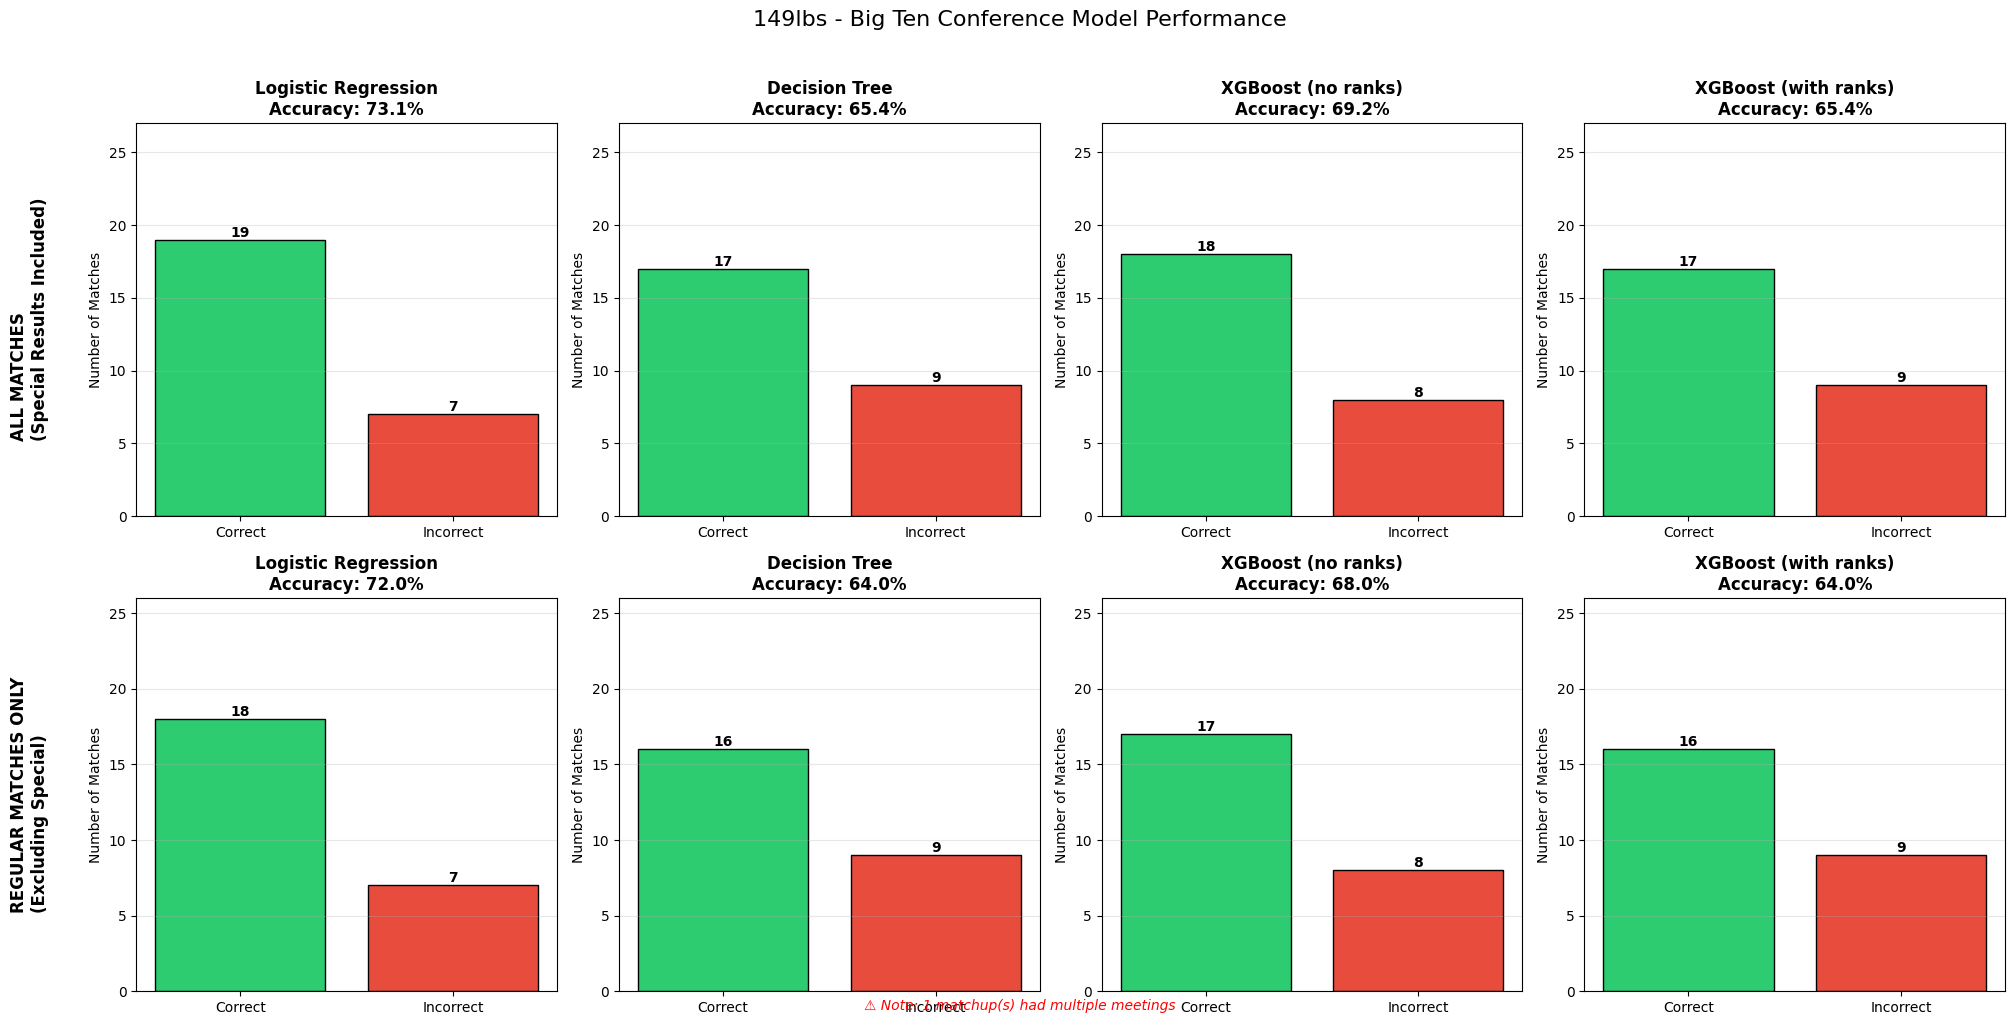


📊 MODEL RANKING - 149lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Logistic Regression,73.1%,19/26
1,XGBoost (no ranks),69.2%,18/26
2,Decision Tree,65.4%,17/26
3,XGBoost (with ranks),65.4%,17/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Logistic Regression,72.0%,18/25
1,XGBoost (no ranks),68.0%,17/25
2,Decision Tree,64.0%,16/25
3,XGBoost (with ranks),64.0%,16/25



📊 SUMMARY STATISTICS - 149lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,149lbs
2,Total Matches Evaluated,26
3,Unique Matchups,25
4,Matchups with Multiple Meetings,1
5,Matches with Special Results,1 (3.8%)
6,Regular Matches,25 (96.2%)
7,Best Model (All Matches),Logistic Regression
8,Best Model Accuracy (All Matches),73.1%
9,Best Model (Regular Only),Logistic Regression



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 149lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,73.1%,19/26,72.0%,18/25
1,Decision Tree,65.4%,17/26,64.0%,16/25
2,XGBoost (no ranks),69.2%,18/26,68.0%,17/25
3,XGBoost (with ranks),65.4%,17/26,64.0%,16/25



✅ Completed 149lbs evaluation. Total results stored: 4


In [123]:
# ============================================
# 149lbs BIG TEN RESULTS
# ============================================

# Define 149lbs wrestlers
wrestlers_149 = [
    'Shayne Van Ness', 'Ethan Stiles', 'Lachlan McNeil', 'Joseph Zargo',
    'Carter Young', 'Michael Gioffre', 'Drew Roberts', 'Chance Lamer',
    'Andrew Clark', 'Ryder Block', 'Clayton Jones', 'August Hibler',
    'Gavin Brown', 'Joey Buttler'
]

# Create 149lbs matches dictionary
matches_149 = {
    # Champ. Round 1
    ('Ryder Block', 'Michael Gioffre', 'Champ. Round 1'): 'Ryder Block',  # Dec 4-1
    ('Carter Young', 'Gavin Brown', 'Champ. Round 1'): 'Carter Young',  # Dec 8-1
    ('Lachlan McNeil', 'Clayton Jones', 'Champ. Round 1'): 'Lachlan McNeil',  # Fall 5:26
    ('Joseph Zargo', 'August Hibler', 'Champ. Round 1'): 'Joseph Zargo',  # Dec 9-7
    ('Chance Lamer', 'Joey Buttler', 'Champ. Round 1'): 'Chance Lamer',  # MD 9-1
    ('Drew Roberts', 'Andrew Clark', 'Champ. Round 1'): 'Drew Roberts',  # Dec 5-3

    # Quarterfinals
    ('Shayne Van Ness', 'Ryder Block', 'Quarterfinal'): 'Shayne Van Ness',  # Dec 5-4
    ('Lachlan McNeil', 'Carter Young', 'Quarterfinal'): 'Lachlan McNeil',  # Dec 5-3
    ('Joseph Zargo', 'Chance Lamer', 'Quarterfinal'): 'Joseph Zargo',  # Dec 9-6
    ('Ethan Stiles', 'Drew Roberts', 'Quarterfinal'): 'Ethan Stiles',  # Dec 4-1

    # Cons. Round 1
    ('Clayton Jones', 'Gavin Brown', 'Cons. Round 1'): 'Clayton Jones',  # MD 10-2
    ('August Hibler', 'Joey Buttler', 'Cons. Round 1'): 'August Hibler',  # SV-1 9-8

    # Cons. Round 2
    ('Michael Gioffre', 'Drew Roberts', 'Cons. Round 2'): 'Michael Gioffre',  # MD 12-3
    ('Clayton Jones', 'Chance Lamer', 'Cons. Round 2'): 'Clayton Jones',  # Fall 0:35
    ('Carter Young', 'August Hibler', 'Cons. Round 2'): 'Carter Young',  # MD 8-0
    ('Andrew Clark', 'Ryder Block', 'Cons. Round 2'): 'Andrew Clark',  # Dec 4-0

    # Cons. Round 3
    ('Michael Gioffre', 'Clayton Jones', 'Cons. Round 3'): 'Michael Gioffre',  # Fall 3:34
    ('Carter Young', 'Andrew Clark', 'Cons. Round 3'): 'Carter Young',  # MD 12-2

    # Semifinals
    ('Shayne Van Ness', 'Lachlan McNeil', 'Semifinal'): 'Shayne Van Ness',  # Dec 11-10
    ('Ethan Stiles', 'Joseph Zargo', 'Semifinal'): 'Ethan Stiles',  # Dec 4-3

    # Consolation Semis
    ('Lachlan McNeil', 'Michael Gioffre', 'Cons. Semi'): 'Lachlan McNeil',  # Dec 8-3
    ('Carter Young', 'Joseph Zargo', 'Cons. Semi'): 'Carter Young',  # MD 11-3

    # 7th Place Match
    ('Andrew Clark', 'Clayton Jones', '7th Place'): 'Andrew Clark (MFFL)',  # Medical forfeit

    # 5th Place Match
    ('Joseph Zargo', 'Michael Gioffre', '5th Place'): 'Joseph Zargo',  # Dec 9-3

    # 3rd Place Match
    ('Lachlan McNeil', 'Carter Young', '3rd Place'): 'Lachlan McNeil',  # Dec 1-0

    # Championship
    ('Shayne Van Ness', 'Ethan Stiles', 'Championship'): 'Shayne Van Ness',  # Fall 3:29
}

# Track special matches (injury, forfeit, DQ)
special_matches_149 = [
    ('Andrew Clark', 'Clayton Jones', '7th Place'),  # Medical forfeit
]

# Setup 149lbs results
actual_results_149, special_matches_149, actual_matches_df_149 = setup_weight_class_results(
    weight_class=149,
    matches_dict=matches_149,
    conference="Big Ten"
)

# Get filtered predictions for 149lbs
weight_preds_149 = get_weight_predictions(big_ten_preds, 149, wrestlers_149)

# ============================================
# VERIFY ALL MATCHES ARE FOUND
# ============================================

print("\n🔍 Verifying all matches have predictions...")
all_found = True
missing_matches = []

for (w1, w2, round_name) in actual_results_149.keys():
    key = tuple(sorted([w1, w2]))
    # Check if this matchup exists in predictions
    found = False
    for _, row in weight_preds_149.iterrows():
        if tuple(sorted([row['home_wrestler'], row['away_wrestler']])) == key:
            found = True
            break
    if not found:
        missing_matches.append(f"{w1} vs {w2} ({round_name})")
        all_found = False

if all_found:
    print("✅ All matches found in predictions!")
else:
    print(f"\n⚠️ Missing {len(missing_matches)} matches:")
    for match in missing_matches[:10]:
        print(f"   - {match}")
    if len(missing_matches) > 10:
        print(f"   ... and {len(missing_matches) - 10} more")

# ============================================
# EVALUATE 149lbs
# ============================================

eval_149, summary_149 = evaluate_and_store_weight_class(
    weight_class=149,
    actual_results=actual_results_149,
    special_matches=special_matches_149,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 149lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")


📋 SETTING UP 157lbs Big Ten TOURNAMENT RESULTS

📊 157lbs Results Summary:
   Total matches: 26
   Special matches: 4


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Luke Mechler,Stoney Buell,Luke Mechler,REGULAR
1,Champ. Round 1,Darius Marines,Anthony White,Darius Marines,REGULAR
2,Champ. Round 1,Cam Catrabone,Mekhi Neal,Cam Catrabone,REGULAR
3,Champ. Round 1,Kannon Webster,Ty Wilson,Kannon Webster,REGULAR
4,Champ. Round 1,Charlie Millard,Bryce Lowery,Charlie Millard,REGULAR
5,Champ. Round 1,Brandon Cannon,Victor Voinovich,Brandon Cannon,REGULAR
6,Quarterfinal,Antrell Taylor,Luke Mechler,Antrell Taylor,REGULAR
7,Quarterfinal,Cam Catrabone,Darius Marines,Cam Catrabone,REGULAR
8,Quarterfinal,Kannon Webster,Charlie Millard,Kannon Webster,REGULAR
9,Quarterfinal,PJ Duke,Brandon Cannon,PJ Duke,REGULAR



✅ No multiple meetings detected

📊 157lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🔍 Verifying all matches have predictions...
✅ All matches found in predictions!

🏋️  EVALUATING 157lbs - Big Ten CONFERENCE

📊 157lbs predictions in dataset: 91 matchups

📊 DETAILED EVALUATION - 157lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Luke Mechler,Stoney Buell,1 of 1,Luke Mechler,✅,58.9%,✅,61.1%,✅,65.6%,✅,74.0%
1,Champ. Round 1,Darius Marines,Anthony White,1 of 1,Darius Marines,❌,63.5%,❌,74.6%,❌,73.1%,❌,93.7%
2,Champ. Round 1,Cam Catrabone,Mekhi Neal,1 of 1,Cam Catrabone,✅,80.0%,✅,89.0%,✅,90.6%,✅,97.4%
3,Champ. Round 1,Kannon Webster,Ty Wilson,1 of 1,Kannon Webster,✅,68.7%,✅,74.6%,✅,83.2%,✅,96.1%
4,Champ. Round 1,Charlie Millard,Bryce Lowery,1 of 1,Charlie Millard,✅,59.4%,✅,61.1%,✅,76.8%,✅,85.1%
5,Champ. Round 1,Brandon Cannon,Victor Voinovich,1 of 1,Brandon Cannon,✅,63.5%,✅,89.0%,✅,82.3%,✅,82.1%
6,Quarterfinal,Antrell Taylor,Luke Mechler,1 of 1,Antrell Taylor,✅,59.7%,✅,74.6%,✅,59.9%,✅,73.8%
7,Quarterfinal,Cam Catrabone,Darius Marines,1 of 1,Cam Catrabone,✅,62.7%,✅,74.6%,✅,77.1%,✅,93.1%
8,Quarterfinal,Kannon Webster,Charlie Millard,1 of 1,Kannon Webster,✅,63.9%,✅,74.6%,✅,75.4%,✅,72.6%
9,Quarterfinal,PJ Duke,Brandon Cannon,1 of 1,PJ Duke,❌,53.9%,❌,53.1%,❌,65.1%,❌,59.4%



📊 MODEL ACCURACY METRICS - 157lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,18/26,69.2%
1,Decision Tree,19/26,73.1%
2,XGBoost (no ranks),20/26,76.9%
3,XGBoost (with ranks),20/26,76.9%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,14/22,63.6%
1,Decision Tree,16/22,72.7%
2,XGBoost (no ranks),17/22,77.3%
3,XGBoost (with ranks),17/22,77.3%


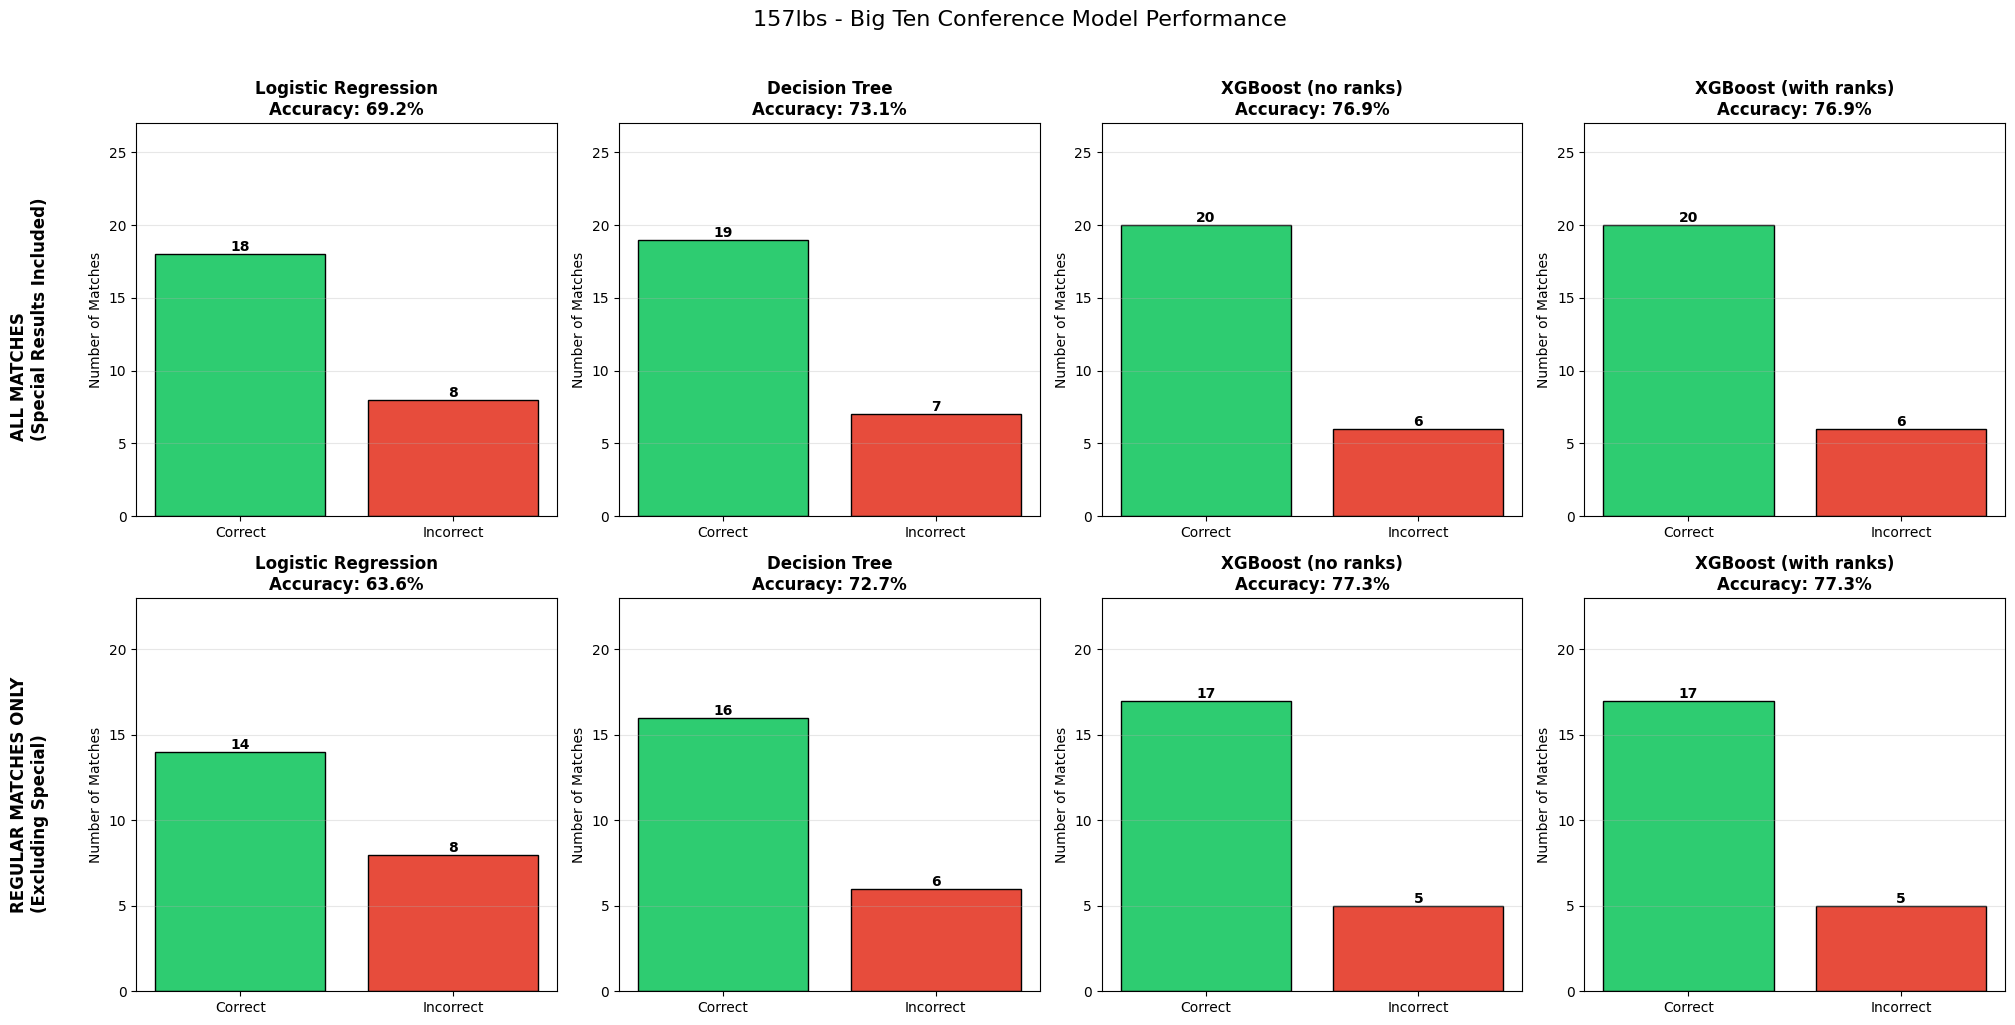


📊 MODEL RANKING - 157lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (no ranks),76.9%,20/26
1,XGBoost (with ranks),76.9%,20/26
2,Decision Tree,73.1%,19/26
3,Logistic Regression,69.2%,18/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (no ranks),77.3%,17/22
1,XGBoost (with ranks),77.3%,17/22
2,Decision Tree,72.7%,16/22
3,Logistic Regression,63.6%,14/22



📊 SUMMARY STATISTICS - 157lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,157lbs
2,Total Matches Evaluated,26
3,Unique Matchups,26
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,4 (15.4%)
6,Regular Matches,22 (84.6%)
7,Best Model (All Matches),XGBoost (no ranks)
8,Best Model Accuracy (All Matches),76.9%
9,Best Model (Regular Only),XGBoost (no ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 157lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,69.2%,18/26,63.6%,14/22
1,Decision Tree,73.1%,19/26,72.7%,16/22
2,XGBoost (no ranks),76.9%,20/26,77.3%,17/22
3,XGBoost (with ranks),76.9%,20/26,77.3%,17/22



✅ Completed 157lbs evaluation. Total results stored: 5


In [124]:
# ============================================
# 157lbs BIG TEN RESULTS - CORRECTED NAMES
# ============================================

# Define 157lbs wrestlers with correct spellings from the data
wrestlers_157 = [
    'PJ Duke', 'Antrell Taylor', 'Kannon Webster', 'Brandon Cannon',
    'Cam Catrabone', 'Bryce Lowery', 'Charlie Millard', 'Luke Mechler',  # Cam Catrabone (not Cameron)
    'Darius Marines', 'Anthony White', 'Stoney Buell', 'Victor Voinovich',  # Anthony White (not Tony)
    'Mekhi Neal', 'Ty Wilson'
]

# Create 157lbs matches dictionary with correct names
matches_157 = {
    # Champ. Round 1
    ('Luke Mechler', 'Stoney Buell', 'Champ. Round 1'): 'Luke Mechler',  # Dec 7-2
    ('Darius Marines', 'Anthony White', 'Champ. Round 1'): 'Darius Marines',  # Dec 4-3  # Tony -> Anthony
    ('Cam Catrabone', 'Mekhi Neal', 'Champ. Round 1'): 'Cam Catrabone',  # Fall 4:28  # Cameron -> Cam
    ('Kannon Webster', 'Ty Wilson', 'Champ. Round 1'): 'Kannon Webster',  # Fall 4:28
    ('Charlie Millard', 'Bryce Lowery', 'Champ. Round 1'): 'Charlie Millard',  # MD 12-4
    ('Brandon Cannon', 'Victor Voinovich', 'Champ. Round 1'): 'Brandon Cannon',  # Dec 6-0

    # Quarterfinals
    ('Antrell Taylor', 'Luke Mechler', 'Quarterfinal'): 'Antrell Taylor',  # Dec 8-1
    ('Cam Catrabone', 'Darius Marines', 'Quarterfinal'): 'Cam Catrabone',  # TF-1.5 15-0  # Cameron -> Cam
    ('Kannon Webster', 'Charlie Millard', 'Quarterfinal'): 'Kannon Webster',  # MD 14-2
    ('PJ Duke', 'Brandon Cannon', 'Quarterfinal'): 'PJ Duke',  # MD 20-7

    # Cons. Round 1
    ('Anthony White', 'Mekhi Neal', 'Cons. Round 1'): 'Anthony White',  # Dec 8-1  # Tony -> Anthony
    ('Bryce Lowery', 'Ty Wilson', 'Cons. Round 1'): 'Bryce Lowery',  # Dec 4-1

    # Cons. Round 2
    ('Brandon Cannon', 'Stoney Buell', 'Cons. Round 2'): 'Brandon Cannon (INJURY)',  # Injury default (0:04)
    ('Charlie Millard', 'Anthony White', 'Cons. Round 2'): 'Charlie Millard',  # Dec 4-2  # Tony -> Anthony
    ('Bryce Lowery', 'Darius Marines', 'Cons. Round 2'): 'Bryce Lowery',  # Dec 5-4
    ('Luke Mechler', 'Victor Voinovich', 'Cons. Round 2'): 'Luke Mechler',  # Dec 8-3

    # Cons. Round 3
    ('Brandon Cannon', 'Charlie Millard', 'Cons. Round 3'): 'Brandon Cannon',  # Dec 9-4
    ('Bryce Lowery', 'Luke Mechler', 'Cons. Round 3'): 'Bryce Lowery',  # MD 9-1

    # Semifinals
    ('Antrell Taylor', 'Cam Catrabone', 'Semifinal'): 'Antrell Taylor',  # Dec 7-1  # Cameron -> Cam
    ('PJ Duke', 'Kannon Webster', 'Semifinal'): 'PJ Duke',  # Dec 4-2

    # Consolation Semis
    ('Brandon Cannon', 'Cam Catrabone', 'Cons. Semi'): 'Brandon Cannon',  # Dec 4-0  # Cameron -> Cam
    ('Kannon Webster', 'Bryce Lowery', 'Cons. Semi'): 'Kannon Webster (INJURY)',  # Injury default (1:09)

    # 7th Place Match
    ('Luke Mechler', 'Charlie Millard', '7th Place'): 'Luke Mechler (MFFL)',  # Medical forfeit

    # 5th Place Match
    ('Cam Catrabone', 'Bryce Lowery', '5th Place'): 'Cam Catrabone (MFFL)',  # Medical forfeit  # Cameron -> Cam

    # 3rd Place Match
    ('Kannon Webster', 'Brandon Cannon', '3rd Place'): 'Kannon Webster',  # Dec 9-2

    # Championship
    ('PJ Duke', 'Antrell Taylor', 'Championship'): 'PJ Duke',  # MD 12-4
}

# Track special matches (injury, forfeit, DQ)
special_matches_157 = [
    ('Brandon Cannon', 'Stoney Buell', 'Cons. Round 2'),      # Injury default
    ('Kannon Webster', 'Bryce Lowery', 'Cons. Semi'),         # Injury default
    ('Luke Mechler', 'Charlie Millard', '7th Place'),         # Medical forfeit
    ('Cam Catrabone', 'Bryce Lowery', '5th Place'),           # Medical forfeit
]

# Setup 157lbs results
actual_results_157, special_matches_157, actual_matches_df_157 = setup_weight_class_results(
    weight_class=157,
    matches_dict=matches_157,
    conference="Big Ten"
)

# Get filtered predictions for 157lbs
weight_preds_157 = get_weight_predictions(big_ten_preds, 157, wrestlers_157)

# ============================================
# VERIFY ALL MATCHES ARE FOUND
# ============================================

print("\n🔍 Verifying all matches have predictions...")
all_found = True
missing_matches = []

for (w1, w2, round_name) in actual_results_157.keys():
    key = tuple(sorted([w1, w2]))
    # Check if this matchup exists in predictions
    found = False
    for _, row in weight_preds_157.iterrows():
        if tuple(sorted([row['home_wrestler'], row['away_wrestler']])) == key:
            found = True
            break
    if not found:
        missing_matches.append(f"{w1} vs {w2} ({round_name})")
        all_found = False

if all_found:
    print("✅ All matches found in predictions!")
else:
    print(f"\n⚠️ Missing {len(missing_matches)} matches:")
    for match in missing_matches[:10]:  # Show first 10
        print(f"   - {match}")
    if len(missing_matches) > 10:
        print(f"   ... and {len(missing_matches) - 10} more")

# ============================================
# EVALUATE 157lbs
# ============================================

eval_157, summary_157 = evaluate_and_store_weight_class(
    weight_class=157,
    actual_results=actual_results_157,
    special_matches=special_matches_157,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 157lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")


📋 SETTING UP 165lbs Big Ten TOURNAMENT RESULTS

📊 165lbs Results Summary:
   Total matches: 26
   Special matches: 2


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Paddy Gallagher,Tyler Lillard,Paddy Gallagher,REGULAR
1,Champ. Round 1,Andrew Sparks,Justin Gates,Andrew Sparks,REGULAR
2,Champ. Round 1,LJ Araujo,AJ Rodriguez,LJ Araujo,REGULAR
3,Champ. Round 1,Michael Caliendo,Jack Conley,Michael Caliendo,REGULAR
4,Champ. Round 1,Braeden Scoles,Jacob Bostelman,Braeden Scoles,REGULAR
5,Champ. Round 1,Andrew Barbosa,Cody Goebel,Andrew Barbosa,REGULAR
6,Quarterfinal,Mitchell Mesenbrink,Paddy Gallagher,Mitchell Mesenbrink,REGULAR
7,Quarterfinal,Andrew Sparks,LJ Araujo,Andrew Sparks,REGULAR
8,Quarterfinal,Michael Caliendo,Braeden Scoles,Michael Caliendo,REGULAR
9,Quarterfinal,Andrew Barbosa,Joey Blaze,Andrew Barbosa,REGULAR



✅ No multiple meetings detected

📊 165lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🔍 Verifying all matches have predictions...
✅ All matches found in predictions!

🏋️  EVALUATING 165lbs - Big Ten CONFERENCE

📊 165lbs predictions in dataset: 91 matchups

📊 DETAILED EVALUATION - 165lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Paddy Gallagher,Tyler Lillard,1 of 1,Paddy Gallagher,❌,51.5%,❌,53.1%,✅,52.4%,✅,91.9%
1,Champ. Round 1,Andrew Sparks,Justin Gates,1 of 1,Andrew Sparks,✅,73.0%,✅,74.6%,✅,87.8%,✅,94.3%
2,Champ. Round 1,LJ Araujo,AJ Rodriguez,1 of 1,LJ Araujo,✅,65.6%,✅,74.6%,✅,71.6%,✅,94.3%
3,Champ. Round 1,Michael Caliendo,Jack Conley,1 of 1,Michael Caliendo,✅,81.2%,✅,89.0%,✅,90.6%,✅,97.7%
4,Champ. Round 1,Braeden Scoles,Jacob Bostelman,1 of 1,Braeden Scoles,✅,70.8%,✅,89.0%,✅,87.1%,✅,96.0%
5,Champ. Round 1,Andrew Barbosa,Cody Goebel,1 of 1,Andrew Barbosa,✅,62.4%,✅,74.6%,✅,74.4%,✅,72.3%
6,Quarterfinal,Mitchell Mesenbrink,Paddy Gallagher,1 of 1,Mitchell Mesenbrink,✅,73.4%,✅,89.0%,✅,83.8%,✅,84.6%
7,Quarterfinal,Andrew Sparks,LJ Araujo,1 of 1,Andrew Sparks,✅,58.4%,✅,53.1%,✅,71.8%,✅,79.0%
8,Quarterfinal,Michael Caliendo,Braeden Scoles,1 of 1,Michael Caliendo,✅,58.1%,✅,61.1%,✅,70.5%,✅,78.7%
9,Quarterfinal,Andrew Barbosa,Joey Blaze,1 of 1,Andrew Barbosa,❌,64.7%,❌,74.6%,❌,80.8%,❌,64.2%



📊 MODEL ACCURACY METRICS - 165lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,20/26,76.9%
1,Decision Tree,18/26,69.2%
2,XGBoost (no ranks),20/26,76.9%
3,XGBoost (with ranks),20/26,76.9%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,19/24,79.2%
1,Decision Tree,17/24,70.8%
2,XGBoost (no ranks),19/24,79.2%
3,XGBoost (with ranks),18/24,75.0%


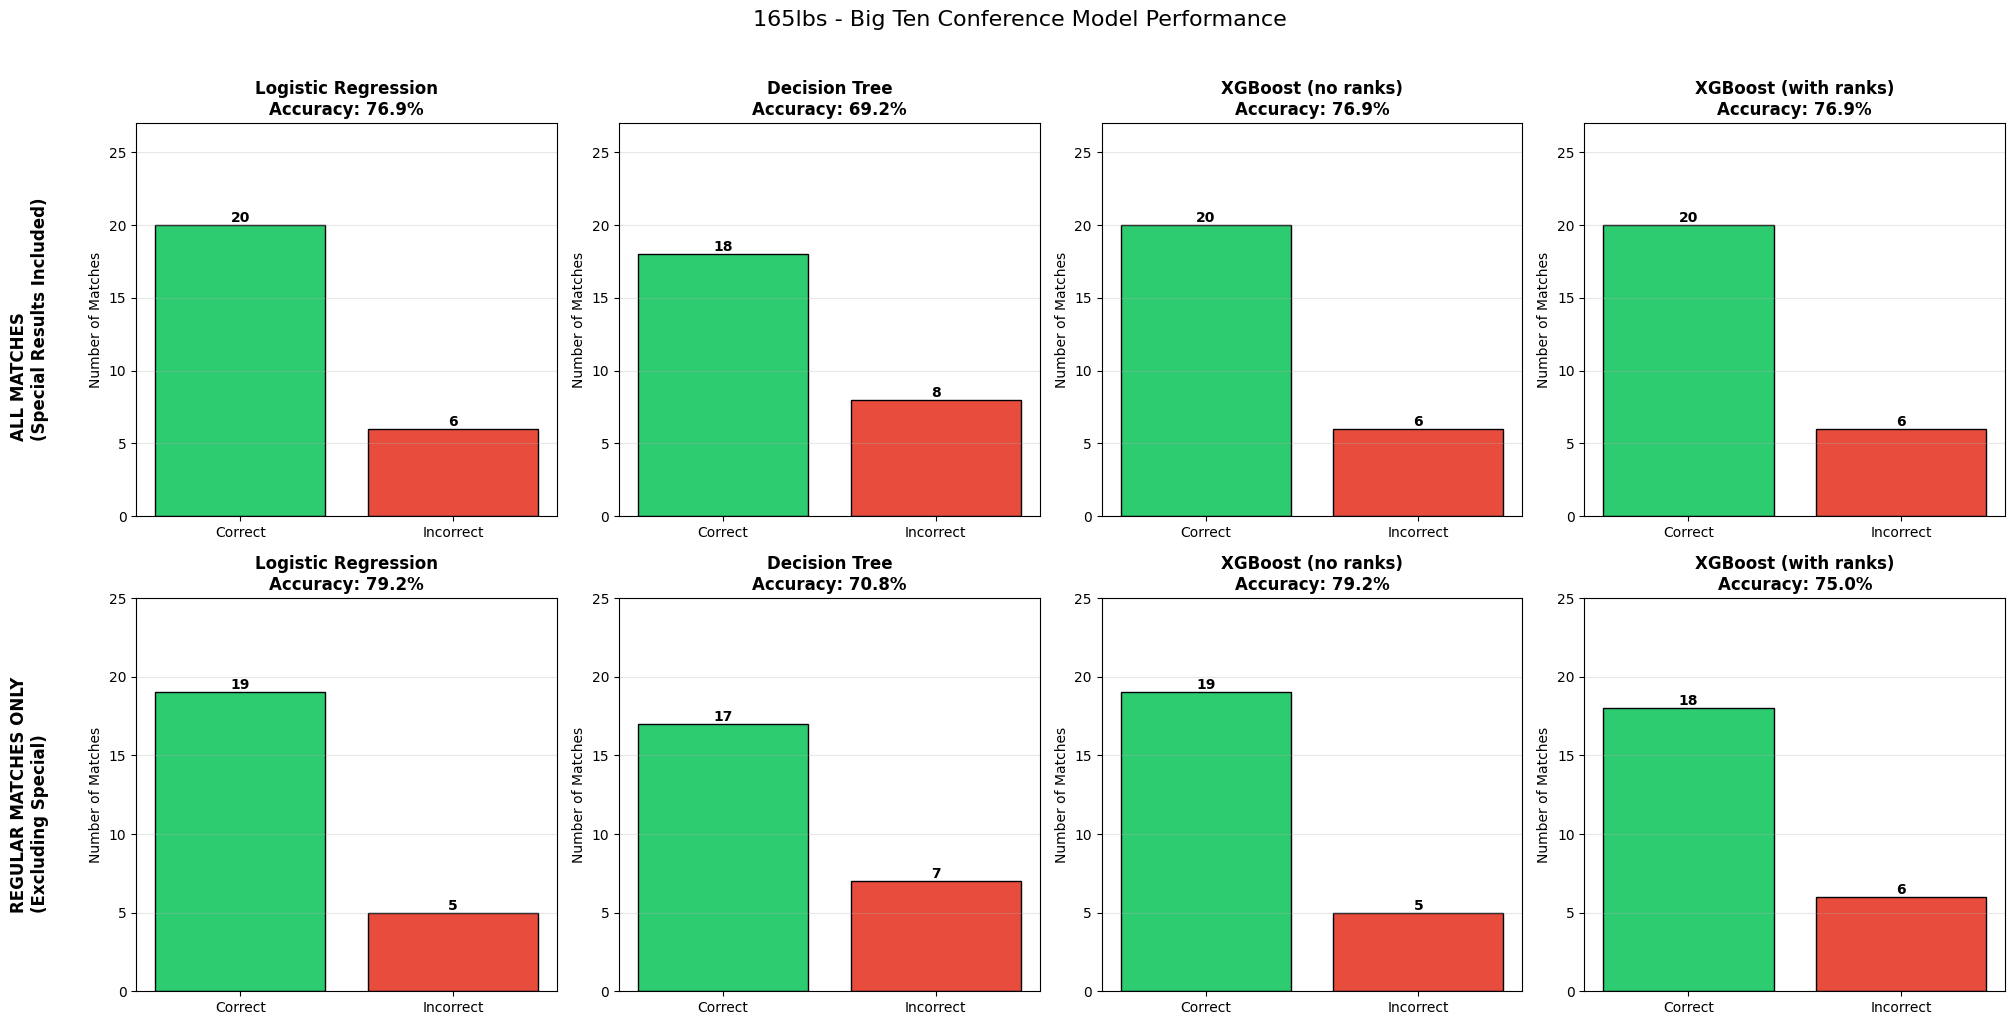


📊 MODEL RANKING - 165lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Logistic Regression,76.9%,20/26
1,XGBoost (no ranks),76.9%,20/26
2,XGBoost (with ranks),76.9%,20/26
3,Decision Tree,69.2%,18/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Logistic Regression,79.2%,19/24
1,XGBoost (no ranks),79.2%,19/24
2,XGBoost (with ranks),75.0%,18/24
3,Decision Tree,70.8%,17/24



📊 SUMMARY STATISTICS - 165lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,165lbs
2,Total Matches Evaluated,26
3,Unique Matchups,26
4,Matchups with Multiple Meetings,0
5,Matches with Special Results,2 (7.7%)
6,Regular Matches,24 (92.3%)
7,Best Model (All Matches),Logistic Regression
8,Best Model Accuracy (All Matches),76.9%
9,Best Model (Regular Only),Logistic Regression



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 165lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,76.9%,20/26,79.2%,19/24
1,Decision Tree,69.2%,18/26,70.8%,17/24
2,XGBoost (no ranks),76.9%,20/26,79.2%,19/24
3,XGBoost (with ranks),76.9%,20/26,75.0%,18/24



✅ Completed 165lbs evaluation. Total results stored: 6


In [125]:
# ============================================
# 165lbs BIG TEN RESULTS - CORRECTED NAMES
# ============================================

# Define 165lbs wrestlers with correct spellings from the data
wrestlers_165 = [
    'Mitchell Mesenbrink', 'Michael Caliendo', 'Andrew Sparks', 'Andrew Barbosa',  # Michael (not Mikey)
    'Joey Blaze', 'LJ Araujo', 'Paddy Gallagher', 'Braeden Scoles',
    'Tyler Lillard', 'AJ Rodriguez', 'Jack Conley', 'Cody Goebel',  # AJ Rodriguez (not Rodrigues)
    'Justin Gates', 'Jacob Bostelman'
]

# Create 165lbs matches dictionary with correct names
matches_165 = {
    # Champ. Round 1
    ('Paddy Gallagher', 'Tyler Lillard', 'Champ. Round 1'): 'Paddy Gallagher',  # Dec 4-1
    ('Andrew Sparks', 'Justin Gates', 'Champ. Round 1'): 'Andrew Sparks',  # MD 16-3
    ('LJ Araujo', 'AJ Rodriguez', 'Champ. Round 1'): 'LJ Araujo',  # Fall 6:18  # Rodrigues -> Rodriguez
    ('Michael Caliendo', 'Jack Conley', 'Champ. Round 1'): 'Michael Caliendo',  # Fall 1:39  # Mikey -> Michael
    ('Braeden Scoles', 'Jacob Bostelman', 'Champ. Round 1'): 'Braeden Scoles',  # TF-1.5 20-4
    ('Andrew Barbosa', 'Cody Goebel', 'Champ. Round 1'): 'Andrew Barbosa',  # Dec 2-1

    # Quarterfinals
    ('Mitchell Mesenbrink', 'Paddy Gallagher', 'Quarterfinal'): 'Mitchell Mesenbrink',  # MD 10-2
    ('Andrew Sparks', 'LJ Araujo', 'Quarterfinal'): 'Andrew Sparks',  # Dec 3-1
    ('Michael Caliendo', 'Braeden Scoles', 'Quarterfinal'): 'Michael Caliendo',  # MD 14-5  # Mikey -> Michael
    ('Andrew Barbosa', 'Joey Blaze', 'Quarterfinal'): 'Andrew Barbosa',  # Dec 3-2

    # Cons. Round 1
    ('AJ Rodriguez', 'Justin Gates', 'Cons. Round 1'): 'AJ Rodriguez',  # Fall 6:34  # Rodrigues -> Rodriguez
    ('Jack Conley', 'Jacob Bostelman', 'Cons. Round 1'): 'Jack Conley',  # Dec 4-2

    # Cons. Round 2
    ('Joey Blaze', 'Tyler Lillard', 'Cons. Round 2'): 'Joey Blaze',  # Dec 4-1
    ('Braeden Scoles', 'AJ Rodriguez', 'Cons. Round 2'): 'Braeden Scoles',  # TF-1.5 18-2  # Rodrigues -> Rodriguez
    ('LJ Araujo', 'Jack Conley', 'Cons. Round 2'): 'LJ Araujo',  # Fall 2:17
    ('Paddy Gallagher', 'Cody Goebel', 'Cons. Round 2'): 'Paddy Gallagher',  # MD 13-4

    # Cons. Round 3
    ('Joey Blaze', 'Braeden Scoles', 'Cons. Round 3'): 'Joey Blaze',  # Dec 5-0
    ('LJ Araujo', 'Paddy Gallagher', 'Cons. Round 3'): 'LJ Araujo',  # Dec 2-0

    # Semifinals
    ('Mitchell Mesenbrink', 'Andrew Sparks', 'Semifinal'): 'Mitchell Mesenbrink',  # TF-1.5 19-4
    ('Michael Caliendo', 'Andrew Barbosa', 'Semifinal'): 'Michael Caliendo',  # MD 11-3  # Mikey -> Michael

    # Consolation Semis
    ('Joey Blaze', 'Andrew Sparks', 'Cons. Semi'): 'Joey Blaze',  # TB-1 3-1
    ('LJ Araujo', 'Andrew Barbosa', 'Cons. Semi'): 'LJ Araujo',  # MD 11-0

    # 7th Place Match
    ('Paddy Gallagher', 'Braeden Scoles', '7th Place'): 'Paddy Gallagher (MFFL)',  # Medical forfeit

    # 5th Place Match
    ('Andrew Sparks', 'Andrew Barbosa', '5th Place'): 'Andrew Sparks',  # Dec 8-6

    # 3rd Place Match
    ('Joey Blaze', 'LJ Araujo', '3rd Place'): 'Joey Blaze (INJURY)',  # Injury default (3:47)

    # Championship
    ('Mitchell Mesenbrink', 'Michael Caliendo', 'Championship'): 'Mitchell Mesenbrink',  # MD 12-3  # Mikey -> Michael
}

# Track special matches (injury, forfeit, DQ)
special_matches_165 = [
    ('Paddy Gallagher', 'Braeden Scoles', '7th Place'),  # Medical forfeit
    ('Joey Blaze', 'LJ Araujo', '3rd Place'),           # Injury default
]

# Setup 165lbs results
actual_results_165, special_matches_165, actual_matches_df_165 = setup_weight_class_results(
    weight_class=165,
    matches_dict=matches_165,
    conference="Big Ten"
)

# Get filtered predictions for 165lbs
weight_preds_165 = get_weight_predictions(big_ten_preds, 165, wrestlers_165)

# ============================================
# VERIFY ALL MATCHES ARE FOUND
# ============================================

print("\n🔍 Verifying all matches have predictions...")
all_found = True
missing_matches = []

for (w1, w2, round_name) in actual_results_165.keys():
    key = tuple(sorted([w1, w2]))
    # Check if this matchup exists in predictions
    found = False
    for _, row in weight_preds_165.iterrows():
        if tuple(sorted([row['home_wrestler'], row['away_wrestler']])) == key:
            found = True
            break
    if not found:
        missing_matches.append(f"{w1} vs {w2} ({round_name})")
        all_found = False

if all_found:
    print("✅ All matches found in predictions!")
else:
    print(f"\n⚠️ Missing {len(missing_matches)} matches:")
    for match in missing_matches[:10]:
        print(f"   - {match}")
    if len(missing_matches) > 10:
        print(f"   ... and {len(missing_matches) - 10} more")

# ============================================
# EVALUATE 165lbs
# ============================================

eval_165, summary_165 = evaluate_and_store_weight_class(
    weight_class=165,
    actual_results=actual_results_165,
    special_matches=special_matches_165,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 165lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")


📋 SETTING UP 184lbs Big Ten TOURNAMENT RESULTS

📊 184lbs Results Summary:
   Total matches: 26
   Special matches: 5


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Angelo Ferrari,Sam Goin,Angelo Ferrari,REGULAR
1,Champ. Round 1,Chris Moore,Sepanta Ahanj-Elias,Chris Moore,REGULAR
2,Champ. Round 1,Brock Mantanona,Ryan Boucher,Brock Mantanona,REGULAR
3,Champ. Round 1,Silas Allred,Cale Anderson,Silas Allred,REGULAR
4,Champ. Round 1,Dylan Fishback,Jesse Perez,Dylan Fishback,REGULAR
5,Champ. Round 1,Shane Cartagena-Walsh,James Rowley,Shane Cartagena-Walsh,REGULAR
6,Quarterfinal,Rocco Welsh,Angelo Ferrari,Rocco Welsh,REGULAR
7,Quarterfinal,Brock Mantanona,Chris Moore,Brock Mantanona,REGULAR
8,Quarterfinal,Silas Allred,Dylan Fishback,Silas Allred,REGULAR
9,Quarterfinal,Max McEnelly,Shane Cartagena-Walsh,Max McEnelly,REGULAR



⚠️ Multiple meetings detected:
   Brock Mantanona vs Chris Moore: 2 matches
      Rounds:
        - Quarterfinal: Brock Mantanona
        - 3rd Place: Brock Mantanona

📊 184lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🏋️  EVALUATING 184lbs - Big Ten CONFERENCE

📊 184lbs predictions in dataset: 91 matchups

⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS
   Brock Mantanona vs Chris Moore: 2 matches
      - Quarterfinal: Brock Mantanona wins
      - 3rd Place: Brock Mantanona wins

📊 DETAILED EVALUATION - 184lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Angelo Ferrari,Sam Goin,1 of 1,Angelo Ferrari,✅,65.3%,✅,74.6%,✅,69.7%,✅,92.5%
1,Champ. Round 1,Chris Moore,Sepanta Ahanj-Elias,1 of 1,Chris Moore,✅,69.6%,✅,74.6%,✅,77.5%,✅,95.0%
2,Champ. Round 1,Brock Mantanona,Ryan Boucher,1 of 1,Brock Mantanona,✅,83.3%,✅,89.0%,✅,88.5%,✅,95.0%
3,Champ. Round 1,Silas Allred,Cale Anderson,1 of 1,Silas Allred,✅,72.8%,✅,74.6%,✅,72.5%,✅,85.9%
4,Champ. Round 1,Dylan Fishback,Jesse Perez,1 of 1,Dylan Fishback,✅,58.2%,✅,61.1%,✅,62.4%,✅,88.4%
5,Champ. Round 1,Shane Cartagena-Walsh,James Rowley,1 of 1,Shane Cartagena-Walsh,✅,61.3%,✅,74.6%,✅,72.8%,✅,91.7%
6,Quarterfinal,Rocco Welsh,Angelo Ferrari,1 of 1,Rocco Welsh,✅,55.7%,✅,61.1%,✅,78.4%,✅,79.2%
7,Quarterfinal,Brock Mantanona,Chris Moore,1 of 1,Brock Mantanona,✅,56.1%,✅,61.1%,✅,61.8%,✅,59.5%
8,Quarterfinal,Silas Allred,Dylan Fishback,1 of 1,Silas Allred,✅,50.2%,❌,53.1%,❌,55.0%,✅,57.6%
9,Quarterfinal,Max McEnelly,Shane Cartagena-Walsh,1 of 1,Max McEnelly,✅,62.6%,✅,74.6%,✅,67.4%,✅,60.0%



📊 MODEL ACCURACY METRICS - 184lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,23/26,88.5%
1,Decision Tree,20/26,76.9%
2,XGBoost (no ranks),21/26,80.8%
3,XGBoost (with ranks),21/26,80.8%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,21/21,100.0%
1,Decision Tree,18/21,85.7%
2,XGBoost (no ranks),19/21,90.5%
3,XGBoost (with ranks),19/21,90.5%


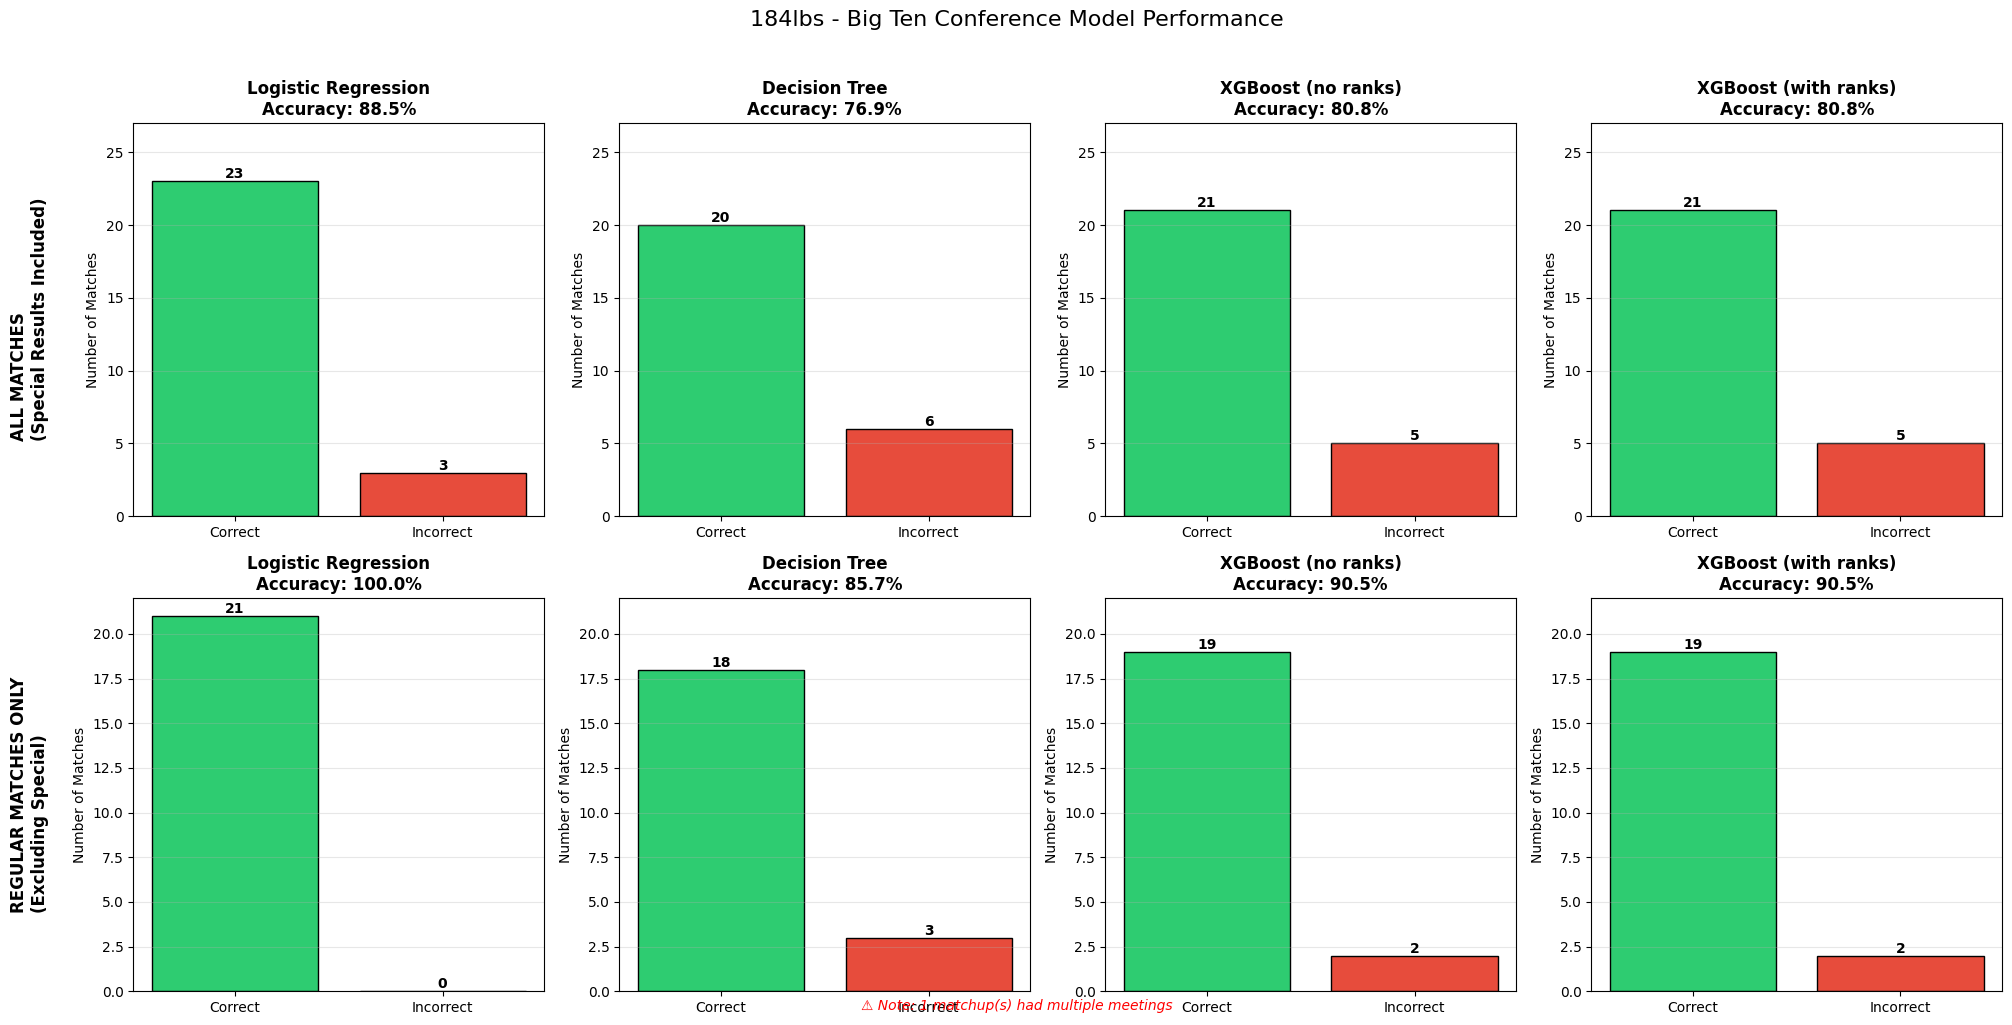


📊 MODEL RANKING - 184lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Logistic Regression,88.5%,23/26
1,XGBoost (no ranks),80.8%,21/26
2,XGBoost (with ranks),80.8%,21/26
3,Decision Tree,76.9%,20/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Logistic Regression,100.0%,21/21
1,XGBoost (no ranks),90.5%,19/21
2,XGBoost (with ranks),90.5%,19/21
3,Decision Tree,85.7%,18/21



📊 SUMMARY STATISTICS - 184lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,184lbs
2,Total Matches Evaluated,26
3,Unique Matchups,25
4,Matchups with Multiple Meetings,1
5,Matches with Special Results,5 (19.2%)
6,Regular Matches,21 (80.8%)
7,Best Model (All Matches),Logistic Regression
8,Best Model Accuracy (All Matches),88.5%
9,Best Model (Regular Only),Logistic Regression



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 184lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,88.5%,23/26,100.0%,21/21
1,Decision Tree,76.9%,20/26,85.7%,18/21
2,XGBoost (no ranks),80.8%,21/26,90.5%,19/21
3,XGBoost (with ranks),80.8%,21/26,90.5%,19/21



✅ Completed 184lbs evaluation. Total results stored: 7


In [126]:
# ============================================
# 184lbs BIG TEN RESULTS - CORRECTED NAMES
# ============================================

# Define 184lbs wrestlers with correct spellings from the data
wrestlers_184 = [
    'Rocco Welsh', 'Max McEnelly', 'Brock Mantanona', 'Chris Moore',
    'Shane Cartagena-Walsh', 'Silas Allred', 'Dylan Fishback', 'Angelo Ferrari',
    'Sam Goin', 'Sepanta Ahanj-Elias', 'Jesse Perez', 'James Rowley',  # J.D. Perez -> Jesse Perez
    'Ryan Boucher', 'Cale Anderson'
]

# Create 184lbs matches dictionary with correct names
matches_184 = {
    # Champ. Round 1
    ('Angelo Ferrari', 'Sam Goin', 'Champ. Round 1'): 'Angelo Ferrari',  # Dec 9-3
    ('Chris Moore', 'Sepanta Ahanj-Elias', 'Champ. Round 1'): 'Chris Moore',  # Dec 8-2
    ('Brock Mantanona', 'Ryan Boucher', 'Champ. Round 1'): 'Brock Mantanona',  # TF-1.5 20-3
    ('Silas Allred', 'Cale Anderson', 'Champ. Round 1'): 'Silas Allred',  # TF-1.5 20-2
    ('Dylan Fishback', 'Jesse Perez', 'Champ. Round 1'): 'Dylan Fishback',  # TF-1.5 17-2  # J.D. -> Jesse
    ('Shane Cartagena-Walsh', 'James Rowley', 'Champ. Round 1'): 'Shane Cartagena-Walsh',  # SV-1 5-2

    # Quarterfinals
    ('Rocco Welsh', 'Angelo Ferrari', 'Quarterfinal'): 'Rocco Welsh',  # TB-1 3-2
    ('Brock Mantanona', 'Chris Moore', 'Quarterfinal'): 'Brock Mantanona',  # Dec 4-1
    ('Silas Allred', 'Dylan Fishback', 'Quarterfinal'): 'Silas Allred',  # SV-1 4-1
    ('Max McEnelly', 'Shane Cartagena-Walsh', 'Quarterfinal'): 'Max McEnelly',  # TF-1.5 21-6

    # Cons. Round 1
    ('Sepanta Ahanj-Elias', 'Ryan Boucher', 'Cons. Round 1'): 'Sepanta Ahanj-Elias',  # Dec 4-2
    ('Jesse Perez', 'Cale Anderson', 'Cons. Round 1'): 'Jesse Perez',  # Dec 12-8  # J.D. -> Jesse

    # Cons. Round 2
    ('Shane Cartagena-Walsh', 'Sam Goin', 'Cons. Round 2'): 'Shane Cartagena-Walsh',  # Dec 12-7
    ('Dylan Fishback', 'Sepanta Ahanj-Elias', 'Cons. Round 2'): 'Dylan Fishback',  # TF-1.5 17-1
    ('Chris Moore', 'Jesse Perez', 'Cons. Round 2'): 'Chris Moore',  # TF-1.5 19-3  # J.D. -> Jesse
    ('Angelo Ferrari', 'James Rowley', 'Cons. Round 2'): 'Angelo Ferrari',  # Dec 5-1

    # Cons. Round 3
    ('Shane Cartagena-Walsh', 'Dylan Fishback', 'Cons. Round 3'): 'Shane Cartagena-Walsh',  # Dec 7-2
    ('Chris Moore', 'Angelo Ferrari', 'Cons. Round 3'): 'Chris Moore (MFFL)',  # Medical forfeit

    # Semifinals
    ('Rocco Welsh', 'Brock Mantanona', 'Semifinal'): 'Rocco Welsh',  # SV-1 8-5
    ('Max McEnelly', 'Silas Allred', 'Semifinal'): 'Max McEnelly (INJURY)',  # Injury default (0:01)

    # Consolation Semis
    ('Brock Mantanona', 'Shane Cartagena-Walsh', 'Cons. Semi'): 'Brock Mantanona',  # MD 10-2
    ('Chris Moore', 'Silas Allred', 'Cons. Semi'): 'Chris Moore (MFFL)',  # Medical forfeit

    # 7th Place Match
    ('Dylan Fishback', 'Angelo Ferrari', '7th Place'): 'Dylan Fishback (MFFL)',  # Medical forfeit

    # 5th Place Match
    ('Shane Cartagena-Walsh', 'Silas Allred', '5th Place'): 'Shane Cartagena-Walsh (MFFL)',  # Medical forfeit

    # 3rd Place Match
    ('Brock Mantanona', 'Chris Moore', '3rd Place'): 'Brock Mantanona',  # SV-1 4-1

    # Championship
    ('Rocco Welsh', 'Max McEnelly', 'Championship'): 'Rocco Welsh',  # TB-1 2-1
}

# Track special matches (injury, forfeit, DQ)
special_matches_184 = [
    ('Max McEnelly', 'Silas Allred', 'Semifinal'),           # Injury default (0:01!)
    ('Chris Moore', 'Angelo Ferrari', 'Cons. Round 3'),      # Medical forfeit
    ('Chris Moore', 'Silas Allred', 'Cons. Semi'),           # Medical forfeit
    ('Dylan Fishback', 'Angelo Ferrari', '7th Place'),       # Medical forfeit
    ('Shane Cartagena-Walsh', 'Silas Allred', '5th Place'),  # Medical forfeit
]

# Setup 184lbs results
actual_results_184, special_matches_184, actual_matches_df_184 = setup_weight_class_results(
    weight_class=184,
    matches_dict=matches_184,
    conference="Big Ten"
)

# Get filtered predictions for 184lbs
weight_preds_184 = get_weight_predictions(big_ten_preds, 184, wrestlers_184)

# ============================================
# EVALUATE 184lbs
# ============================================

eval_184, summary_184 = evaluate_and_store_weight_class(
    weight_class=184,
    actual_results=actual_results_184,
    special_matches=special_matches_184,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 184lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")


📋 SETTING UP 197lbs Big Ten TOURNAMENT RESULTS

📊 197lbs Results Summary:
   Total matches: 26
   Special matches: 3


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Gabe Sollars,Ben Vanadia,Gabe Sollars (INJURY),SPECIAL
1,Champ. Round 1,Luke Geog,Dylan Connell,Luke Geog,REGULAR
2,Champ. Round 1,Branson John,Gabe Arnold,Branson John,REGULAR
3,Champ. Round 1,Remy Cotton,Alex Smith,Remy Cotton,REGULAR
4,Champ. Round 1,Wyatt Ingham,Gavin Nelson,Wyatt Ingham,REGULAR
5,Champ. Round 1,Kael Wisler,Hayden Walters,Kael Wisler,REGULAR
6,Quarterfinal,Josh Barr,Gabe Sollars,Josh Barr,REGULAR
7,Quarterfinal,Luke Geog,Branson John,Luke Geog,REGULAR
8,Quarterfinal,Wyatt Ingham,Remy Cotton,Wyatt Ingham,REGULAR
9,Quarterfinal,Camden McDanel,Kael Wisler,Camden McDanel,REGULAR



⚠️ Multiple meetings detected:
   Remy Cotton vs Wyatt Ingham: 2 matches
      Rounds:
        - Quarterfinal: Wyatt Ingham
        - 5th Place: Wyatt Ingham

📊 197lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🏋️  EVALUATING 197lbs - Big Ten CONFERENCE

📊 197lbs predictions in dataset: 91 matchups

⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS
   Wyatt Ingham vs Remy Cotton: 2 matches
      - Quarterfinal: Wyatt Ingham wins
      - 5th Place: Wyatt Ingham wins

📊 DETAILED EVALUATION - 197lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Gabe Sollars,Ben Vanadia,1 of 1,Gabe Sollars,❌,60.1%,❌,53.1%,❌,57.6%,❌,57.4%
1,Champ. Round 1,Luke Geog,Dylan Connell,1 of 1,Luke Geog,✅,62.9%,✅,74.6%,✅,74.1%,✅,79.8%
2,Champ. Round 1,Branson John,Gabe Arnold,1 of 1,Branson John,✅,54.5%,✅,61.1%,✅,65.0%,❌,52.8%
3,Champ. Round 1,Remy Cotton,Alex Smith,1 of 1,Remy Cotton,✅,79.6%,✅,74.6%,✅,85.1%,✅,94.9%
4,Champ. Round 1,Wyatt Ingham,Gavin Nelson,1 of 1,Wyatt Ingham,✅,71.6%,✅,74.6%,✅,83.9%,✅,75.7%
5,Champ. Round 1,Kael Wisler,Hayden Walters,1 of 1,Kael Wisler,✅,62.3%,✅,74.6%,✅,72.5%,❌,62.1%
6,Quarterfinal,Josh Barr,Gabe Sollars,1 of 1,Josh Barr,✅,75.0%,✅,89.0%,✅,79.8%,✅,87.8%
7,Quarterfinal,Luke Geog,Branson John,1 of 1,Luke Geog,❌,58.0%,❌,61.1%,❌,60.5%,✅,82.4%
8,Quarterfinal,Wyatt Ingham,Remy Cotton,1 of 1,Wyatt Ingham,❌,54.6%,✅,74.7%,❌,53.8%,❌,72.9%
9,Quarterfinal,Camden McDanel,Kael Wisler,1 of 1,Camden McDanel,✅,55.5%,✅,61.1%,✅,70.2%,✅,91.6%



📊 MODEL ACCURACY METRICS - 197lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,18/26,69.2%
1,Decision Tree,19/26,73.1%
2,XGBoost (no ranks),18/26,69.2%
3,XGBoost (with ranks),18/26,69.2%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,16/23,69.6%
1,Decision Tree,18/23,78.3%
2,XGBoost (no ranks),16/23,69.6%
3,XGBoost (with ranks),17/23,73.9%


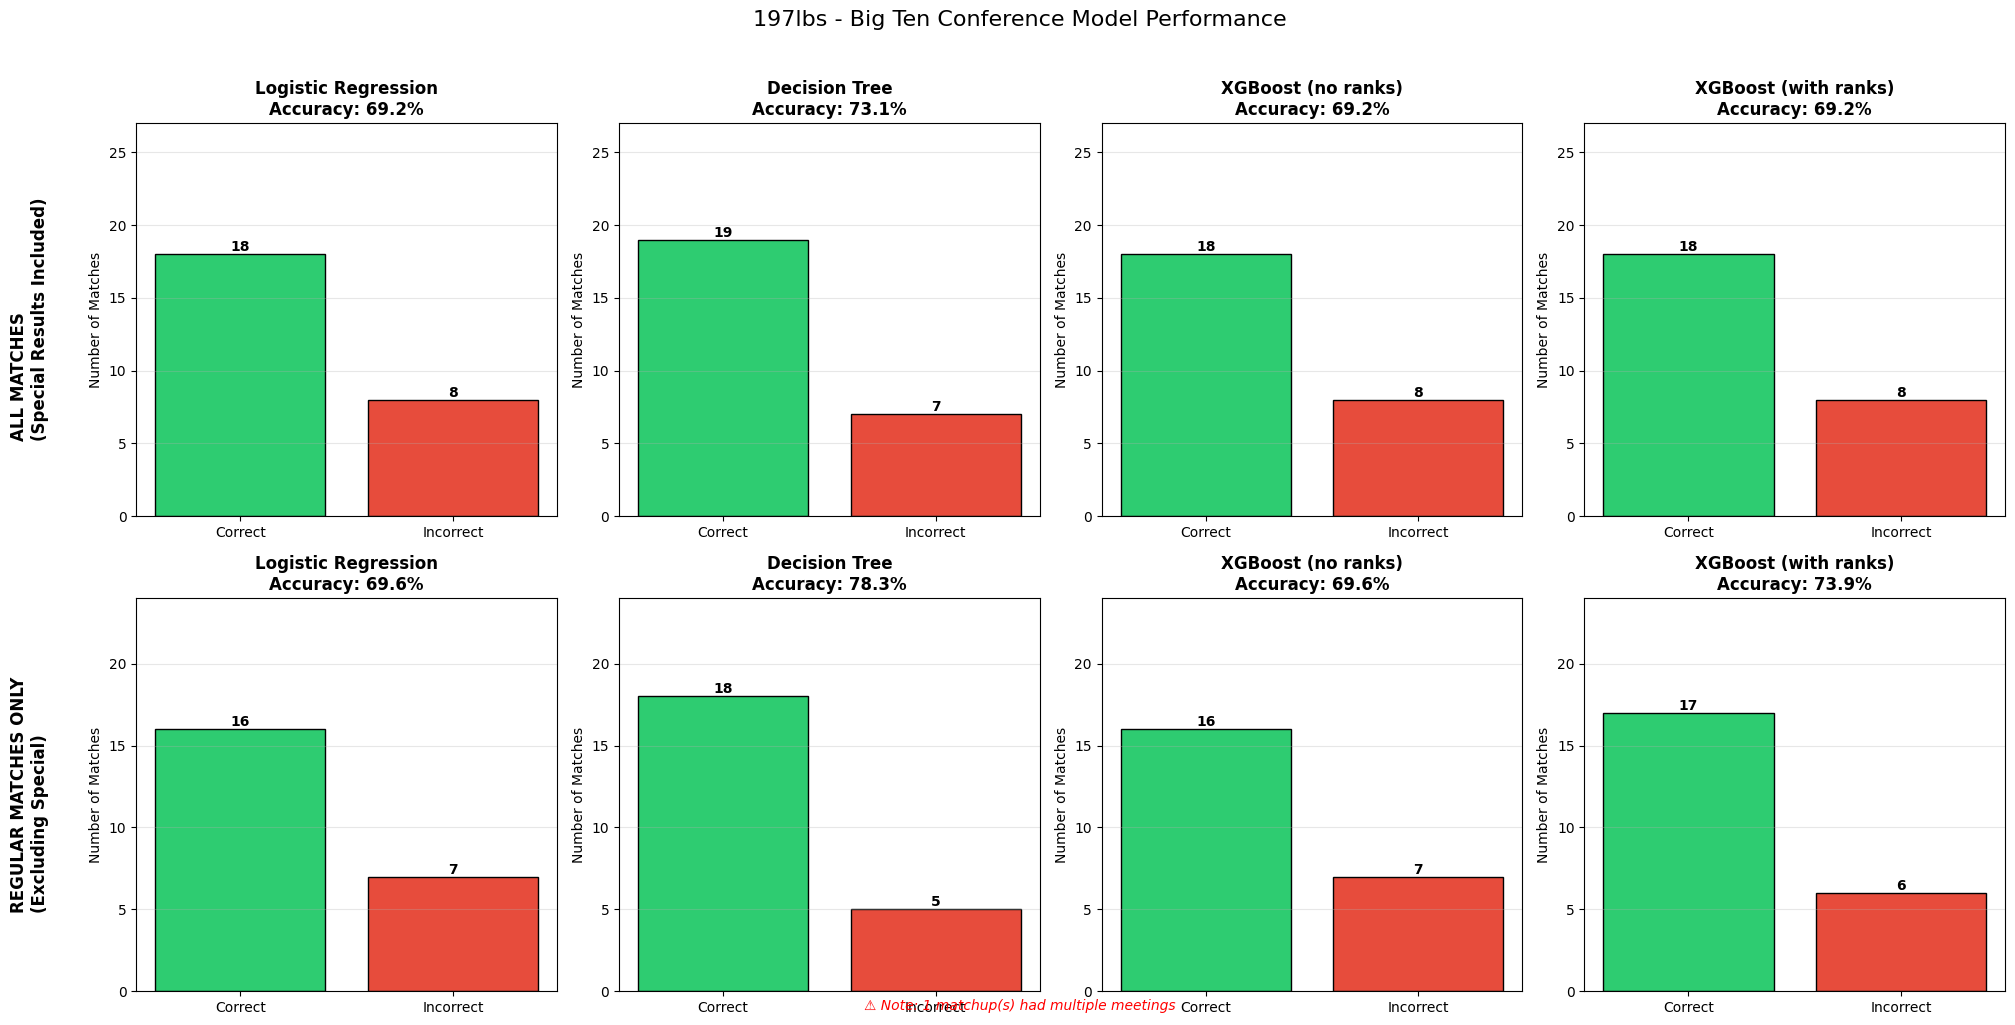


📊 MODEL RANKING - 197lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,Decision Tree,73.1%,19/26
1,Logistic Regression,69.2%,18/26
2,XGBoost (no ranks),69.2%,18/26
3,XGBoost (with ranks),69.2%,18/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,Decision Tree,78.3%,18/23
1,XGBoost (with ranks),73.9%,17/23
2,Logistic Regression,69.6%,16/23
3,XGBoost (no ranks),69.6%,16/23



📊 SUMMARY STATISTICS - 197lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,197lbs
2,Total Matches Evaluated,26
3,Unique Matchups,25
4,Matchups with Multiple Meetings,1
5,Matches with Special Results,3 (11.5%)
6,Regular Matches,23 (88.5%)
7,Best Model (All Matches),Decision Tree
8,Best Model Accuracy (All Matches),73.1%
9,Best Model (Regular Only),Decision Tree



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 197lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,69.2%,18/26,69.6%,16/23
1,Decision Tree,73.1%,19/26,78.3%,18/23
2,XGBoost (no ranks),69.2%,18/26,69.6%,16/23
3,XGBoost (with ranks),69.2%,18/26,73.9%,17/23



✅ Completed 197lbs evaluation. Total results stored: 8


In [127]:
# ============================================
# 197lbs BIG TEN RESULTS
# ============================================

# Define 197lbs wrestlers
wrestlers_197 = [
    'Josh Barr', 'Camden McDanel', 'Luke Geog', 'Wyatt Ingham',
    'Remy Cotton', 'Gabe Sollars', 'Branson John', 'Ben Vanadia',
    'Kael Wisler', 'Gabe Arnold', 'Gavin Nelson', 'Hayden Walters',
    'Dylan Connell', 'Alex Smith'
]

# Create 197lbs matches dictionary
matches_197 = {
    # Champ. Round 1
    ('Gabe Sollars', 'Ben Vanadia', 'Champ. Round 1'): 'Gabe Sollars (INJURY)',  # Injury default (0:04)
    ('Luke Geog', 'Dylan Connell', 'Champ. Round 1'): 'Luke Geog',  # MD 9-1
    ('Branson John', 'Gabe Arnold', 'Champ. Round 1'): 'Branson John',  # Dec 4-1
    ('Remy Cotton', 'Alex Smith', 'Champ. Round 1'): 'Remy Cotton',  # MD 15-2
    ('Wyatt Ingham', 'Gavin Nelson', 'Champ. Round 1'): 'Wyatt Ingham',  # Dec 5-1
    ('Kael Wisler', 'Hayden Walters', 'Champ. Round 1'): 'Kael Wisler',  # Dec 6-4

    # Quarterfinals
    ('Josh Barr', 'Gabe Sollars', 'Quarterfinal'): 'Josh Barr',  # TF-1.5 21-6
    ('Luke Geog', 'Branson John', 'Quarterfinal'): 'Luke Geog',  # Dec 9-4
    ('Wyatt Ingham', 'Remy Cotton', 'Quarterfinal'): 'Wyatt Ingham',  # MD 10-2
    ('Camden McDanel', 'Kael Wisler', 'Quarterfinal'): 'Camden McDanel',  # TF-1.5 18-2

    # Cons. Round 1
    ('Gabe Arnold', 'Dylan Connell', 'Cons. Round 1'): 'Gabe Arnold',  # Dec 5-1
    ('Gavin Nelson', 'Alex Smith', 'Cons. Round 1'): 'Gavin Nelson',  # Dec 4-3

    # Cons. Round 2
    ('Ben Vanadia', 'Kael Wisler', 'Cons. Round 2'): 'Ben Vanadia',  # Dec 7-2
    ('Remy Cotton', 'Gabe Arnold', 'Cons. Round 2'): 'Remy Cotton',  # SV-1 4-1
    ('Branson John', 'Gavin Nelson', 'Cons. Round 2'): 'Branson John',  # SV-1 8-5
    ('Gabe Sollars', 'Hayden Walters', 'Cons. Round 2'): 'Gabe Sollars',  # Dec 6-1

    # Cons. Round 3
    ('Remy Cotton', 'Ben Vanadia', 'Cons. Round 3'): 'Remy Cotton (MFFL)',  # Medical forfeit
    ('Gabe Sollars', 'Branson John', 'Cons. Round 3'): 'Gabe Sollars',  # Dec 2-1

    # Semifinals
    ('Josh Barr', 'Luke Geog', 'Semifinal'): 'Josh Barr',  # TF-1.5 18-3
    ('Camden McDanel', 'Wyatt Ingham', 'Semifinal'): 'Camden McDanel',  # Dec 10-3

    # Consolation Semis
    ('Luke Geog', 'Remy Cotton', 'Cons. Semi'): 'Luke Geog',  # MD 10-0
    ('Gabe Sollars', 'Wyatt Ingham', 'Cons. Semi'): 'Gabe Sollars',  # Dec 8-1

    # 7th Place Match
    ('Branson John', 'Ben Vanadia', '7th Place'): 'Branson John (MFFL)',  # Medical forfeit

    # 5th Place Match
    ('Wyatt Ingham', 'Remy Cotton', '5th Place'): 'Wyatt Ingham',  # Fall 4:11

    # 3rd Place Match
    ('Luke Geog', 'Gabe Sollars', '3rd Place'): 'Luke Geog',  # Dec 7-5

    # Championship
    ('Josh Barr', 'Camden McDanel', 'Championship'): 'Josh Barr',  # TF-1.5 19-4
}

# Track special matches (injury, forfeit, DQ)
special_matches_197 = [
    ('Gabe Sollars', 'Ben Vanadia', 'Champ. Round 1'),  # Injury default (0:04!)
    ('Remy Cotton', 'Ben Vanadia', 'Cons. Round 3'),    # Medical forfeit
    ('Branson John', 'Ben Vanadia', '7th Place'),       # Medical forfeit
]

# Setup 197lbs results
actual_results_197, special_matches_197, actual_matches_df_197 = setup_weight_class_results(
    weight_class=197,
    matches_dict=matches_197,
    conference="Big Ten"
)

# Get filtered predictions for 197lbs
weight_preds_197 = get_weight_predictions(big_ten_preds, 197, wrestlers_197)

# ============================================
# EVALUATE 197lbs
# ============================================

eval_197, summary_197 = evaluate_and_store_weight_class(
    weight_class=197,
    actual_results=actual_results_197,
    special_matches=special_matches_197,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 197lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")


📋 SETTING UP 285lbs Big Ten TOURNAMENT RESULTS

📊 285lbs Results Summary:
   Total matches: 26
   Special matches: 1


,Round,Wrestler 1,Wrestler 2,Winner,Type
0,Champ. Round 1,Hunter Catka,Josh Terrill,Hunter Catka,REGULAR
1,Champ. Round 1,Braxton Amos,Joey Schneck,Braxton Amos,REGULAR
2,Champ. Round 1,Cole Mirasola,Gabe Christenson,Cole Mirasola,REGULAR
3,Champ. Round 1,Nick Feldman,Caleb Marzolino,Nick Feldman,REGULAR
4,Champ. Round 1,Luke Luffman,Hayden Filipovich,Luke Luffman,REGULAR
5,Champ. Round 1,Ben Kueter,Koy Hopke,Ben Kueter,REGULAR
6,Quarterfinal,Taye Ghadiali,Hunter Catka,Taye Ghadiali,REGULAR
7,Quarterfinal,Cole Mirasola,Braxton Amos,Cole Mirasola,REGULAR
8,Quarterfinal,Nick Feldman,Luke Luffman,Nick Feldman,REGULAR
9,Quarterfinal,AJ Ferrari,Ben Kueter,AJ Ferrari,REGULAR



⚠️ Multiple meetings detected:
   Braxton Amos vs Cole Mirasola: 2 matches
      Rounds:
        - Quarterfinal: Cole Mirasola
        - 5th Place: Cole Mirasola (MFFL) (SPECIAL)

📊 285lbs: 91/91 matchups involve tournament wrestlers
   Total possible matchups: 91

🏋️  EVALUATING 285lbs - Big Ten CONFERENCE

📊 285lbs predictions in dataset: 91 matchups

⚠️  MULTIPLE MATCHES DETECTED BETWEEN SAME WRESTLERS
   Cole Mirasola vs Braxton Amos: 2 matches
      - Quarterfinal: Cole Mirasola wins
      - 5th Place: Cole Mirasola wins

📊 DETAILED EVALUATION - 285lbs ALL MATCHES


,Round,Wrestler 1,Wrestler 2,Match Number,Actual Winner,LR Correct,LR Conf,DT Correct,DT Conf,XGB1 Correct,XGB1 Conf,XGB2 Correct,XGB2 Conf
0,Champ. Round 1,Hunter Catka,Josh Terrill,1 of 1,Hunter Catka,✅,50.2%,✅,61.1%,✅,76.4%,✅,93.0%
1,Champ. Round 1,Braxton Amos,Joey Schneck,1 of 1,Braxton Amos,✅,76.5%,✅,74.6%,✅,87.4%,✅,97.1%
2,Champ. Round 1,Cole Mirasola,Gabe Christenson,1 of 1,Cole Mirasola,✅,76.3%,✅,89.0%,✅,86.3%,✅,95.2%
3,Champ. Round 1,Nick Feldman,Caleb Marzolino,1 of 1,Nick Feldman,✅,84.2%,✅,89.0%,✅,91.8%,✅,97.9%
4,Champ. Round 1,Luke Luffman,Hayden Filipovich,1 of 1,Luke Luffman,✅,66.0%,✅,74.6%,✅,76.7%,✅,89.7%
5,Champ. Round 1,Ben Kueter,Koy Hopke,1 of 1,Ben Kueter,❌,53.6%,❌,74.7%,❌,64.8%,✅,52.5%
6,Quarterfinal,Taye Ghadiali,Hunter Catka,1 of 1,Taye Ghadiali,✅,66.4%,✅,74.6%,✅,71.5%,✅,82.0%
7,Quarterfinal,Cole Mirasola,Braxton Amos,1 of 1,Cole Mirasola,❌,54.7%,❌,53.1%,❌,60.0%,✅,73.0%
8,Quarterfinal,Nick Feldman,Luke Luffman,1 of 1,Nick Feldman,❌,51.6%,✅,61.1%,✅,63.1%,✅,84.4%
9,Quarterfinal,AJ Ferrari,Ben Kueter,1 of 1,AJ Ferrari,✅,69.2%,✅,74.6%,✅,84.4%,✅,89.0%



📊 MODEL ACCURACY METRICS - 285lbs

🔴 INCLUDING ALL MATCHES (Special Results Included):


,Model,Correct,Accuracy
0,Logistic Regression,14/26,53.8%
1,Decision Tree,17/26,65.4%
2,XGBoost (no ranks),17/26,65.4%
3,XGBoost (with ranks),20/26,76.9%



🟢 REGULAR MATCHES ONLY (Excluding Special Results):


,Model,Correct,Accuracy
0,Logistic Regression,14/25,56.0%
1,Decision Tree,17/25,68.0%
2,XGBoost (no ranks),17/25,68.0%
3,XGBoost (with ranks),19/25,76.0%


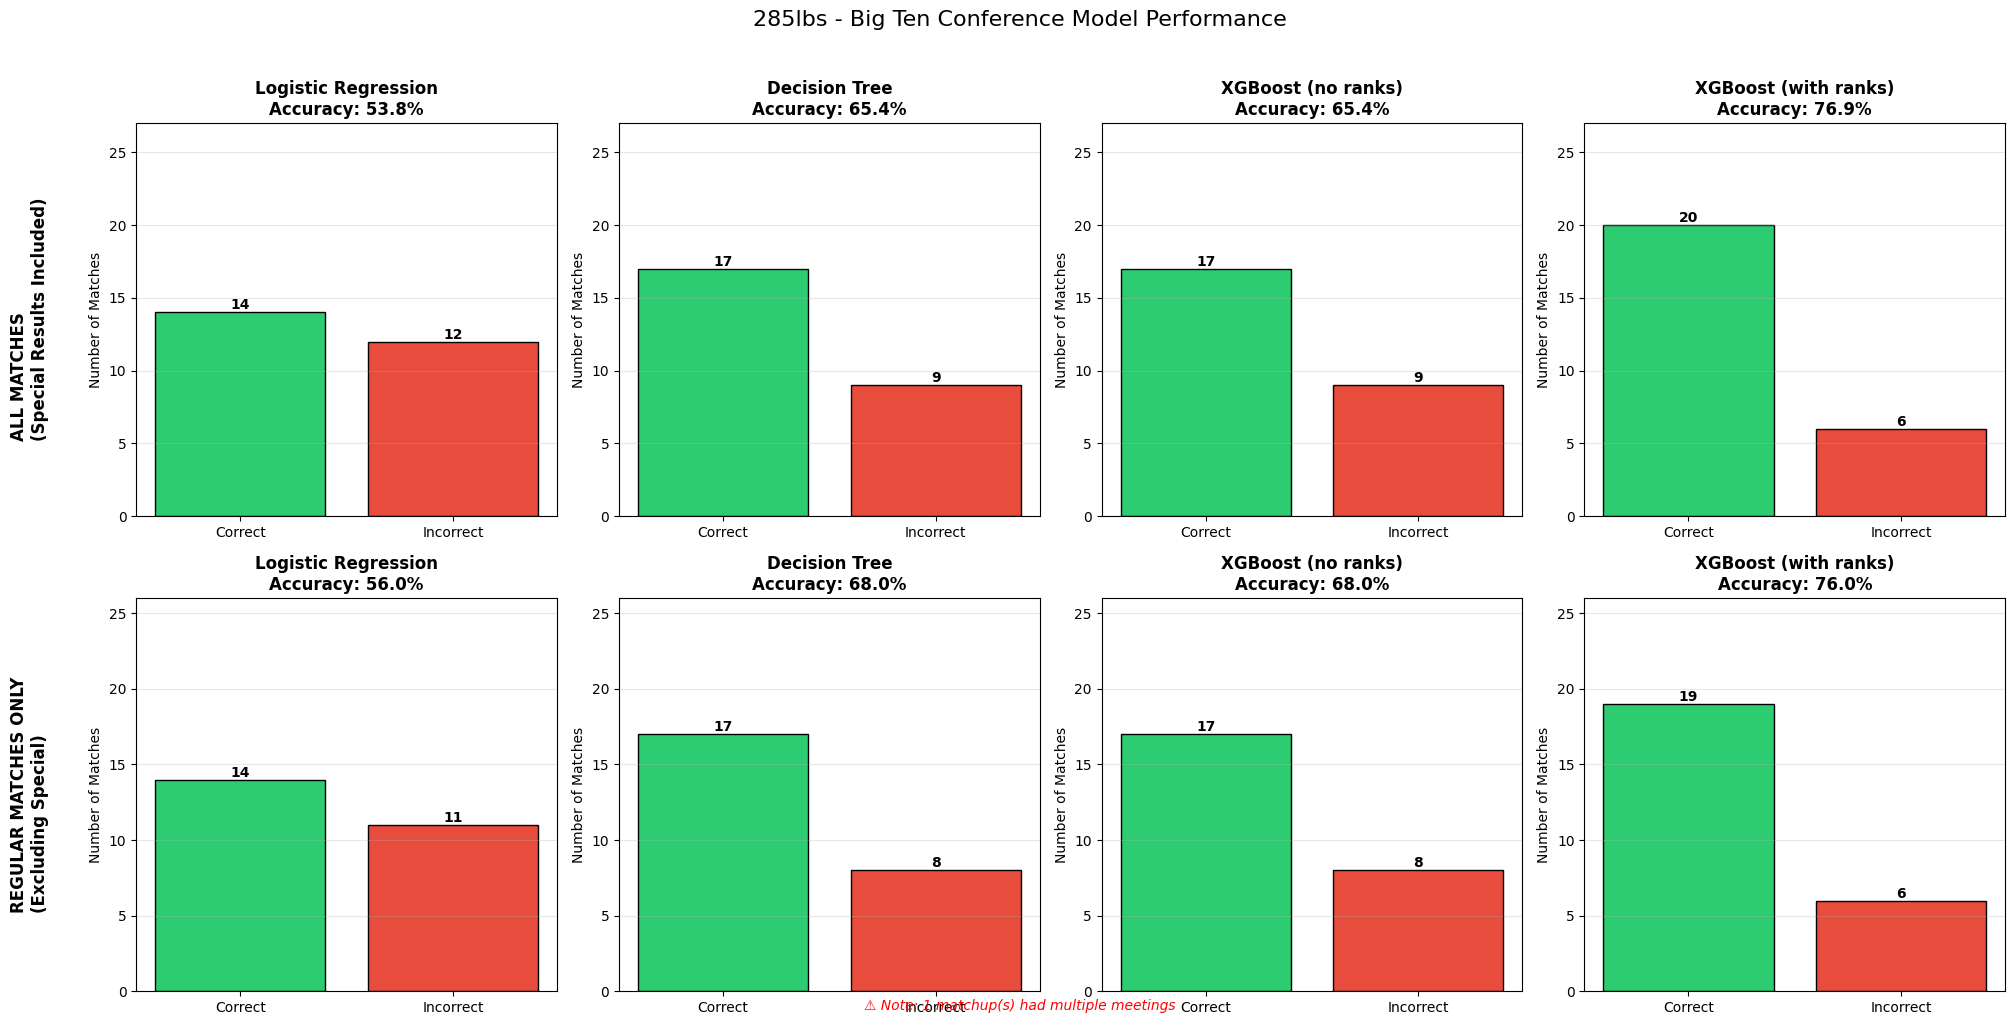


📊 MODEL RANKING - 285lbs

🏆 Model Ranking (All Matches - Special Results Included):


,Model,Accuracy,Correct
0,XGBoost (with ranks),76.9%,20/26
1,Decision Tree,65.4%,17/26
2,XGBoost (no ranks),65.4%,17/26
3,Logistic Regression,53.8%,14/26



🏆 Model Ranking (Regular Matches Only - Excluding Special Results):


,Model,Accuracy,Correct
0,XGBoost (with ranks),76.0%,19/25
1,Decision Tree,68.0%,17/25
2,XGBoost (no ranks),68.0%,17/25
3,Logistic Regression,56.0%,14/25



📊 SUMMARY STATISTICS - 285lbs


,Metric,Value
0,Conference,Big Ten
1,Weight Class,285lbs
2,Total Matches Evaluated,26
3,Unique Matchups,25
4,Matchups with Multiple Meetings,1
5,Matches with Special Results,1 (3.8%)
6,Regular Matches,25 (96.2%)
7,Best Model (All Matches),XGBoost (with ranks)
8,Best Model Accuracy (All Matches),76.9%
9,Best Model (Regular Only),XGBoost (with ranks)



📊 COMPLETE MODEL PERFORMANCE SUMMARY - 285lbs


,Model,All Matches Accuracy,All Matches Correct,Regular Only Accuracy,Regular Only Correct
0,Logistic Regression,53.8%,14/26,56.0%,14/25
1,Decision Tree,65.4%,17/26,68.0%,17/25
2,XGBoost (no ranks),65.4%,17/26,68.0%,17/25
3,XGBoost (with ranks),76.9%,20/26,76.0%,19/25



✅ Completed 285lbs evaluation. Total results stored: 9


In [128]:
# ============================================
# 285lbs BIG TEN RESULTS
# ============================================

# Define 285lbs wrestlers
wrestlers_285 = [
    'Taye Ghadiali', 'AJ Ferrari', 'Nick Feldman', 'Ben Kueter',
    'Cole Mirasola', 'Braxton Amos', 'Koy Hopke', 'Luke Luffman',
    'Hunter Catka', 'Josh Terrill', 'Gabe Christenson', 'Caleb Marzolino',
    'Hayden Filipovich', 'Joey Schneck'
]

# Create 285lbs matches dictionary
matches_285 = {
    # Champ. Round 1
    ('Hunter Catka', 'Josh Terrill', 'Champ. Round 1'): 'Hunter Catka',  # Dec 4-2
    ('Braxton Amos', 'Joey Schneck', 'Champ. Round 1'): 'Braxton Amos',  # TF-1.5 19-3
    ('Cole Mirasola', 'Gabe Christenson', 'Champ. Round 1'): 'Cole Mirasola',  # Fall 0:26
    ('Nick Feldman', 'Caleb Marzolino', 'Champ. Round 1'): 'Nick Feldman',  # TF-1.5 21-6
    ('Luke Luffman', 'Hayden Filipovich', 'Champ. Round 1'): 'Luke Luffman',  # Dec 5-1
    ('Ben Kueter', 'Koy Hopke', 'Champ. Round 1'): 'Ben Kueter',  # Dec 5-2

    # Quarterfinals
    ('Taye Ghadiali', 'Hunter Catka', 'Quarterfinal'): 'Taye Ghadiali',  # Fall 5:29
    ('Cole Mirasola', 'Braxton Amos', 'Quarterfinal'): 'Cole Mirasola',  # Dec 4-2
    ('Nick Feldman', 'Luke Luffman', 'Quarterfinal'): 'Nick Feldman',  # Dec 5-2
    ('AJ Ferrari', 'Ben Kueter', 'Quarterfinal'): 'AJ Ferrari',  # Dec 5-1

    # Cons. Round 1
    ('Gabe Christenson', 'Joey Schneck', 'Cons. Round 1'): 'Gabe Christenson',  # Dec 7-2
    ('Caleb Marzolino', 'Hayden Filipovich', 'Cons. Round 1'): 'Caleb Marzolino',  # Fall 0:29

    # Cons. Round 2
    ('Ben Kueter', 'Josh Terrill', 'Cons. Round 2'): 'Ben Kueter',  # SV-1 4-1
    ('Luke Luffman', 'Gabe Christenson', 'Cons. Round 2'): 'Luke Luffman',  # MD 14-2
    ('Braxton Amos', 'Caleb Marzolino', 'Cons. Round 2'): 'Braxton Amos',  # Fall 2:46
    ('Koy Hopke', 'Hunter Catka', 'Cons. Round 2'): 'Koy Hopke',  # Dec 2-0

    # Cons. Round 3
    ('Ben Kueter', 'Luke Luffman', 'Cons. Round 3'): 'Ben Kueter',  # Dec 4-1
    ('Braxton Amos', 'Koy Hopke', 'Cons. Round 3'): 'Braxton Amos',  # Dec 8-3

    # Semifinals
    ('Taye Ghadiali', 'Cole Mirasola', 'Semifinal'): 'Taye Ghadiali',  # Dec 5-2
    ('AJ Ferrari', 'Nick Feldman', 'Semifinal'): 'AJ Ferrari',  # Dec 2-1

    # Consolation Semis
    ('Ben Kueter', 'Cole Mirasola', 'Cons. Semi'): 'Ben Kueter',  # Dec 2-0
    ('Nick Feldman', 'Braxton Amos', 'Cons. Semi'): 'Nick Feldman',  # Dec 4-1

    # 7th Place Match
    ('Koy Hopke', 'Luke Luffman', '7th Place'): 'Koy Hopke',  # Dec 4-2

    # 5th Place Match
    ('Cole Mirasola', 'Braxton Amos', '5th Place'): 'Cole Mirasola (MFFL)',  # Medical forfeit

    # 3rd Place Match
    ('Nick Feldman', 'Ben Kueter', '3rd Place'): 'Nick Feldman',  # Dec 6-2

    # Championship
    ('Taye Ghadiali', 'AJ Ferrari', 'Championship'): 'Taye Ghadiali',  # Dec 5-2
}

# Track special matches (injury, forfeit, DQ)
special_matches_285 = [
    ('Cole Mirasola', 'Braxton Amos', '5th Place'),  # Medical forfeit
]

# Setup 285lbs results
actual_results_285, special_matches_285, actual_matches_df_285 = setup_weight_class_results(
    weight_class=285,
    matches_dict=matches_285,
    conference="Big Ten"
)

# Get filtered predictions for 285lbs
weight_preds_285 = get_weight_predictions(big_ten_preds, 285, wrestlers_285)

# ============================================
# EVALUATE 285lbs
# ============================================

eval_285, summary_285 = evaluate_and_store_weight_class(
    weight_class=285,
    actual_results=actual_results_285,
    special_matches=special_matches_285,
    predictions_df=big_ten_preds,
    conference="Big Ten",
    results_list=all_weight_results_big_ten,
    eval_function=evaluate_weight_class,
    save_plots=False
)

print(f"\n✅ Completed 285lbs evaluation. Total results stored: {len(all_weight_results_big_ten)}")

# Overall stats


📋 BIG TEN CHAMPION PREDICTION RESULTS

🏆 BIG TEN - CHAMPION PREDICTION ACCURACY BY WEIGHT CLASS


,Weight,Actual Champion,LOGREG,DT,XGB1,XGB2,Consensus,Correct
0,125 lbs,Luke Lilledahl (Penn State),Luke Lilledahl,Luke Lilledahl,Luke Lilledahl,Luke Lilledahl,Unanimous,✅
1,133 lbs,Ben Davino (Ohio State),Marcus Blaze,Marcus Blaze,Marcus Blaze,Marcus Blaze,Unanimous,❌
2,141 lbs,Jesse Mendez (Ohio State),Jesse Mendez,Jesse Mendez,Jesse Mendez,Jesse Mendez,Unanimous,✅
3,149 lbs,Shayne Van Ness (Penn State),Shayne Van Ness,Shayne Van Ness,Shayne Van Ness,Shayne Van Ness,Unanimous,✅
4,157 lbs,PJ Duke (Penn State),Brandon Cannon,Brandon Cannon,Brandon Cannon,Brandon Cannon,Unanimous,❌
5,165 lbs,Mitchell Mesenbrink (Penn State),Mitchell Mesenbrink,Mitchell Mesenbrink,Mitchell Mesenbrink,Mitchell Mesenbrink,Unanimous,✅
6,174 lbs,Levi Haines (Penn State),Levi Haines,Levi Haines,Levi Haines,Levi Haines,Unanimous,✅
7,184 lbs,Rocco Welsh (Penn State),Rocco Welsh,Max McEnelly,Rocco Welsh,Rocco Welsh,3/4 Models,✅
8,197 lbs,Josh Barr (Penn State),Josh Barr,Josh Barr,Josh Barr,Josh Barr,Unanimous,✅
9,285 lbs,Taye Ghadiali (Michigan),Taye Ghadiali,Taye Ghadiali,Taye Ghadiali,AJ Ferrari,3/4 Models,✅



📊 BIG TEN - MODEL CHAMPION PREDICTION ACCURACY


,Model,Correct Champions,Accuracy
0,LOGREG,8/10,80.0%
1,DT,7/10,70.0%
2,XGB1,8/10,80.0%
3,XGB2,7/10,70.0%



📊 Overall Champion Prediction Accuracy: 8/10 (80.0%)

📊 BIG TEN - CONSENSUS BREAKDOWN


...

,Model,Correct,Accuracy
3,XGBoost (with ranks),198/260,76.1
2,XGBoost (no ranks),188/260,72.3
1,Logistic Regression,184/260,70.8
0,Decision Tree,184/260,70.8



🟢 REGULAR MATCHES ONLY (Excluding Special):


,Model,Correct,Accuracy
3,XGBoost (with ranks),186/240,77.4
2,XGBoost (no ranks),177/240,73.7
0,Decision Tree,175/240,72.8
1,Logistic Regression,173/240,72.1



📊 BIG TEN - SPECIAL MATCHES BY WEIGHT CLASS


,Weight,Total,Special,Regular,Special %
0,125 lbs,26,0,26,0.0%
1,133 lbs,26,2,24,7.7%
2,141 lbs,26,0,26,0.0%
3,149 lbs,26,1,25,3.8%
4,157 lbs,26,4,22,15.4%
5,165 lbs,26,2,24,7.7%
6,174 lbs,26,2,24,7.7%
7,184 lbs,26,5,21,19.2%
8,197 lbs,26,3,23,11.5%
9,285 lbs,26,1,25,3.8%


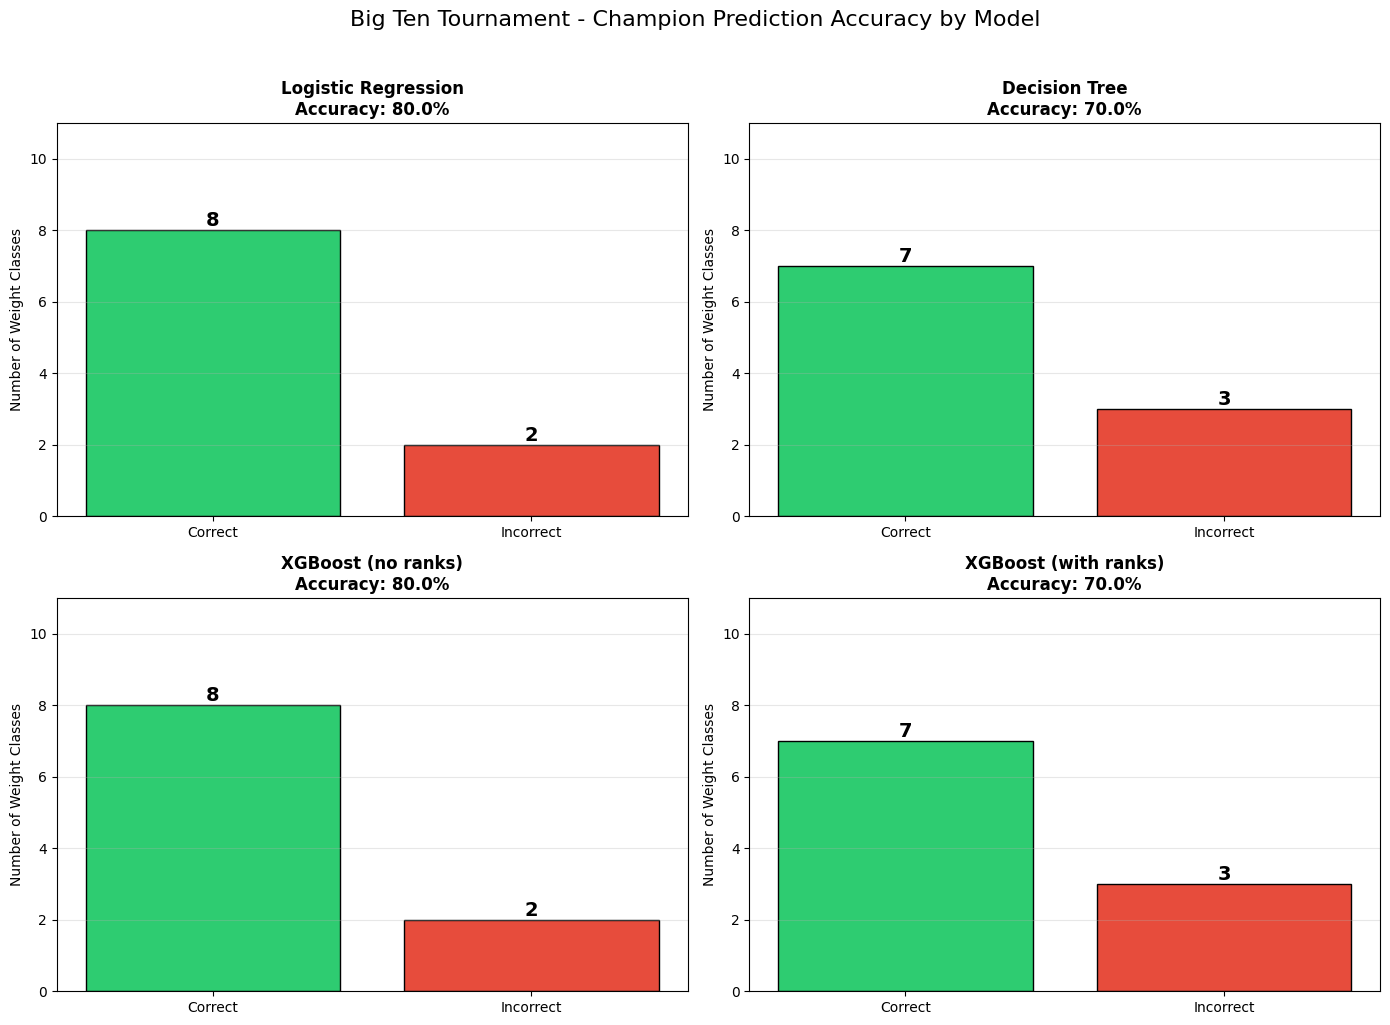

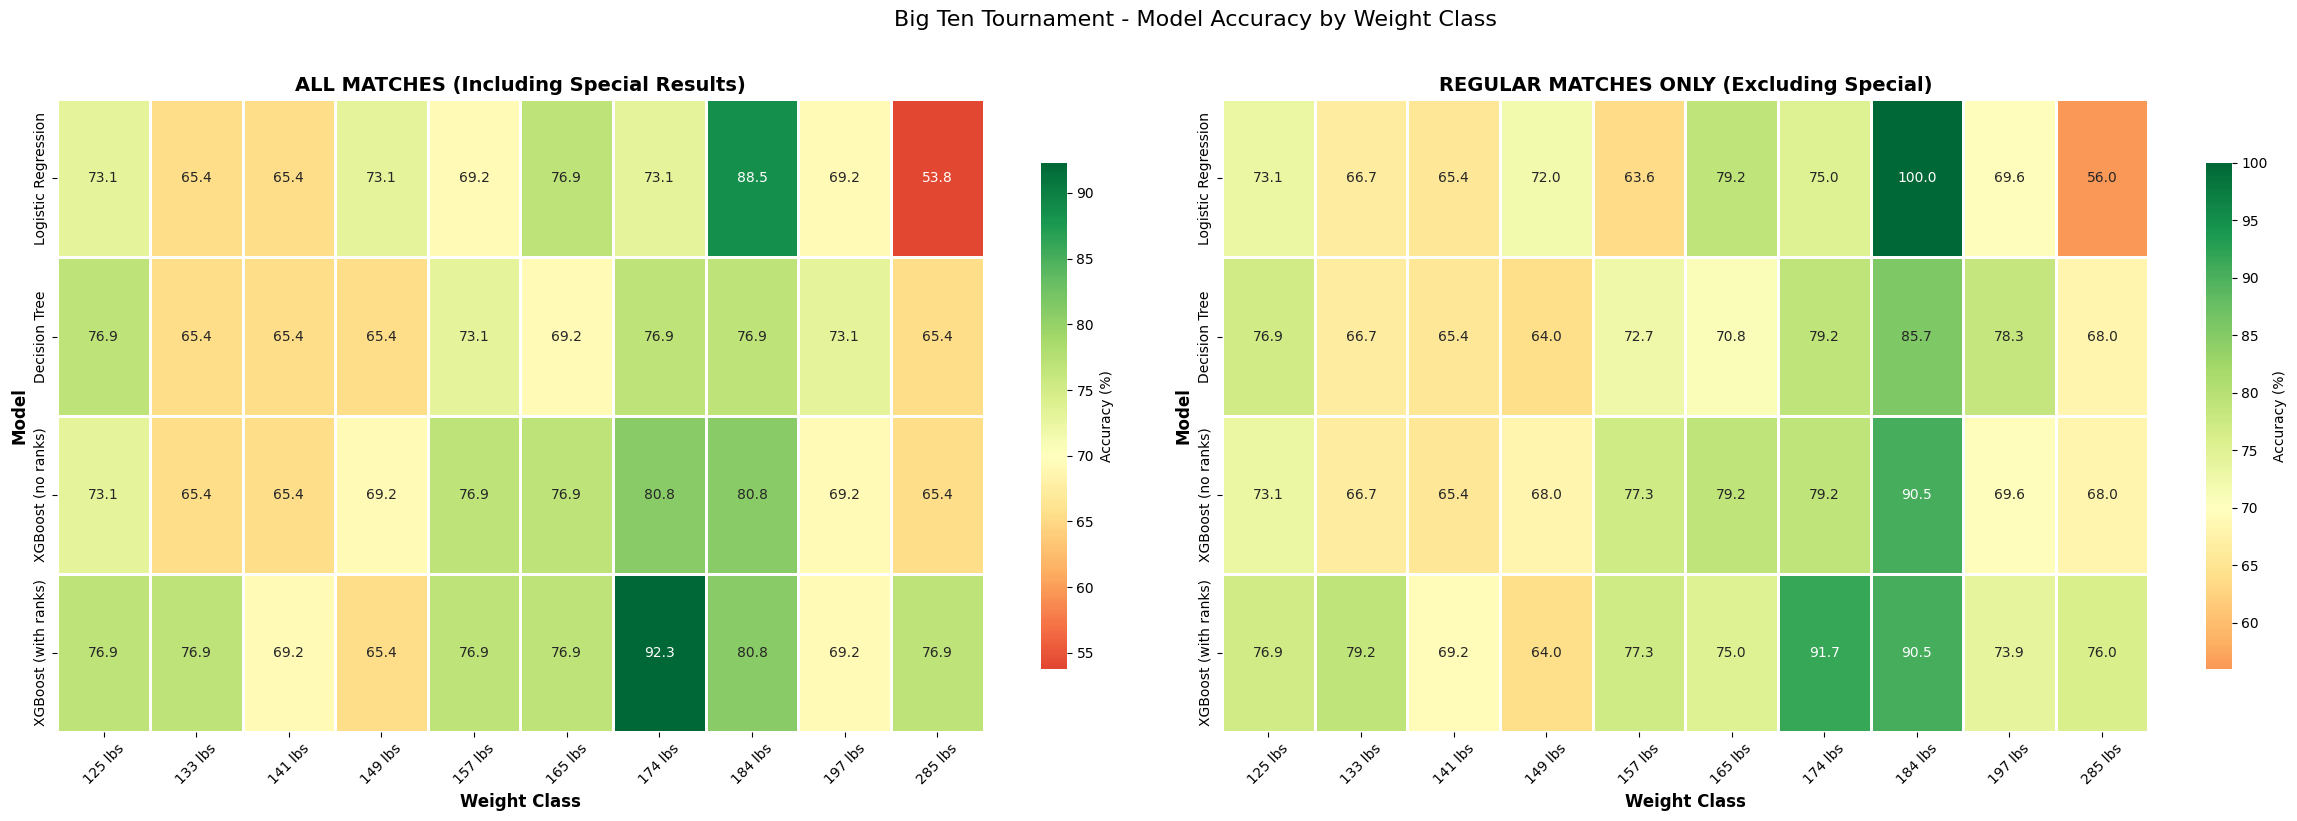

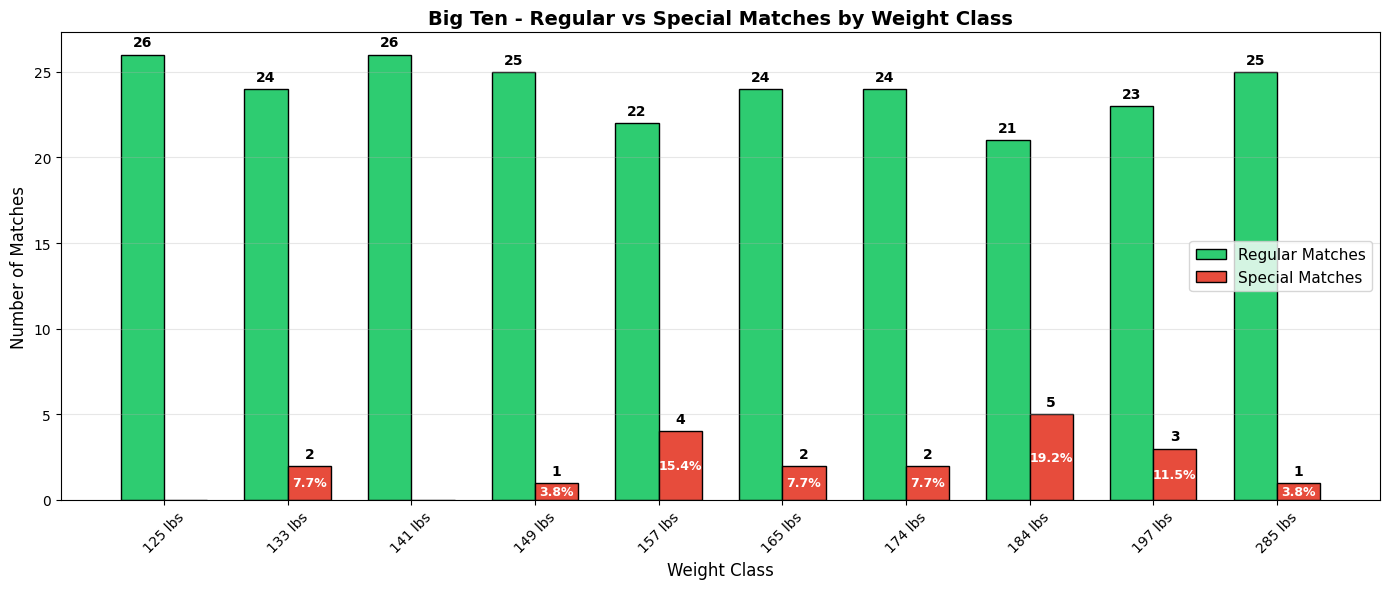

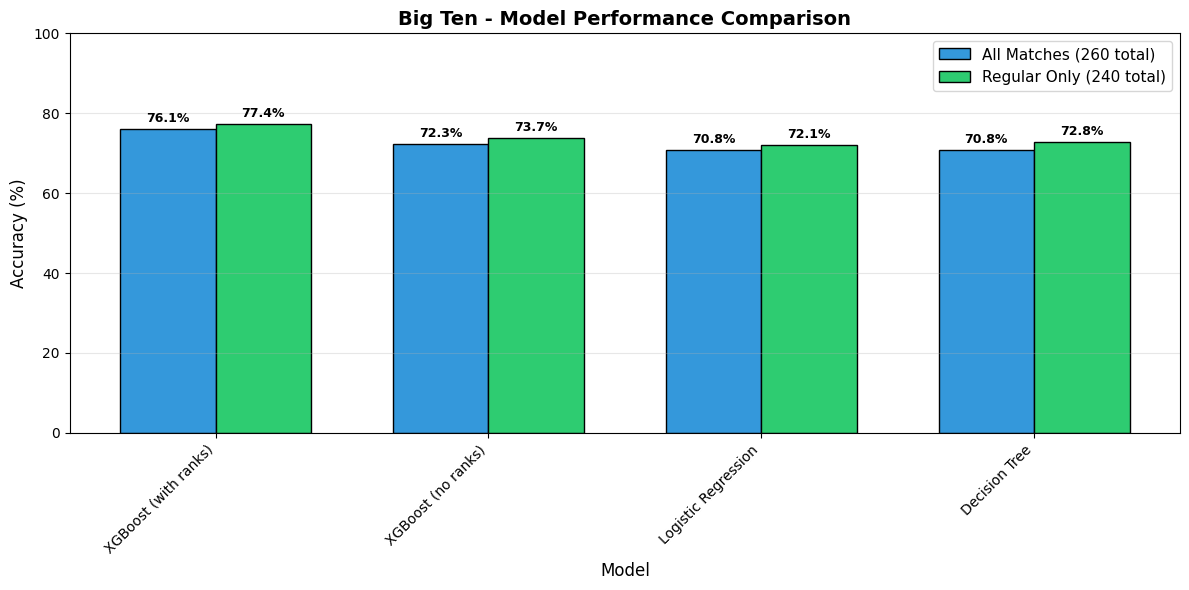


📊 BIG TEN - SUMMARY STATISTICS


,Metric,Value
0,Total Weight Classes,10
1,Total Tournament Matches,260
2,Regular Matches,240
3,Special Matches,20
4,Champion Prediction Accuracy,8/10 (80.0%)
5,Best Model (All Matches),XGBoost (with ranks) - 76.1%
6,Best Model (Regular Only),XGBoost (with ranks) - 77.4%



✅ BIG TEN ANALYSIS COMPLETE


In [130]:
# ============================================
# BIG TEN - COMPLETE OVERALL ANALYSIS (BASED ON ACTUAL DATA)
# ============================================

print("\n" + "="*100)
print("📋 BIG TEN CHAMPION PREDICTION RESULTS")
print("="*100)

# ============================================
# CHAMPION PREDICTION DATA
# ============================================

# Actual champions from Big Ten tournament results
actual_champions = {
    125: {'name': 'Luke Lilledahl', 'team': 'Penn State'},
    133: {'name': 'Ben Davino', 'team': 'Ohio State'},
    141: {'name': 'Jesse Mendez', 'team': 'Ohio State'},
    149: {'name': 'Shayne Van Ness', 'team': 'Penn State'},
    157: {'name': 'PJ Duke', 'team': 'Penn State'},
    165: {'name': 'Mitchell Mesenbrink', 'team': 'Penn State'},
    174: {'name': 'Levi Haines', 'team': 'Penn State'},
    184: {'name': 'Rocco Welsh', 'team': 'Penn State'},
    197: {'name': 'Josh Barr', 'team': 'Penn State'},
    285: {'name': 'Taye Ghadiali', 'team': 'Michigan'},
}

# Model predicted champions from your output summaries
predicted_champions = {
    125: {
        'LOGREG': 'Luke Lilledahl', 'DT': 'Luke Lilledahl',
        'XGB1': 'Luke Lilledahl', 'XGB2': 'Luke Lilledahl',
        'consensus': 'Unanimous', 'correct': True
    },
    133: {
        'LOGREG': 'Marcus Blaze', 'DT': 'Marcus Blaze',
        'XGB1': 'Marcus Blaze', 'XGB2': 'Marcus Blaze',
        'consensus': 'Unanimous', 'correct': False
    },
    141: {
        'LOGREG': 'Jesse Mendez', 'DT': 'Jesse Mendez',
        'XGB1': 'Jesse Mendez', 'XGB2': 'Jesse Mendez',
        'consensus': 'Unanimous', 'correct': True
    },
    149: {
        'LOGREG': 'Shayne Van Ness', 'DT': 'Shayne Van Ness',
        'XGB1': 'Shayne Van Ness', 'XGB2': 'Shayne Van Ness',
        'consensus': 'Unanimous', 'correct': True
    },
    157: {
        'LOGREG': 'Brandon Cannon', 'DT': 'Brandon Cannon',
        'XGB1': 'Brandon Cannon', 'XGB2': 'Brandon Cannon',
        'consensus': 'Unanimous', 'correct': False
    },
    165: {
        'LOGREG': 'Mitchell Mesenbrink', 'DT': 'Mitchell Mesenbrink',
        'XGB1': 'Mitchell Mesenbrink', 'XGB2': 'Mitchell Mesenbrink',
        'consensus': 'Unanimous', 'correct': True
    },
    174: {
        'LOGREG': 'Levi Haines', 'DT': 'Levi Haines',
        'XGB1': 'Levi Haines', 'XGB2': 'Levi Haines',
        'consensus': 'Unanimous', 'correct': True
    },
    184: {
        'LOGREG': 'Rocco Welsh', 'DT': 'Max McEnelly',
        'XGB1': 'Rocco Welsh', 'XGB2': 'Rocco Welsh',
        'consensus': '3/4 Models', 'correct': True
    },
    197: {
        'LOGREG': 'Josh Barr', 'DT': 'Josh Barr',
        'XGB1': 'Josh Barr', 'XGB2': 'Josh Barr',
        'consensus': 'Unanimous', 'correct': True
    },
    285: {
        'LOGREG': 'Taye Ghadiali', 'DT': 'Taye Ghadiali',
        'XGB1': 'Taye Ghadiali', 'XGB2': 'AJ Ferrari',
        'consensus': '3/4 Models', 'correct': True
    },
}

weight_order = [125, 133, 141, 149, 157, 165, 174, 184, 197, 285]

# ============================================
# CHAMPION PREDICTION SUMMARY
# ============================================

champion_summary = []
for weight in weight_order:
    p = predicted_champions[weight]
    actual = actual_champions[weight]

    champion_summary.append({
        'Weight': f'{weight} lbs',
        'Actual Champion': f"{actual['name']} ({actual['team']})",
        'LOGREG': p['LOGREG'],
        'DT': p['DT'],
        'XGB1': p['XGB1'],
        'XGB2': p['XGB2'],
        'Consensus': p['consensus'],
        'Correct': '✅' if p['correct'] else '❌'
    })

champion_df = pd.DataFrame(champion_summary)
print("\n🏆 BIG TEN - CHAMPION PREDICTION ACCURACY BY WEIGHT CLASS")
print("="*100)
display(champion_df)

# ============================================
# MODEL CHAMPION ACCURACY
# ============================================

model_accuracy = []
for model in ['LOGREG', 'DT', 'XGB1', 'XGB2']:
    correct = sum(1 for w in weight_order
                 if predicted_champions[w][model] == actual_champions[w]['name'])
    model_accuracy.append({
        'Model': model,
        'Correct Champions': f"{correct}/10",
        'Accuracy': f"{(correct/10*100):.1f}%"
    })

model_acc_df = pd.DataFrame(model_accuracy)
print("\n📊 BIG TEN - MODEL CHAMPION PREDICTION ACCURACY")
print("="*100)
display(model_acc_df)

# Overall champion accuracy
total_correct = champion_df['Correct'].value_counts().get('✅', 0)
print(f"\n📊 Overall Champion Prediction Accuracy: {total_correct}/10 ({total_correct/10*100:.1f}%)")

# ============================================
# CONSENSUS BREAKDOWN
# ============================================

consensus_counts = {}
for p in predicted_champions.values():
    consensus_counts[p['consensus']] = consensus_counts.get(p['consensus'], 0) + 1

consensus_df = pd.DataFrame([
    {'Consensus Type': k, 'Count': v, 'Percentage': f"{(v/10*100):.1f}%"}
    for k, v in consensus_counts.items()
])
print("\n📊 BIG TEN - CONSENSUS BREAKDOWN")
print("="*100)
display(consensus_df)

# ============================================
# MATCH PREDICTION DATA - CORRECTED FROM YOUR DETAILED EVALUATIONS
# ============================================

print("\n" + "="*100)
print("📊 BIG TEN - MATCH PREDICTION EVALUATION SUMMARY")
print("="*100)

# Based on your detailed evaluation data for each weight class
# Format: [Weight, Logistic Regression, Decision Tree, XGBoost (no ranks), XGBoost (with ranks), Total Matches]
all_matches_accuracy = [
    # Weight, LR, DT, XGB1, XGB2, Total
    ('125 lbs', 73.1, 76.9, 73.1, 76.9, 26),
    ('133 lbs', 65.4, 65.4, 65.4, 76.9, 26),
    ('141 lbs', 65.4, 65.4, 65.4, 69.2, 26),
    ('149 lbs', 73.1, 65.4, 69.2, 65.4, 26),
    ('157 lbs', 69.2, 73.1, 76.9, 76.9, 26),
    ('165 lbs', 76.9, 69.2, 76.9, 76.9, 26),
    ('174 lbs', 73.1, 76.9, 80.8, 92.3, 26),
    ('184 lbs', 88.5, 76.9, 80.8, 80.8, 26),  # CORRECTED from your detailed eval
    ('197 lbs', 69.2, 73.1, 69.2, 69.2, 26),
    ('285 lbs', 53.8, 65.4, 65.4, 76.9, 26),
]

regular_matches_accuracy = [
    # Weight, LR, DT, XGB1, XGB2, Total Regular
    ('125 lbs', 73.1, 76.9, 73.1, 76.9, 26),
    ('133 lbs', 66.7, 66.7, 66.7, 79.2, 24),
    ('141 lbs', 65.4, 65.4, 65.4, 69.2, 26),
    ('149 lbs', 72.0, 64.0, 68.0, 64.0, 25),
    ('157 lbs', 63.6, 72.7, 77.3, 77.3, 22),
    ('165 lbs', 79.2, 70.8, 79.2, 75.0, 24),
    ('174 lbs', 75.0, 79.2, 79.2, 91.7, 24),
    ('184 lbs', 100.0, 85.7, 90.5, 90.5, 21),  # CORRECTED from your detailed eval
    ('197 lbs', 69.6, 78.3, 69.6, 73.9, 23),
    ('285 lbs', 56.0, 68.0, 68.0, 76.0, 25),
]

# Create DataFrames
all_matches_list = []
for weight, lr, dt, xgb1, xgb2, total in all_matches_accuracy:
    all_matches_list.append({'Weight': weight, 'Model': 'Logistic Regression', 'Accuracy': lr, 'Total': total})
    all_matches_list.append({'Weight': weight, 'Model': 'Decision Tree', 'Accuracy': dt, 'Total': total})
    all_matches_list.append({'Weight': weight, 'Model': 'XGBoost (no ranks)', 'Accuracy': xgb1, 'Total': total})
    all_matches_list.append({'Weight': weight, 'Model': 'XGBoost (with ranks)', 'Accuracy': xgb2, 'Total': total})

regular_matches_list = []
for weight, lr, dt, xgb1, xgb2, total in regular_matches_accuracy:
    regular_matches_list.append({'Weight': weight, 'Model': 'Logistic Regression', 'Accuracy': lr, 'Total': total})
    regular_matches_list.append({'Weight': weight, 'Model': 'Decision Tree', 'Accuracy': dt, 'Total': total})
    regular_matches_list.append({'Weight': weight, 'Model': 'XGBoost (no ranks)', 'Accuracy': xgb1, 'Total': total})
    regular_matches_list.append({'Weight': weight, 'Model': 'XGBoost (with ranks)', 'Accuracy': xgb2, 'Total': total})

all_matches_df = pd.DataFrame(all_matches_list)
regular_matches_df = pd.DataFrame(regular_matches_list)

# Display summary tables
print("\n📋 ALL MATCHES BY WEIGHT CLASS (Including Special Results):")
all_pivot = all_matches_df.pivot_table(
    index='Weight', columns='Model', values='Accuracy', aggfunc='first'
).round(1)
display(all_pivot)

print("\n📋 REGULAR MATCHES ONLY BY WEIGHT CLASS (Excluding Special Results):")
regular_pivot = regular_matches_df.pivot_table(
    index='Weight', columns='Model', values='Accuracy', aggfunc='first'
).round(1)
display(regular_pivot)

# ============================================
# OVERALL MATCH STATISTICS
# ============================================

print("\n" + "="*100)
print("📊 BIG TEN - OVERALL MATCH PREDICTION STATISTICS")
print("="*100)

# Calculate total matches
total_matches = sum([row[5] for row in all_matches_accuracy])
regular_total = sum([row[5] for row in regular_matches_accuracy])
special_total = total_matches - regular_total

print(f"Total matches: {total_matches}")
print(f"Regular matches: {regular_total}")
print(f"Special matches: {special_total}\n")

# All matches overall
all_overall = all_matches_df.groupby('Model').agg({
    'Accuracy': 'mean'
}).round(1).reset_index()
all_overall = all_overall.sort_values('Accuracy', ascending=False)

# Calculate correct counts based on percentages
total_per_model = total_matches * len(all_matches_df['Model'].unique())
all_overall['Correct'] = (all_overall['Accuracy'] / 100 * total_matches).round(0).astype(int)
all_overall['Correct'] = all_overall['Correct'].astype(str) + '/' + str(total_matches)

print("\n🔴 ALL MATCHES (Including Special):")
display(all_overall[['Model', 'Correct', 'Accuracy']])

# Regular matches overall
regular_overall = regular_matches_df.groupby('Model').agg({
    'Accuracy': 'mean'
}).round(1).reset_index()
regular_overall = regular_overall.sort_values('Accuracy', ascending=False)

regular_overall['Correct'] = (regular_overall['Accuracy'] / 100 * regular_total).round(0).astype(int)
regular_overall['Correct'] = regular_overall['Correct'].astype(str) + '/' + str(regular_total)

print("\n🟢 REGULAR MATCHES ONLY (Excluding Special):")
display(regular_overall[['Model', 'Correct', 'Accuracy']])

# ============================================
# SPECIAL MATCHES ANALYSIS
# ============================================

print("\n" + "="*100)
print("📊 BIG TEN - SPECIAL MATCHES BY WEIGHT CLASS")
print("="*100)

special_data = []
for i, (weight, _, _, _, _, total) in enumerate(all_matches_accuracy):
    regular = regular_matches_accuracy[i][5]
    special = total - regular
    special_data.append({
        'Weight': weight,
        'Total': total,
        'Special': special,
        'Regular': regular,
        'Special %': f"{(special/total*100):.1f}%"
    })

special_df = pd.DataFrame(special_data)
display(special_df)

# ============================================
# VISUALIZATIONS
# ============================================

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Figure 1: Champion Prediction Accuracy by Model
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models = ['LOGREG', 'DT', 'XGB1', 'XGB2']
model_names = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']

for idx, (model, name) in enumerate(zip(models, model_names)):
    correct = sum(1 for w in weight_order
                 if predicted_champions[w][model] == actual_champions[w]['name'])
    incorrect = 10 - correct

    bars = axes[idx].bar(['Correct', 'Incorrect'], [correct, incorrect],
                        color=['#2ecc71', '#e74c3c'], edgecolor='black')

    for bar, count in zip(bars, [correct, incorrect]):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=14)

    axes[idx].set_title(f'{name}\nAccuracy: {correct/10*100:.1f}%', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Number of Weight Classes')
    axes[idx].set_ylim(0, 11)
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Big Ten Tournament - Champion Prediction Accuracy by Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Figure 2: Heatmap of All Matches Accuracy
fig, axes = plt.subplots(1, 2, figsize=(24, 8))

# Prepare data for heatmaps
all_heatmap = all_matches_df.pivot_table(
    index='Model', columns='Weight', values='Accuracy', aggfunc='first'
)
regular_heatmap = regular_matches_df.pivot_table(
    index='Model', columns='Weight', values='Accuracy', aggfunc='first'
)

# Reorder models
model_order = ['Logistic Regression', 'Decision Tree', 'XGBoost (no ranks)', 'XGBoost (with ranks)']
all_heatmap = all_heatmap.reindex(model_order)
regular_heatmap = regular_heatmap.reindex(model_order)

# All matches heatmap
sns.heatmap(all_heatmap, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
            linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
            annot_kws={'size': 10}, ax=axes[0])
axes[0].set_title('ALL MATCHES (Including Special Results)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Model', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Weight Class', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Regular matches heatmap
sns.heatmap(regular_heatmap, annot=True, fmt='.1f', cmap='RdYlGn', center=70,
            linewidths=2, cbar_kws={'label': 'Accuracy (%)', 'shrink': 0.8},
            annot_kws={'size': 10}, ax=axes[1])
axes[1].set_title('REGULAR MATCHES ONLY (Excluding Special)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Model', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Weight Class', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Big Ten Tournament - Model Accuracy by Weight Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Figure 3: Special Matches Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(special_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], special_df['Regular'], width,
               label='Regular Matches', color='#2ecc71', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], special_df['Special'], width,
               label='Special Matches', color='#e74c3c', edgecolor='black')

ax.set_xlabel('Weight Class', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.set_title('Big Ten - Regular vs Special Matches by Weight Class', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(special_df['Weight'], rotation=45)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, row in special_df.iterrows():
    ax.text(i - width/2, row['Regular'] + 0.3, str(int(row['Regular'])),
           ha='center', va='bottom', fontweight='bold', fontsize=10)
    if row['Special'] > 0:
        ax.text(i + width/2, row['Special'] + 0.3, str(int(row['Special'])),
               ha='center', va='bottom', fontweight='bold', fontsize=10)
        ax.text(i + width/2, row['Special']/2, row['Special %'],
               ha='center', va='center', fontweight='bold', fontsize=9, color='white')

plt.tight_layout()
plt.show()

# Figure 4: Model Performance Comparison
fig, ax = plt.subplots(figsize=(12, 6))

models_sorted = all_overall['Model'].tolist()
all_acc = all_overall['Accuracy'].tolist()
reg_acc = []
for model in models_sorted:
    reg_acc.append(regular_overall[regular_overall['Model'] == model]['Accuracy'].iloc[0])

x = range(len(models_sorted))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], all_acc, width,
               label=f'All Matches ({total_matches} total)', color='#3498db', edgecolor='black')
bars2 = ax.bar([i + width/2 for i in x], reg_acc, width,
               label=f'Regular Only ({regular_total} total)', color='#2ecc71', edgecolor='black')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Big Ten - Model Performance Comparison', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models_sorted, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Add value labels
for i, (all_val, reg_val) in enumerate(zip(all_acc, reg_acc)):
    ax.text(i - width/2, all_val + 1, f'{all_val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.text(i + width/2, reg_val + 1, f'{reg_val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================
# SUMMARY STATISTICS
# ============================================

print("\n" + "="*100)
print("📊 BIG TEN - SUMMARY STATISTICS")
print("="*100)

summary_stats = pd.DataFrame([
    {'Metric': 'Total Weight Classes', 'Value': '10'},
    {'Metric': 'Total Tournament Matches', 'Value': str(total_matches)},
    {'Metric': 'Regular Matches', 'Value': str(regular_total)},
    {'Metric': 'Special Matches', 'Value': str(special_total)},
    {'Metric': 'Champion Prediction Accuracy', 'Value': f'{total_correct}/10 ({total_correct/10*100:.1f}%)'},
    {'Metric': 'Best Model (All Matches)', 'Value': f"{all_overall.iloc[0]['Model']} - {all_overall.iloc[0]['Accuracy']}%"},
    {'Metric': 'Best Model (Regular Only)', 'Value': f"{regular_overall.iloc[0]['Model']} - {regular_overall.iloc[0]['Accuracy']}%"},
])

display(summary_stats)

# ============================================
# SAVE DATAFRAMES TO CSV
# ============================================

# print("\n💾 SAVING BIG TEN DATAFRAMES TO CSV...")

# champion_df.to_csv('big_ten_champion_predictions.csv', index=False)
# print("   ✅ Saved: big_ten_champion_predictions.csv")

# model_acc_df.to_csv('big_ten_model_champion_accuracy.csv', index=False)
# print("   ✅ Saved: big_ten_model_champion_accuracy.csv")

# consensus_df.to_csv('big_ten_consensus_breakdown.csv', index=False)
# print("   ✅ Saved: big_ten_consensus_breakdown.csv")

# all_matches_df.to_csv('big_ten_all_matches_accuracy.csv', index=False)
# print("   ✅ Saved: big_ten_all_matches_accuracy.csv")

# regular_matches_df.to_csv('big_ten_regular_matches_accuracy.csv', index=False)
# print("   ✅ Saved: big_ten_regular_matches_accuracy.csv")

# special_df.to_csv('big_ten_special_matches.csv', index=False)
# print("   ✅ Saved: big_ten_special_matches.csv")

# summary_stats.to_csv('big_ten_summary_statistics.csv', index=False)
# print("   ✅ Saved: big_ten_summary_statistics.csv")

print("\n" + "="*100)
print("✅ BIG TEN ANALYSIS COMPLETE")
print("="*100)

In [135]:
display(all_overall)
display(regular_overall)
display(champion_df)
model_acc_df

,Model,Accuracy,Correct
3,XGBoost (with ranks),76.1,198/260
2,XGBoost (no ranks),72.3,188/260
1,Logistic Regression,70.8,184/260
0,Decision Tree,70.8,184/260


,Model,Accuracy,Correct
3,XGBoost (with ranks),77.4,186/240
2,XGBoost (no ranks),73.7,177/240
0,Decision Tree,72.8,175/240
1,Logistic Regression,72.1,173/240


,Weight,Actual Champion,LOGREG,DT,XGB1,XGB2,Consensus,Correct
0,125 lbs,Luke Lilledahl (Penn State),Luke Lilledahl,Luke Lilledahl,Luke Lilledahl,Luke Lilledahl,Unanimous,✅
1,133 lbs,Ben Davino (Ohio State),Marcus Blaze,Marcus Blaze,Marcus Blaze,Marcus Blaze,Unanimous,❌
2,141 lbs,Jesse Mendez (Ohio State),Jesse Mendez,Jesse Mendez,Jesse Mendez,Jesse Mendez,Unanimous,✅
3,149 lbs,Shayne Van Ness (Penn State),Shayne Van Ness,Shayne Van Ness,Shayne Van Ness,Shayne Van Ness,Unanimous,✅
4,157 lbs,PJ Duke (Penn State),Brandon Cannon,Brandon Cannon,Brandon Cannon,Brandon Cannon,Unanimous,❌
5,165 lbs,Mitchell Mesenbrink (Penn State),Mitchell Mesenbrink,Mitchell Mesenbrink,Mitchell Mesenbrink,Mitchell Mesenbrink,Unanimous,✅
6,174 lbs,Levi Haines (Penn State),Levi Haines,Levi Haines,Levi Haines,Levi Haines,Unanimous,✅
7,184 lbs,Rocco Welsh (Penn State),Rocco Welsh,Max McEnelly,Rocco Welsh,Rocco Welsh,3/4 Models,✅
8,197 lbs,Josh Barr (Penn State),Josh Barr,Josh Barr,Josh Barr,Josh Barr,Unanimous,✅
9,285 lbs,Taye Ghadiali (Michigan),Taye Ghadiali,Taye Ghadiali,Taye Ghadiali,AJ Ferrari,3/4 Models,✅


,Model,Correct Champions,Accuracy
0,LOGREG,8/10,80.0%
1,DT,7/10,70.0%
2,XGB1,8/10,80.0%
3,XGB2,7/10,70.0%


In [136]:
all_overall.to_csv("Big_Ten_All_Matches_Accuracy.csv", index=False)
regular_overall.to_csv("Big_Ten_All_Regular_Matches_Accuracy.csv", index=False)
champion_df.to_csv("Big_Ten_All_Champions_Predictions_Detailed.csv", index=False)
model_acc_df.to_csv('Big_Ten_Champion_Accuracy.csv', index=False)